<style>
:root { --volix:#7EF3C4; --dark:#101312; --panel:#171b19; --text:#f5fff9; --muted:#a9bbb3; --line:#2d3a35; }
html { scroll-behavior:smooth; }
body { background:var(--dark)!important; color:var(--text)!important; font-family:Inter,Segoe UI,Arial,sans-serif; }
.jp-Notebook { max-width:1320px; margin:0 auto; padding:28px 38px 80px; background:var(--dark)!important; }
.jp-Cell { background:transparent!important; }
.jp-RenderedHTMLCommon, .jp-RenderedHTMLCommon p, .jp-RenderedHTMLCommon li { color:var(--text)!important; line-height:1.65; }
.jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2, .jp-RenderedHTMLCommon h3 { color:var(--text)!important; scroll-margin-top:20px; }
.jp-RenderedHTMLCommon h2 { border-bottom:2px solid var(--volix); padding-bottom:9px; margin-top:44px; }
.jp-RenderedHTMLCommon h3 { color:var(--volix)!important; margin-top:30px; }
.jp-RenderedHTMLCommon h4 { color:var(--volix)!important; margin-top:22px; font-size:15px; }
.executive-summary { border:3px solid var(--volix); border-radius:12px; padding:38px 42px; margin:12px 0 30px; background:linear-gradient(135deg,#10251f,#121513 70%); }
.executive-summary h1 { font-size:40px; margin:10px 0 8px; }
.executive-summary .lead { color:var(--muted)!important; font-size:19px; max-width:900px; }
.eyebrow { color:var(--volix); font-weight:800; letter-spacing:.15em; text-transform:uppercase; font-size:12px; }
blockquote { border-left:5px solid var(--volix)!important; background:#14211d; padding:14px 20px!important; color:var(--text)!important; }
pre { background:#0c0f0e!important; border:1px solid var(--line)!important; border-left:5px solid var(--volix)!important; color:#dfffee!important; padding:16px!important; }
.jp-RenderedHTMLCommon table:not([id^="T_"]) { width:100%!important; border-collapse:collapse!important; border:2px solid var(--volix)!important; background:#171a18!important; color:var(--text)!important; }
.jp-RenderedHTMLCommon table:not([id^="T_"]) th { background:#0e5146!important; color:#fff!important; padding:10px!important; border-bottom:3px solid var(--volix)!important; text-align:left!important; }
.jp-RenderedHTMLCommon table:not([id^="T_"]) td { background:#171a18!important; color:var(--text)!important; padding:9px 10px!important; border-bottom:1px solid #34403b!important; }
.jp-RenderedHTMLCommon table:not([id^="T_"]) tbody tr:nth-child(even) td { background:#202421!important; }
.dataframe { width:100%!important; border-collapse:collapse!important; border:2px solid var(--volix)!important; font-size:13px; }
.dataframe th { background:#0e5146!important; color:white!important; padding:10px!important; border-bottom:3px solid var(--volix)!important; position:sticky; top:0; }
.dataframe td { background:#171a18!important; color:var(--text)!important; padding:8px 10px!important; border-bottom:1px solid #34403b!important; }
.jp-OutputArea-output img { display:block; max-width:100%; height:auto; margin:20px auto 10px; border-radius:4px; }
.jp-OutputArea { overflow-x:auto; }
a { color:var(--volix)!important; }
.warn-box { border:2px solid #FFD166; background:rgba(255,209,102,.08); border-radius:8px; padding:14px 18px; margin:14px 0; }
.warn-box b { color:#FFD166; text-transform:uppercase; font-size:11px; letter-spacing:.1em; display:block; margin-bottom:6px; }
@media print { body,.jp-Notebook{background:#fff!important;color:#111!important}.jp-RenderedHTMLCommon p,.jp-RenderedHTMLCommon li,.jp-RenderedHTMLCommon h1,.jp-RenderedHTMLCommon h2{color:#111!important}.jp-Cell{break-inside:avoid}.executive-summary{background:#fff!important}.dataframe td,.jp-RenderedHTMLCommon table:not([id^="T_"]) td{background:#fff!important;color:#111!important}.jp-RenderedHTMLCommon table:not([id^="T_"]) th{color:#fff!important} }
</style>

<div class="executive-summary">
<div class="eyebrow">Relatório técnico · Setembro de 2026</div>
<h1>Segmentação de Clientes — Vibra Lubrax</h1>
<p class="lead">Como chegamos de um primeiro teste estatisticamente enganoso até uma segmentação de 4
clusters validada por evidência (cada variável testada, mantida ou descartada com métricas na mão), e
como ela foi enriquecida com família de produto e frequência de compra para virar uma base de pricing.
Escrito para qualquer analista de dados entender o raciocínio e reproduzir os resultados.</p>
</div>

## Resumo executivo

Agrupamos **7.050 clientes ativos** (sem a família de produto AV, excluída a pedido do cliente) em
**4 clusters** usando K-Means sobre **5 variáveis de comportamento de compra**. O caminho até aqui
passou por várias rodadas de teste — remoção de uma variável com problema de qualidade de dado
(frequência de compra), testes de ablação que descartaram duas variáveis candidatas (intensidade de
desconto e concentração de família), e uma escolha deliberada de k=4 em vez do k=3 com maior silhueta,
porque k=4 revela um segmento de negócio genuíno que k=3 esconde.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUTS = ROOT / 'outputs'
CLUSTER = OUTPUTS / '2. Clusterização'
EDA_DIR = OUTPUTS / '1. EDA'
FIGS = CLUSTER / '5.Figures'
HIBRIDA = CLUSTER / '2.segmentacao_hibrida'


O **k=4** (5 features) foi o escolhido: silhueta 0,3186 e Davies-Bouldin 1,1048 — ambos
"aceitáveis", não "excelentes" — com distribuição de clientes realista (o maior cluster tem 66,0% da
base, o menor 3,8%). Não é o k com maior silhueta (k=3 tem 0,3648) — a escolha de k=4 foi uma decisão
de negócio, não puramente estatística: ver seção 4.

> **Como usar este relatório:** cada seção pode ser lida isoladamente. Se você só quer o resultado
> final, vá direto à seção 5. Se quer entender por que confiar (ou desconfiar) das métricas, leia a
> seção 3 antes.


## 1. Objetivo e escopo da análise

**Pergunta de negócio:** existem grupos de clientes suficientemente diferentes entre si para
justificar uma política de pricing diferenciada (em vez de um preço único para toda a base)?

**Abordagem:** clusterização não-supervisionada (K-Means) sobre features de comportamento de compra
por cliente — não existe uma "resposta certa" pré-rotulada; o algoritmo encontra agrupamentos a
partir da estrutura dos próprios dados, e cabe à análise (e depois ao negócio) validar se os grupos
encontrados fazem sentido.

**Escopo dos dados:**


In [2]:
df_raw = pd.read_pickle(OUTPUTS / 'cache' / 'base_Lubrax_origem.pkl')
print(f"Transações brutas: {len(df_raw):,}")
print(f"Colunas: {df_raw.shape[1]}")
print(f"Período real dos dados: {df_raw['Data Venda'].min():%d/%m/%Y} a {df_raw['Data Venda'].max():%d/%m/%Y}")


Transações brutas: 253,624
Colunas: 110
Período real dos dados: 01/01/2023 a 01/09/2026


## 2. Dados e preparação

### 2.1 Classificar o que é venda de verdade

A base bruta mistura vendas, devoluções, ajustes contábeis sem movimento físico e alguns registros
com sinais inconsistentes. Antes de qualquer agregação, cada linha é classificada — a regra usada no
`1.EDA_Kmeans.ipynb` (e repetida aqui) é simples: **é venda quando volume e receita líquida são ambos
positivos**.


In [3]:
EPS = 1e-6
volume = pd.to_numeric(df_raw['Volume'], errors='coerce')
receita_liquida = pd.to_numeric(df_raw['Receita líquida'], errors='coerce')
venda = volume.gt(EPS) & receita_liquida.gt(EPS)
print(f"Vendas elegíveis: {venda.sum():,} de {len(df_raw):,} linhas ({venda.mean()*100:.1f}%)")


Vendas elegíveis: 245,456 de 253,624 linhas (96.8%)


### 2.2 Excluir a família AV

A pedido do cliente, a família de produtos **AV** foi tratada à parte e não entra nesta análise — é
removida das vendas elegíveis antes de qualquer agregação por cliente. Isso representa **~24% do
volume total da base** e faz **175 clientes** (que só compravam AV) saírem completamente do modelo,
por não terem mais nenhuma venda elegível depois do filtro.

### 2.3 Agregar por cliente

As vendas elegíveis (sem AV) são agregadas por `Código Cliente`, virando uma linha por cliente com
métricas como volume total, preço ponderado (**sempre** soma(receita)/soma(volume), nunca média de
preços por linha), margem percentual ponderada, recência e diversidade de produtos comprados. Esse
dataset (`outputs/1. EDA/kmeans_clientes_features.pkl`) tem **7.332 clientes** (após a exclusão de AV).

### 2.4 Cortar outliers antes de normalizar

Antes de rodar o K-Means, cortamos os percentis 1% e 99% de `volume_total` e `preco_liquido_ponderado`
(as features com cauda mais longa). Sem esse corte, alguns poucos clientes com valores extremos ficam
tão distantes de todo o resto que o algoritmo os isola em cluster próprio, independente do k escolhido
— o problema que abre a seção 4.


In [4]:
customer_features_full = pd.read_pickle(EDA_DIR / 'kmeans_clientes_features.pkl')
print(f"Clientes após exclusão de AV: {len(customer_features_full):,}")

data = customer_features_full[
    (customer_features_full['volume_total'] > 0) &
    (customer_features_full['receita_liquida_total'] > 0) &
    (customer_features_full['margem_pct_ponderada'].notna())
].copy()
n_antes = len(data)
mask = pd.Series(True, index=data.index)
for col in ['volume_total', 'preco_liquido_ponderado']:
    q01, q99 = data[col].quantile([0.01, 0.99])
    mask &= data[col].between(q01, q99)
data = data[mask].copy()
print(f"Antes do corte de outliers: {n_antes:,} clientes")
print(f"Após o corte: {len(data):,} clientes (base final usada no modelo)")


Clientes após exclusão de AV: 7,332
Antes do corte de outliers: 7,332 clientes
Após o corte: 7,050 clientes (base final usada no modelo)


## 3. Metodologia — K-Means, silhueta e Davies-Bouldin

### Como o K-Means funciona

O K-Means recebe um número de grupos **k** (escolhido antes de rodar, não aprendido pelo algoritmo) e
tenta posicionar **k centroides** de forma a minimizar a distância de cada cliente ao centroide do seu
grupo. Os centroides iniciais são escolhidos pelo método `k-means++`, e o processo então itera: atribui
cada cliente ao centroide mais próximo, recalcula os centroides como a média dos clientes atribuídos,
repete até estabilizar.

Como o resultado depende de onde os centroides começaram, cada teste roda várias inicializações
(`n_init=20`) e fica com a que atingiu a menor distância total (inércia).

### Como avaliar se o k escolhido é bom

Duas métricas, usadas sempre em conjunto — nenhuma das duas sozinha é suficiente:

| Métrica | O que mede | Faixa | Ideal |
|---|---|---|---|
| **Silhueta** | Quão mais perto um cliente está do seu próprio cluster do que do cluster vizinho mais próximo | -1 a +1 | > 0,5 excelente · 0,3–0,5 aceitável · < 0,3 fraco |
| **Davies-Bouldin** | Razão entre dispersão interna dos clusters e distância entre eles | 0 a +∞ | < 1,0 excelente · 1,0–1,5 aceitável · > 1,5 fraco |

**A armadilha:** um k pequeno que isola só os clientes mais extremos do resto da base pode gerar
silhueta *altíssima* sem que isso signifique uma segmentação útil — é exatamente o que aconteceu na
primeira rodada de testes, na próxima seção. Por isso, junto com essas duas métricas, **sempre olhamos
a distribuição de tamanho dos clusters**: um cluster com 99% dos clientes e outro com 1% é um sinal de
alerta, mesmo com métricas "perfeitas".


## 4. A jornada até o resultado final

Processo iterativo, sempre testando por evidência (mesma população, mesmo k, variando uma coisa por
vez) em vez de assumir que "mais variáveis é melhor":

**1ª rodada — o alerta.** k escolhido automaticamente pela maior silhueta, sem corte de outliers.
Resultado: silhueta ~0,98, mas **99,8% dos clientes caíram num único grupo** — o algoritmo só isolou
uma dúzia de clientes com valores extremos do resto da base. Silhueta altíssima aqui é sintoma de um
cluster minúsculo muito distante de tudo, não de uma segmentação equilibrada.

**Rodadas seguintes.** Cortamos outliers (percentis 1%-99% de volume e preço) e testamos k=4 e k=5 com
5 e depois 6 features (incluindo diversidade de produtos, que melhorou a qualidade da divisão) — todas
essas rodadas ainda incluíam `frequencia_mensal` (transações ÷ meses ativos) como feature.

**Revisão de qualidade de dado — `frequencia_mensal` removida.** Identificamos que pedidos da Lubrax
às vezes são faturados em várias remessas/dias — isso infla artificialmente a contagem de transações
de alguns clientes, e portanto a frequência calculada a partir dela. Removida por ser um problema de
dado, não de estatística. (revisitada mais adiante, seção 6 — a versão corrigida melhora as métricas, mas ainda assim ficou de fora do treino por outro motivo).

**Novas candidatas testadas.** Com a lacuna deixada pela frequência, avaliamos 5 novas candidatas:
recência, concentração de portfólio, intensidade de desconto, incoterm dominante e sazonalidade de
compra. Incoterm e sazonalidade foram descartadas ainda na fase de análise exploratória (a primeira,
por ser quase constante; a segunda, por ter cobertura de dados insuficiente para a maioria dos
clientes). As outras três passaram no filtro de correlação (nenhuma ≥ 0,90 com as features já em uso)
e foram testadas por ablação — mesma população, mesmo k, comparando silhueta/Davies-Bouldin/ARI
(Adjusted Rand Index, mede o quanto os clusters mudam) contra o modelo sem a variável nova:

| Variável testada | Resultado da ablação | Decisão |
|---|---|---|
| `recencia_dias` | Melhorou o perfil informativo do modelo sem prejudicar as métricas | **Mantida** |
| `intensidade_desconto` | Piorou silhueta (0,2951 vs. 0,3345) e Davies-Bouldin (1,1861 vs. 1,0961), com ARI=0,998 (quase nenhuma reorganização de clientes) — não trazia informação nova | **Descartada** |
| `concentracao_familia` | Anti-correlacionada com `produtos` (-0,75); manter as duas juntas piorava o resultado em relação a manter só uma | **Descartada** (optou-se por manter `produtos`, mais simples de explicar) |

**Exclusão da família AV e remoção de `taxa_devolucao`** — ambos pedidos diretos do cliente,
aplicados à base antes da agregação (seção 2.2) e à lista de features, respectivamente.

**Escolha final de k.** Com o conjunto final de 5 features, comparamos k=3 e k=4:


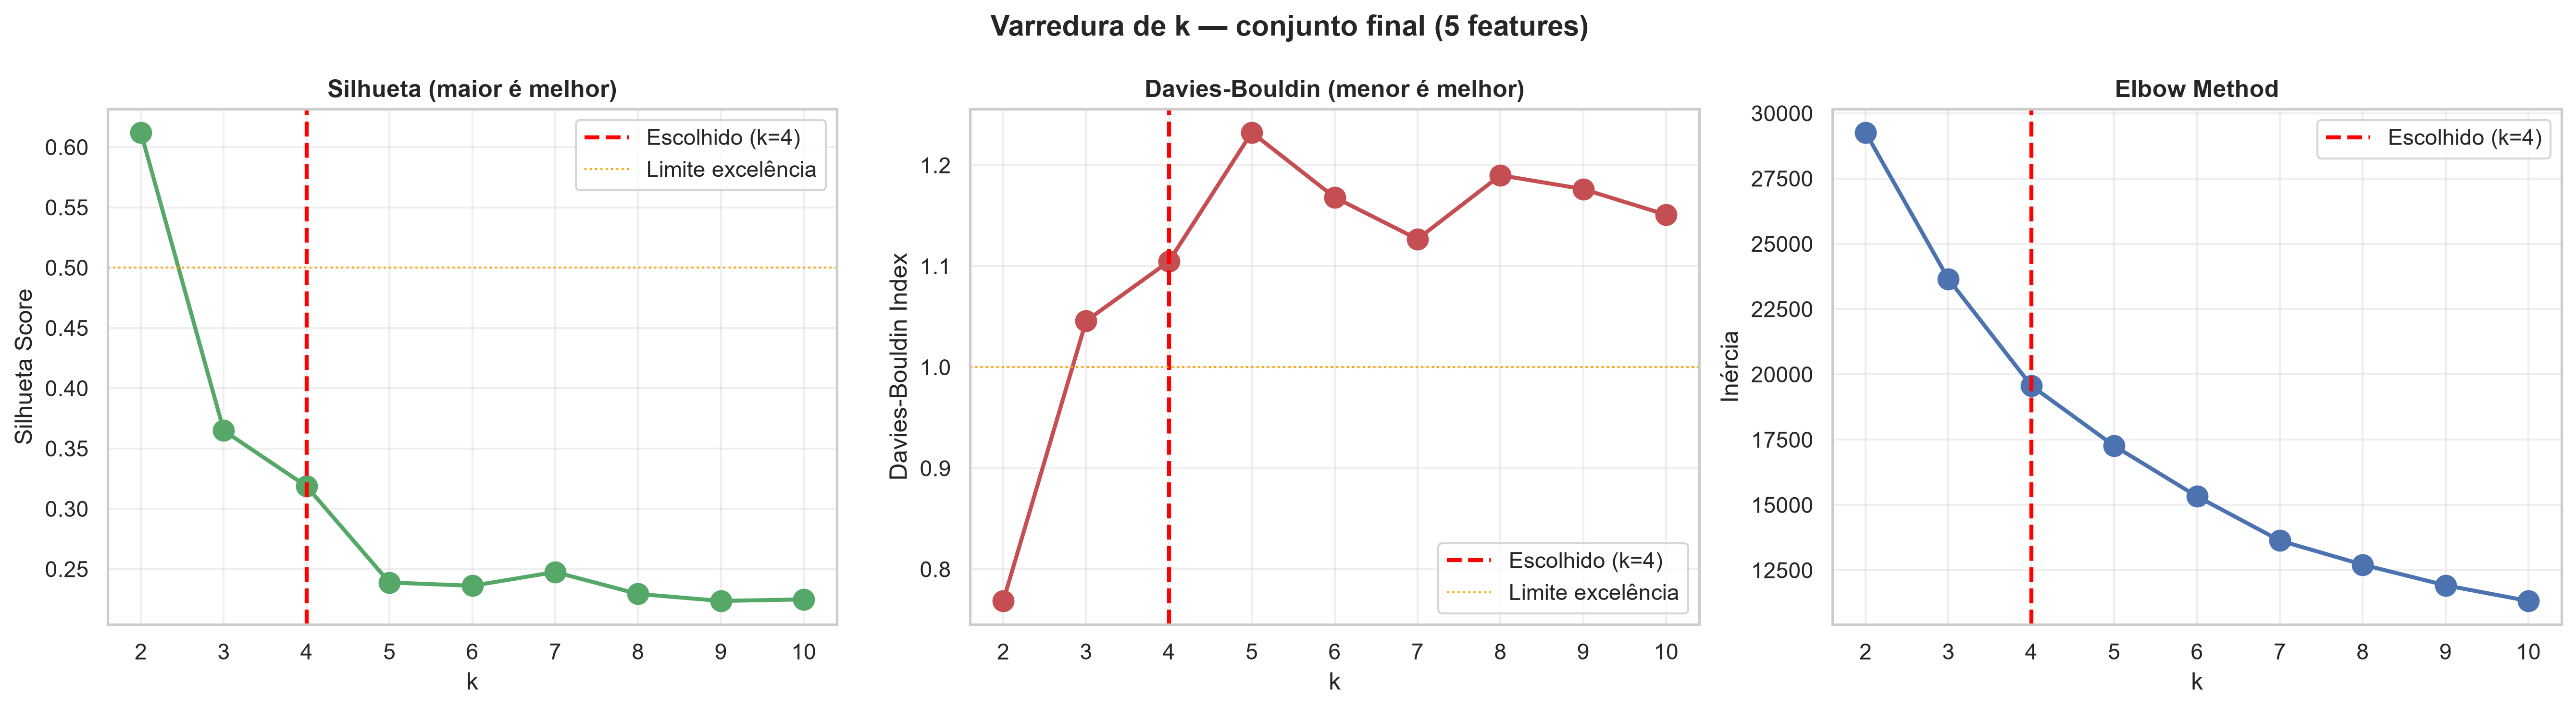

In [5]:
Image(filename=FIGS / '02_comparativo_k.png', width=950)


k=3 tem silhueta maior (0,3648 vs. 0,3186 do k=4) — mas ao decompor o cluster grande do k=3 em dois
(o que k=4 faz), aparece um grupo de ~14% da base que é pequeno em volume mas paga **~50% mais caro**
por m³ que o resto dos clientes pequenos, com a menor margem de todos os grupos. É um achado de
negócio real — não visível nas métricas agregadas, que penalizam k=4 por essa divisão ser uma
fronteira menos óbvia estatisticamente. Optamos por k=4: o ganho de identificar esse grupo acionável
compensa a perda modesta de silhueta.


## 5. Resultado final — k=4, 5 features

### Como cada feature foi calculada, e por que foi escolhida


In [6]:
MODEL_CANDIDATES = ['transacoes', 'meses_ativos', 'produtos', 'volume_total', 'receita_liquida_total',
                    'lucro_reposicao_total', 'preco_liquido_ponderado', 'margem_pct_ponderada',
                    'frequencia_mensal', 'cv_volume', 'taxa_devolucao', 'taxa_ajuste', 'taxa_inconsistencia',
                    'recencia_dias', 'concentracao_familia', 'intensidade_desconto']
corr = customer_features_full[MODEL_CANDIDATES].corr(method='spearman')

redundantes = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i + 1:]:
        if abs(corr.loc[a, b]) >= 0.90:
            redundantes.append({'variável A': a, 'variável B': b, 'correlação (Spearman)': round(corr.loc[a, b], 3)})
display(pd.DataFrame(redundantes).sort_values('correlação (Spearman)', key=abs, ascending=False))


,variável A,variável B,correlação (Spearman)
2,volume_total,receita_liquida_total,0.994
4,receita_liquida_total,lucro_reposicao_total,0.963
3,volume_total,lucro_reposicao_total,0.956
0,transacoes,meses_ativos,0.938
1,transacoes,produtos,0.901


Pares com correlação ≥ 0,90 (acima) são candidatos a "a mesma informação contada duas vezes":
`volume_total` ↔ `receita_liquida_total` ↔ `lucro_reposicao_total` formam um grupo só de porte;
`transacoes` ↔ `meses_ativos` ↔ `produtos` formam outro. A seleção final manteve **1 representante de
cada grupo redundante**, mais as métricas que passaram nos testes de ablação da seção 4:

<table>
<thead><tr><th>Feature</th><th>Dimensão</th><th>Como é calculada</th><th>Por que essa, e não outra</th></tr></thead>
<tbody>
<tr>
<td><code>volume_total</code></td>
<td>Porte</td>
<td>Soma do volume (m³) de todas as vendas elegíveis do cliente no período, sem AV</td>
<td>Único representante do grupo de porte — <code>receita_liquida_total</code> e
<code>lucro_reposicao_total</code> correlacionam 0,99 e 0,95 com volume; usar as três daria peso
triplicado ao tamanho do cliente</td>
</tr>
<tr>
<td><code>preco_liquido_ponderado</code></td>
<td>Preço médio ponderado por volume</td>
<td><code>receita_liquida_total ÷ volume_total</code> — sempre soma/soma, nunca média de preços por
transação</td>
<td>Não tinha par redundante; mede quanto custa, em média, <b>um m³</b> (1.000 litros)
comprado pelo cliente. Foi essencial para revelar o grupo Especial (seção 6)</td>
</tr>
<tr>
<td><code>margem_pct_ponderada</code></td>
<td>Margem</td>
<td><code>lucro_reposicao_total ÷ receita_liquida_total</code></td>
<td><b>Preço não é lucro:</b> um cliente pode pagar preço alto e ainda ter margem % baixa. A versão
percentual isola a eficiência de lucratividade, comparável entre cliente grande e pequeno</td>
</tr>
<tr>
<td><code>produtos</code></td>
<td>Diversidade</td>
<td>Nº de <code>Código Material</code> distintos comprados pelo cliente</td>
<td>Representa o grupo transações/atividade; mantida em vez de <code>concentracao_familia</code>
(anti-correlação de -0,75 entre as duas — testes mostraram que manter só uma é melhor que as duas
juntas, e <code>produtos</code> é mais simples de explicar)</td>
</tr>
<tr>
<td><code>recencia_dias</code></td>
<td>Engajamento recente</td>
<td>Dias desde a última compra — prioriza a base de pedidos (mais recente e granular), usa a última
compra da base de vendas como alternativa quando não há pedido</td>
<td>Preenche a lacuna deixada pela remoção de <code>frequencia_mensal</code>; testada por ablação e
mantida</td>
</tr>
</tbody>
</table>

**Variáveis testadas e descartadas** (com o motivo): `frequencia_mensal` (qualidade de dado — pedidos
fraturados em várias remessas), `taxa_devolucao` (pedido do cliente), `intensidade_desconto` e
`concentracao_familia` (ablação — seção 4), `setor_industrial_cliente` (93% concentrado numa única
categoria, não discrimina nada).

### Perfil dos 4 clusters


In [7]:
seg = pd.read_csv(CLUSTER / 'segmentacao_clientes_kmeans.csv')
seg['cnae_divisao_nome'] = seg['Código Cliente'].map(
    customer_features_full.set_index('Código Cliente')['cnae_divisao_nome'])
seg['estado_cliente'] = seg['Código Cliente'].map(
    customer_features_full.set_index('Código Cliente')['estado_cliente'])
seg['frete_por_m3'] = seg['Código Cliente'].map(
    customer_features_full.set_index('Código Cliente')['frete_por_m3'])
NOMES = {0: 'Pequeno', 1: 'Grande', 2: 'Especial', 3: 'Médio'}
FEATURES = ['volume_total', 'preco_liquido_ponderado', 'margem_pct_ponderada', 'produtos', 'recencia_dias']
perfil = seg.groupby('cluster')[FEATURES].mean().round(2)
perfil.insert(0, 'nome_sugerido', perfil.index.map(NOMES))
perfil.insert(1, 'n_clientes', seg['cluster'].value_counts().sort_index())
perfil.insert(2, 'pct', (seg['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))
display(perfil)


,nome_sugerido,n_clientes,pct,volume_total,preco_liquido_ponderado,margem_pct_ponderada,produtos,recencia_dias
cluster,,,,,,,,
0,Pequeno,4656,66.0,3.55,12326.26,0.16,5.39,420.55
1,Grande,265,3.8,87.75,12464.40,0.15,23.91,110.33
2,Especial,998,14.2,2.89,18514.15,0.14,5.22,248.89
3,Médio,1131,16.0,27.36,13037.13,0.16,17.68,116.57


> Os nomes na coluna `nome_sugerido` são propostas para facilitar a leitura — não são uma decisão
> de negócio validada. Precisam de checagem com o time comercial antes de virar rótulo oficial.

### O que cada cluster representa

- **Pequeno** (4.656 clientes, 66,0%) — o grosso da carteira. Volume baixo (3,6 m³ em média), poucos
  produtos (5,4) e muito tempo sem comprar (421 dias, ~14 meses). Preço e margem dentro da média geral.

- **Grande** (265 clientes, 3,8%) — o menor grupo, mas o mais valioso em volume: compram **87,8 m³**
  em média, de **23,9** produtos diferentes, com recência baixa (110 dias — compram com frequência).
  Preço em linha com a média geral — não é "premium" no preço, é grande e engajado.

- **Especial** (998 clientes, 14,2%) — mesmo volume baixo do Pequeno (2,9 m³), mas paga em média
  **R$ 18.514 por m³** (~50% acima dos ~R$ 12-13 mil/m³ dos demais clusters) e tem a **menor margem
  de todos** (14,3%). Compra tão pouco quanto o Pequeno, mas com recência um pouco melhor (249 dias).
  É o achado do modelo: clientes pequenos que não recebem os descontos que o resto da base pequena
  recebe. Vale entender *por que* (produto específico? canal? região?) antes de qualquer ação de preço.

- **Médio** (1.131 clientes, 16,0%) — mesmo perfil do Grande, em escala menor: volume (27,4 m³),
  produtos (17,7) e recência (117 dias) ficam entre o Pequeno e os clusters maiores.


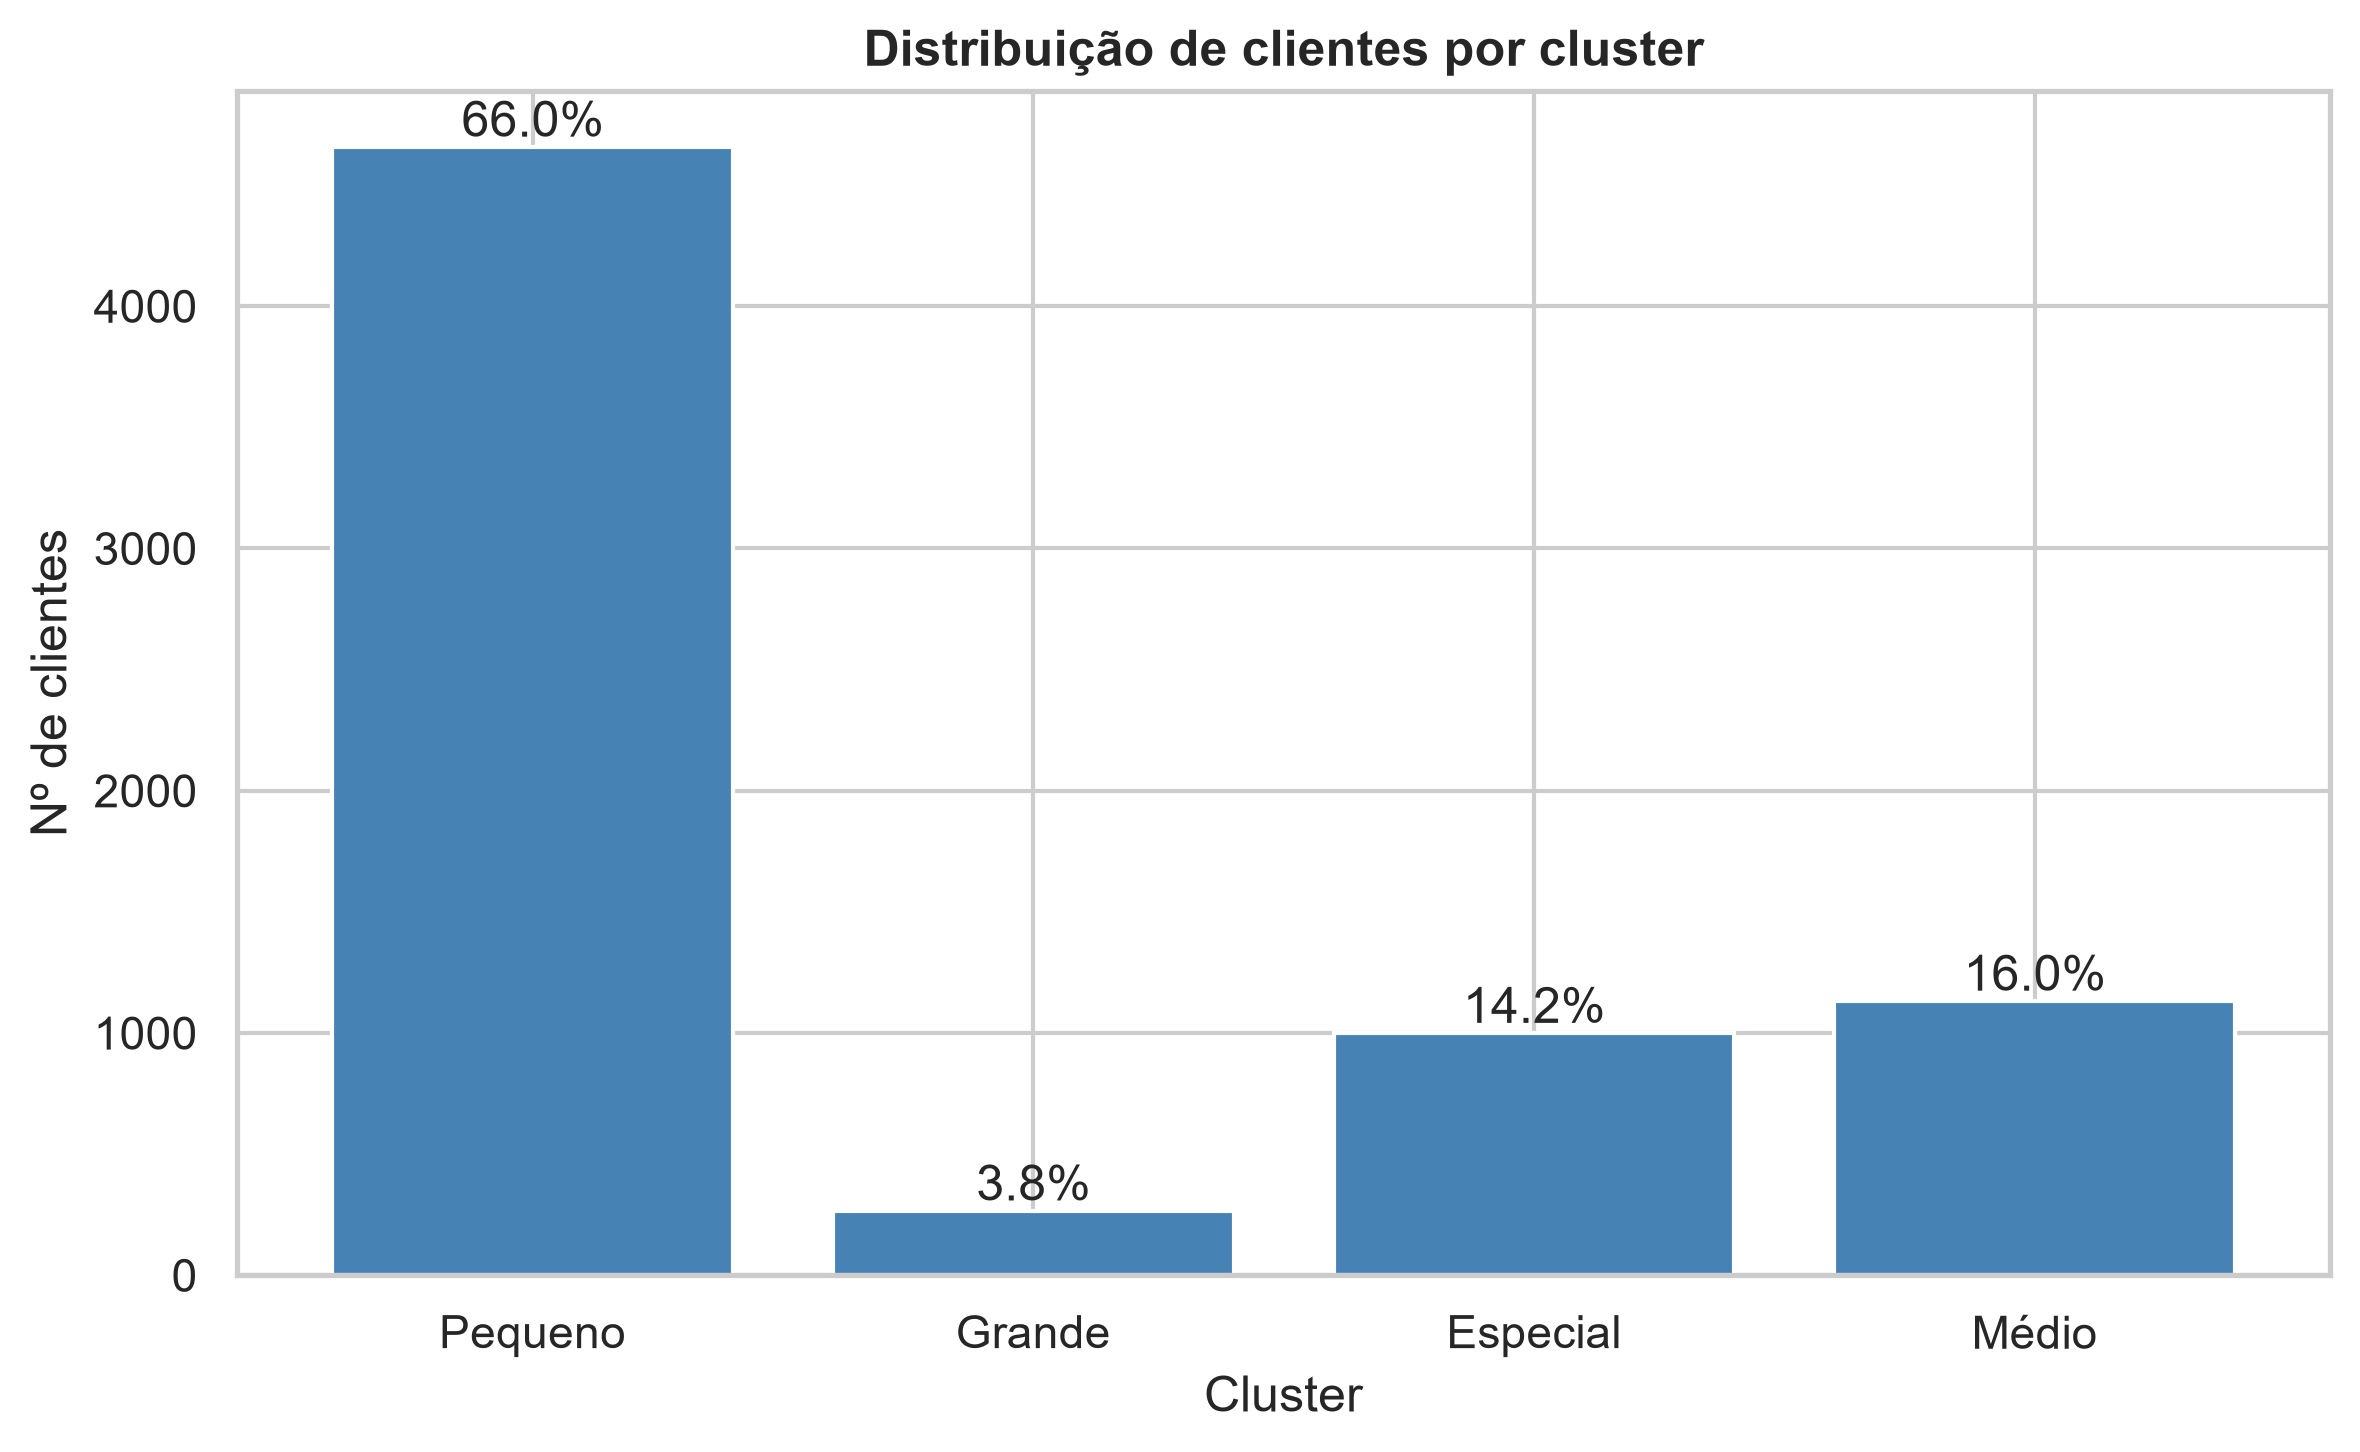

In [8]:
Image(filename=HIBRIDA / 'distribuicao_clusters.png', width=800)


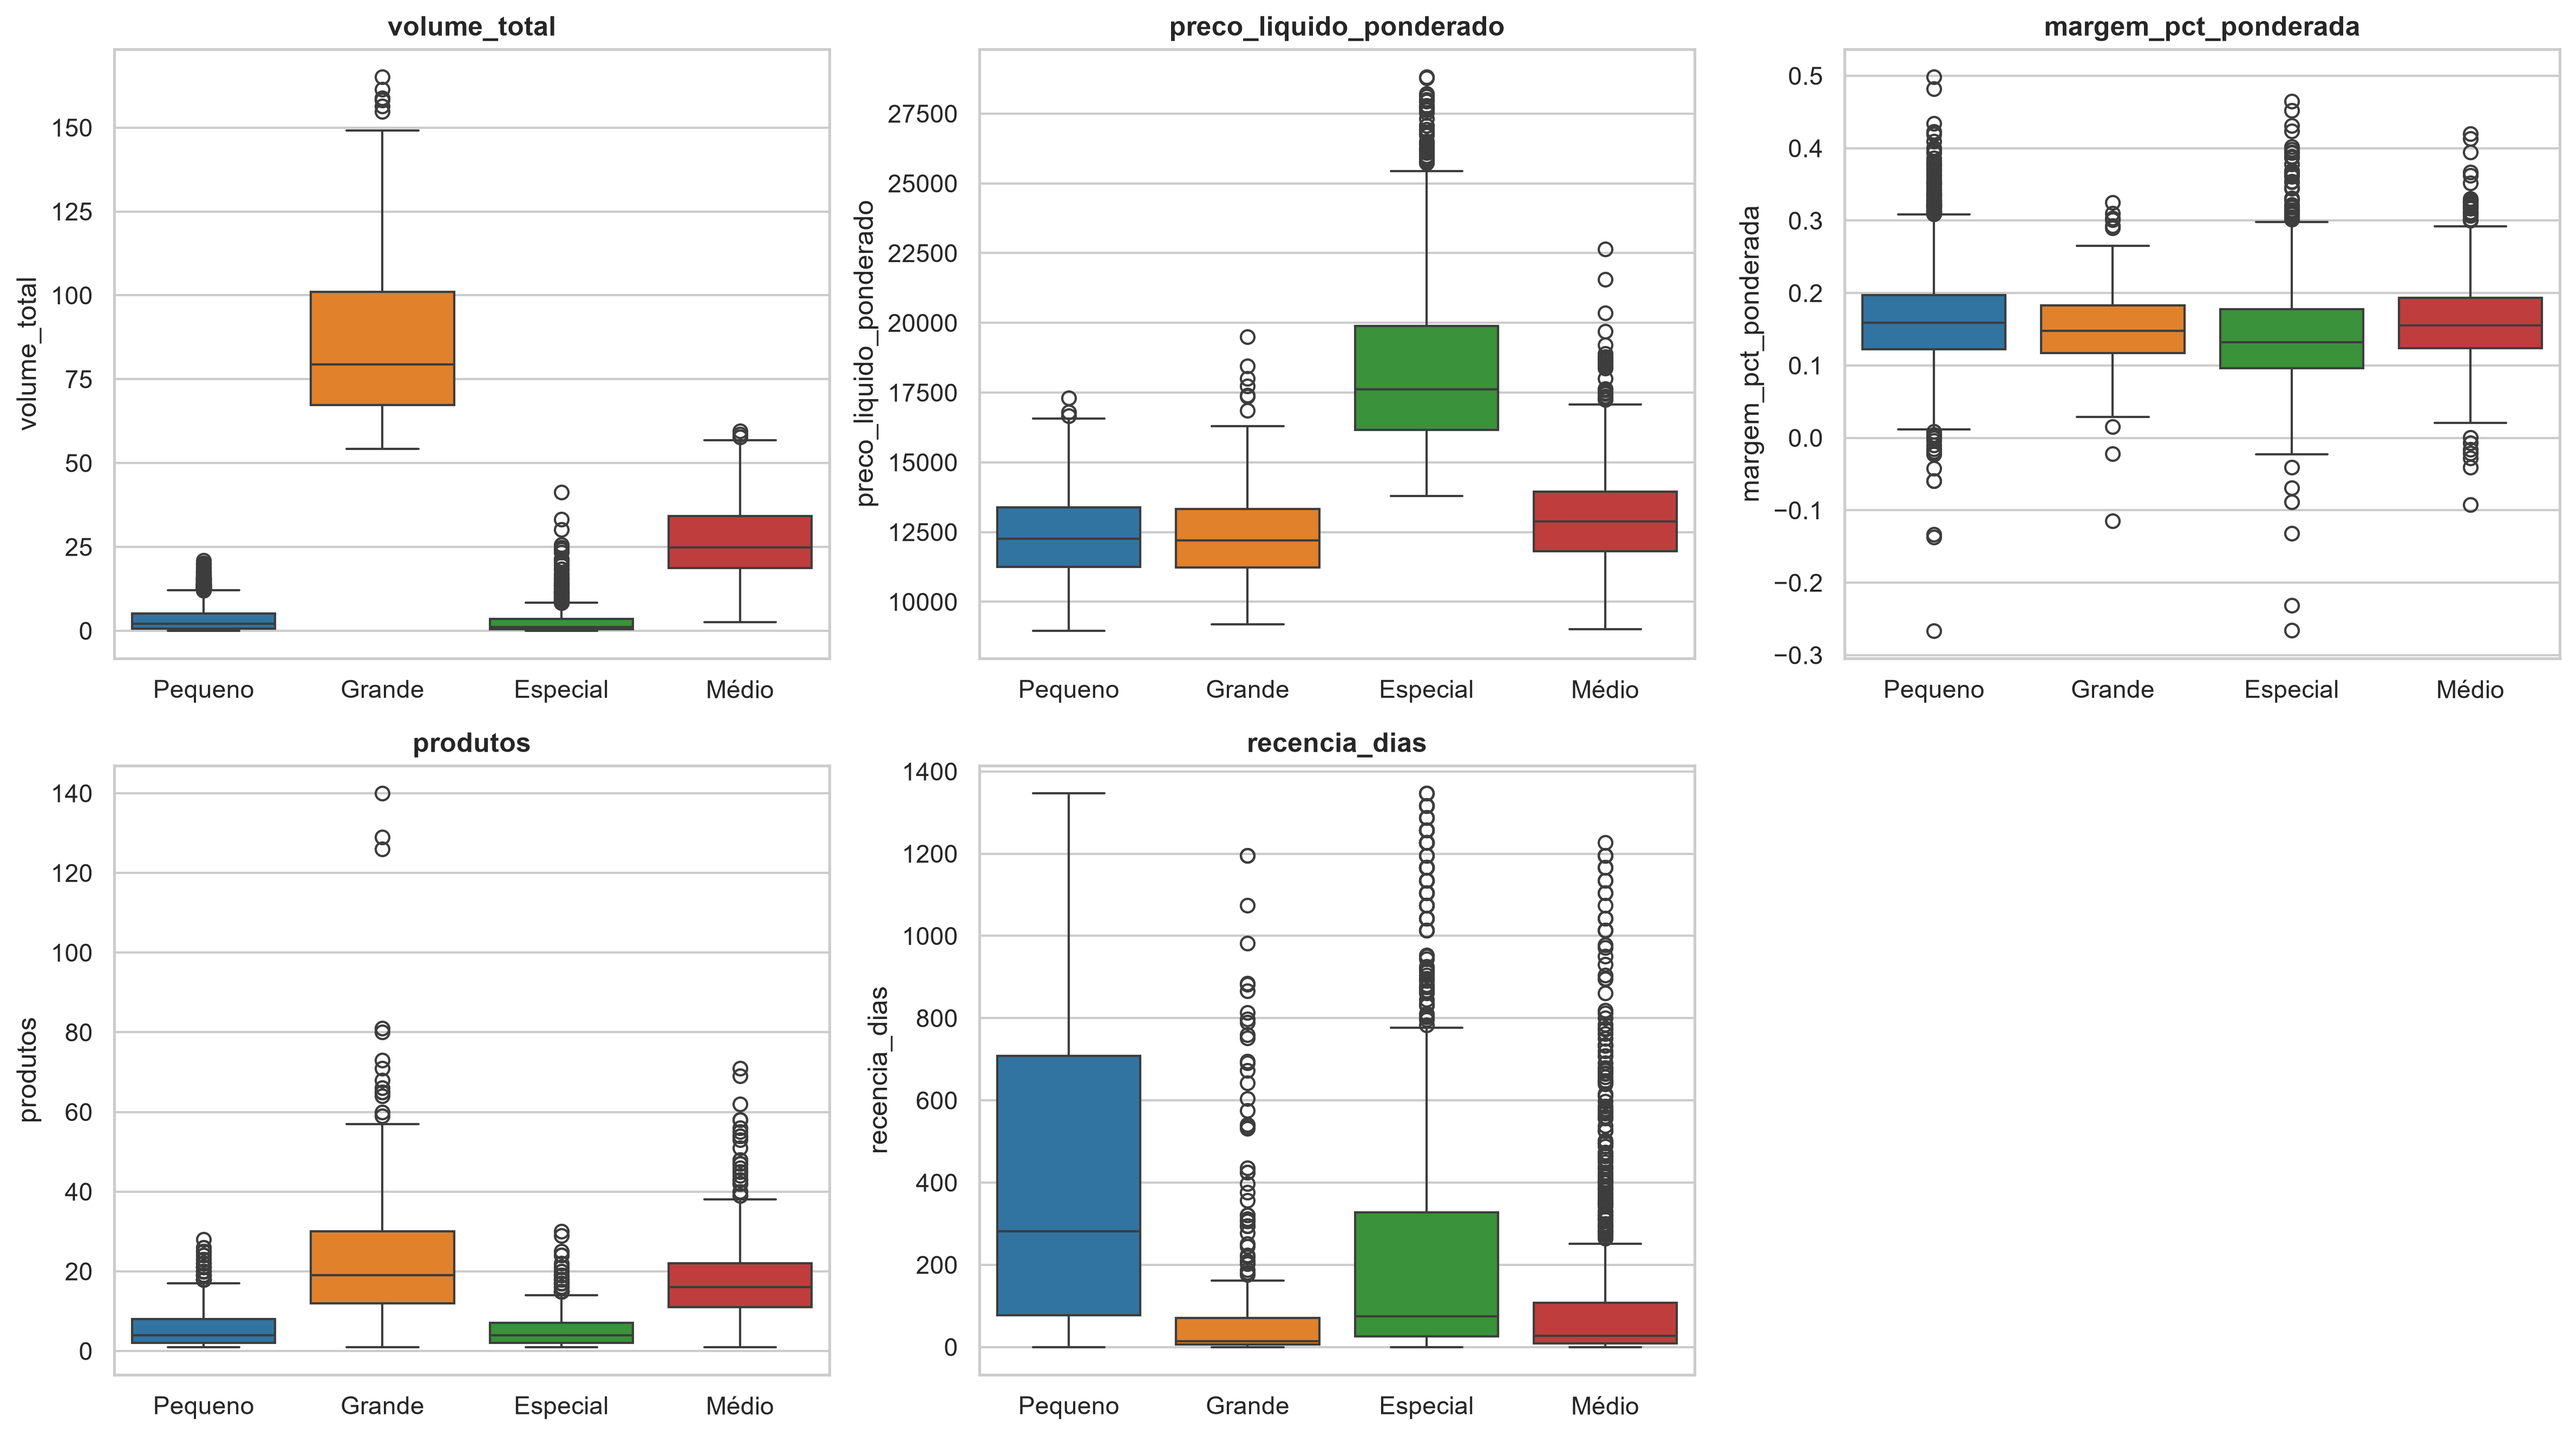

In [9]:
Image(filename=FIGS / '05_features_boxplot.png', width=950)


A projeção PCA abaixo reduz as 5 dimensões a 2 eixos só para visualização — o modelo em si usa as 5
dimensões originais, não essa projeção.


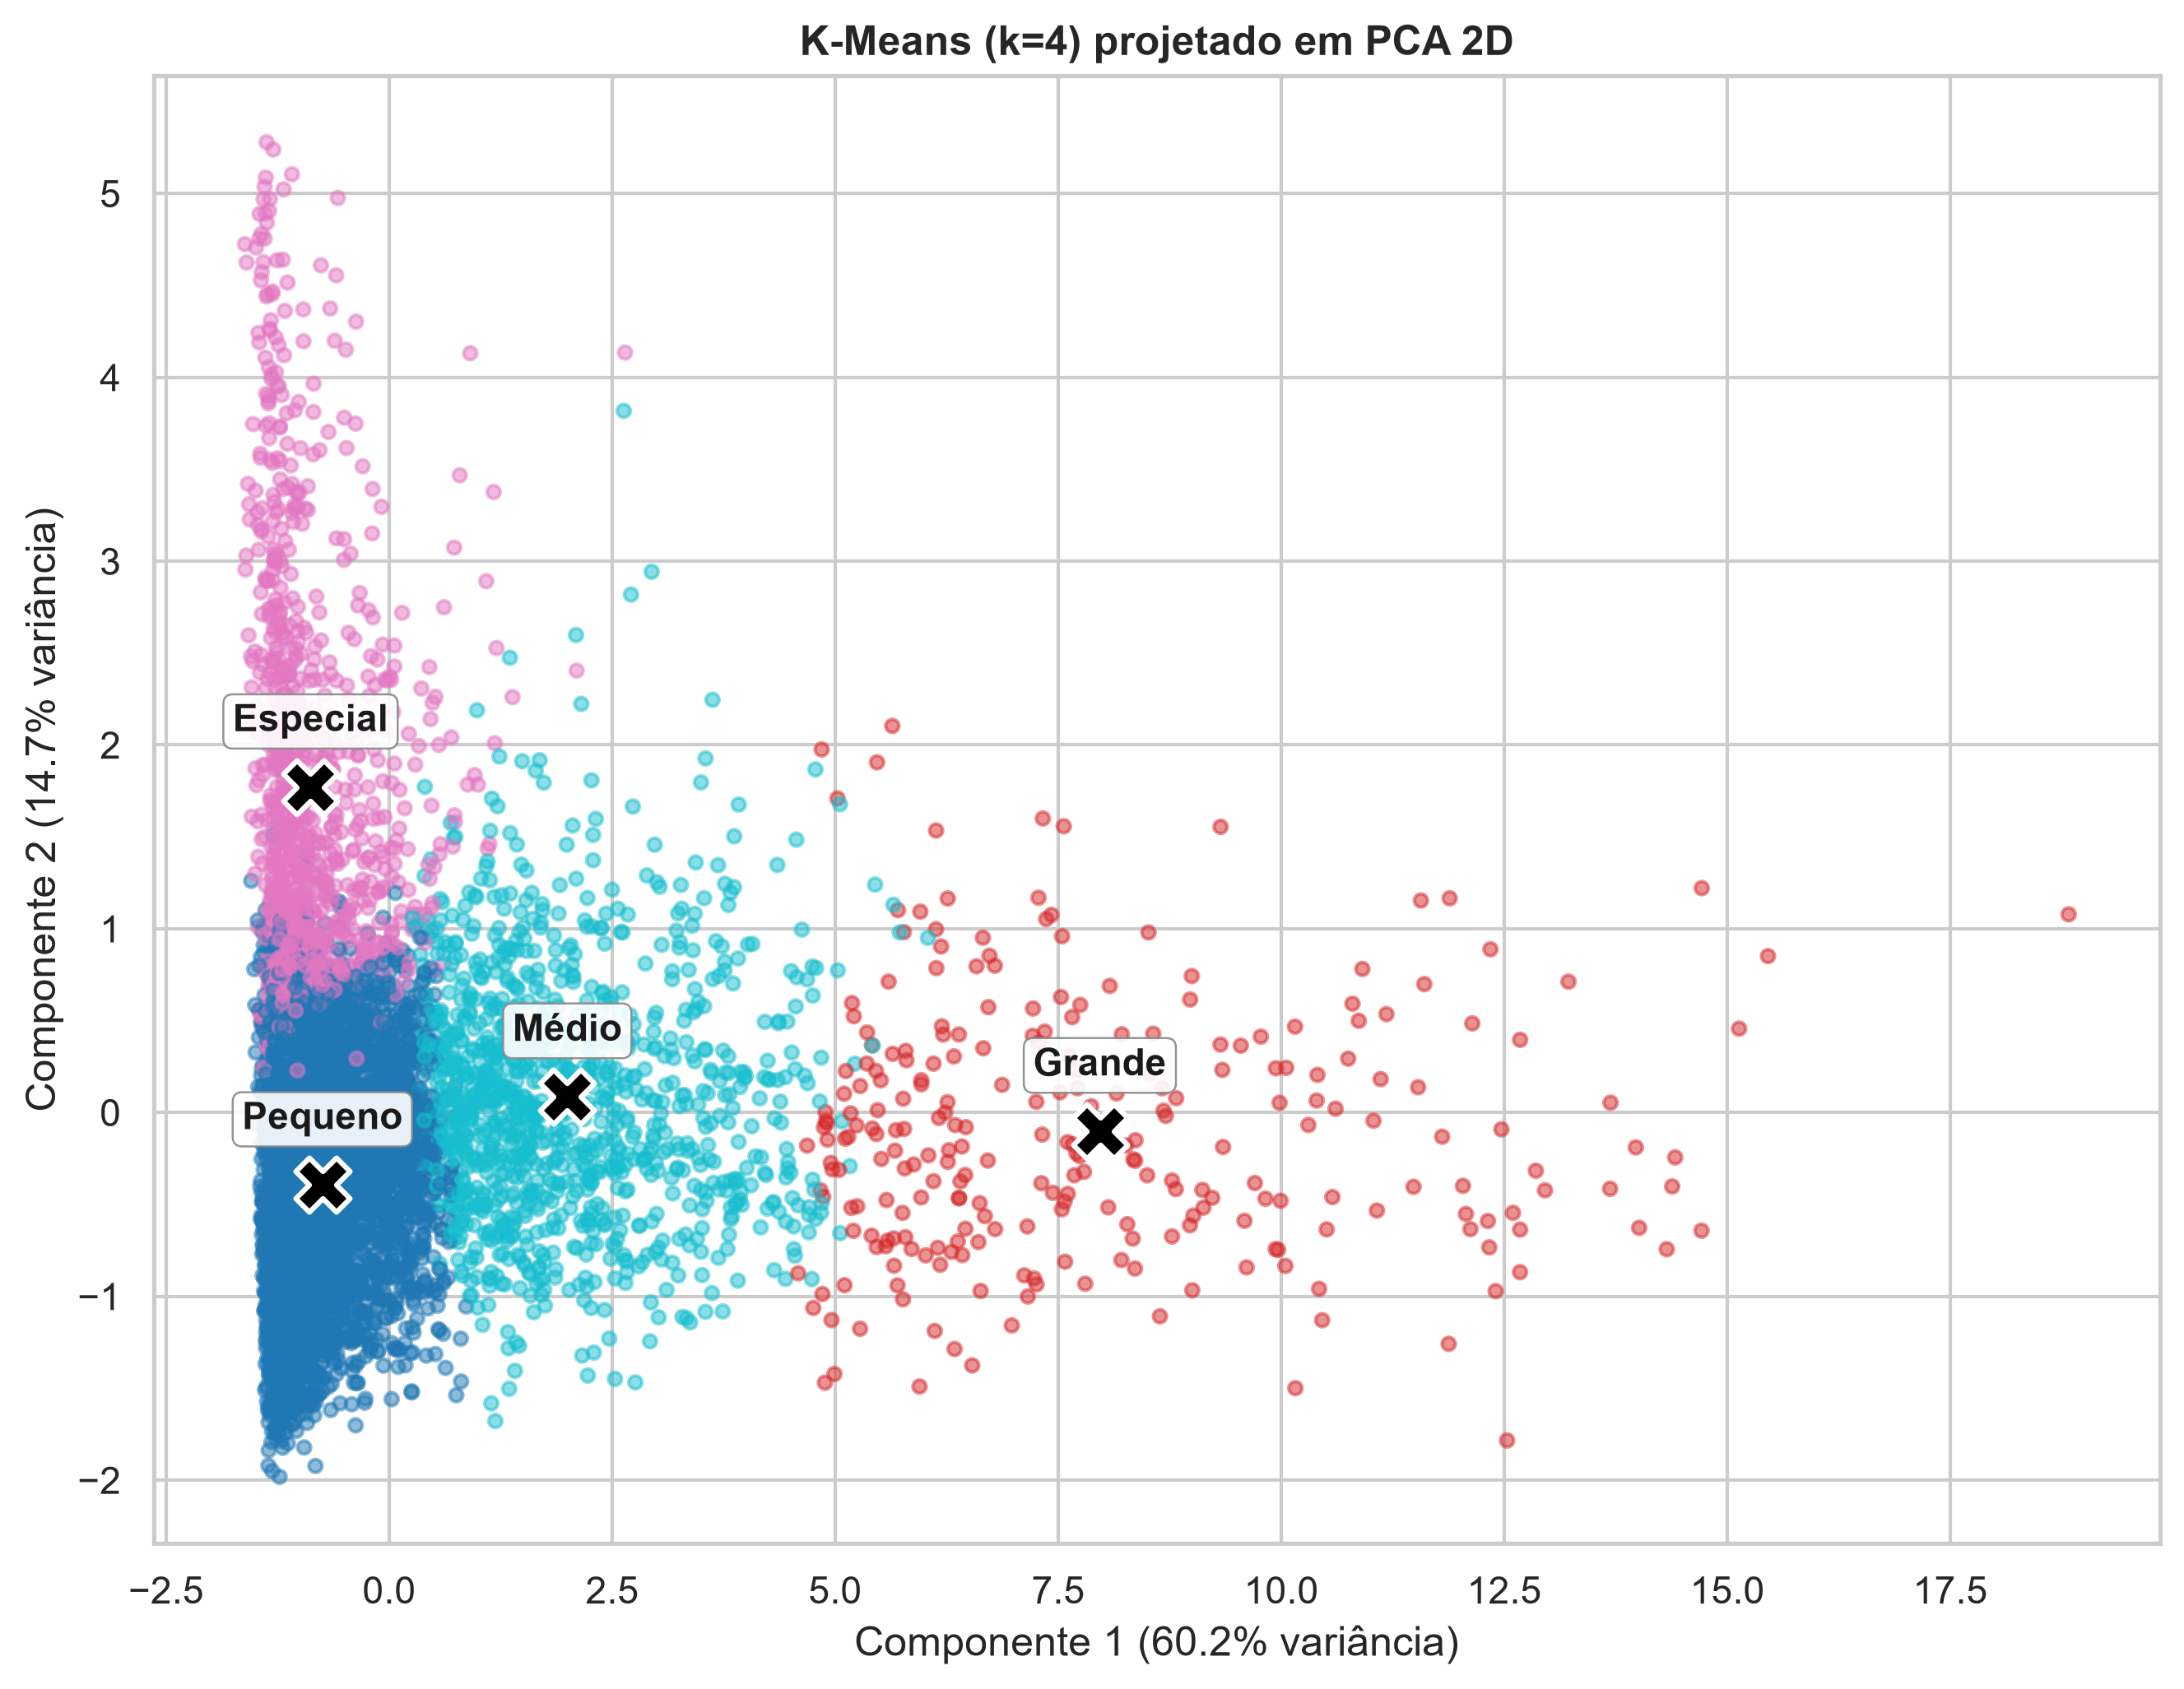

In [10]:
Image(filename=FIGS / '04_kmeans_pca_2d.png', width=950)


## 6. Enriquecimento — segmentação híbrida (família × frequência)

Os 4 clusters dizem **quem é parecido com quem**. Para virar uma tabela de preços operacional,
cruzamos cada cluster com duas dimensões que o modelo não captura diretamente:

- **Família de produto:** as **10** famílias de maior volume, sem AV — TOP TURBO, HYDRA XP, HYDRA, TOP TURBO PRO, GEAR, GL 5, TRM 5, FLUIDO PARA RADIADOR, UTILE, UNITRACTOR — cobrindo 69,6% do volume total. Sem bucket `Outras`: famílias fora do top 10 ficam fora da matriz cluster × família, de propósito (cobertura parcial, não 100%).
- **Frequência de compra (corrigida):** discretizada em 3 níveis a partir de
  `frequencia_mensal_corrigida` — Ocasionais (< 1,5/mês), Regulares (1,5–3,5/mês), Frequentes
  (> 3,5/mês). Corrigida para contar pedidos únicos (`DOC_VENDA`) via `pedidos.csv`, em vez de
  linhas de remessa da base de vendas — o mesmo problema que tirou `frequencia_mensal` do
  modelo (seção 4) também inflava essa leitura de perfil. Usada só para enriquecimento, não
  como input do K-Means.
- **CNAE (via cruzamento CNPJ → Receita Federal):** substitui `segmento_b2b` como leitura de
  setor — mais granular (`segmento_b2b` tinha 22 categorias genéricas; CNAE resolve a atividade
  econômica real de cada cliente) e sem o "buraco negro" das categorias OUTROS/OUTRAS
  INDÚSTRIAS, que escondiam transporte, construção e agroindústria. Cobertura: 96,8% dos
  clientes do modelo (o resto é pessoa física, que não tem CNAE).

Duas decisões de metodologia:

1. **Família por transação vs. família principal do cliente:** a matriz cluster × família usa a
   família de cada *transação* (um cliente que compra de 2 famílias aparece em 2 colunas); já a
   segmentação final por cliente usa a família de **maior volume** do cliente ("família principal").
2. **Células pequenas são descartadas, não fundidas:** combinações cluster×família com menos de 10 clientes são removidas da matriz (não fundidas em nenhum bucket) — na prática, com o top 10 atual, todas as 40 combinações (4 clusters × 10 famílias) têm 10 clientes ou mais, então nenhuma célula precisou ser descartada.


### Nível de margem por cluster

`margem_pct_ponderada` (uma das 5 features do modelo) classificada em 3 faixas — tercis da população do modelo, cortes arredondados: **Baixa** (< 13%), **Média** (13%–18%) e **Alta** (≥ 18%), cada uma com cerca de 1/3 da base.


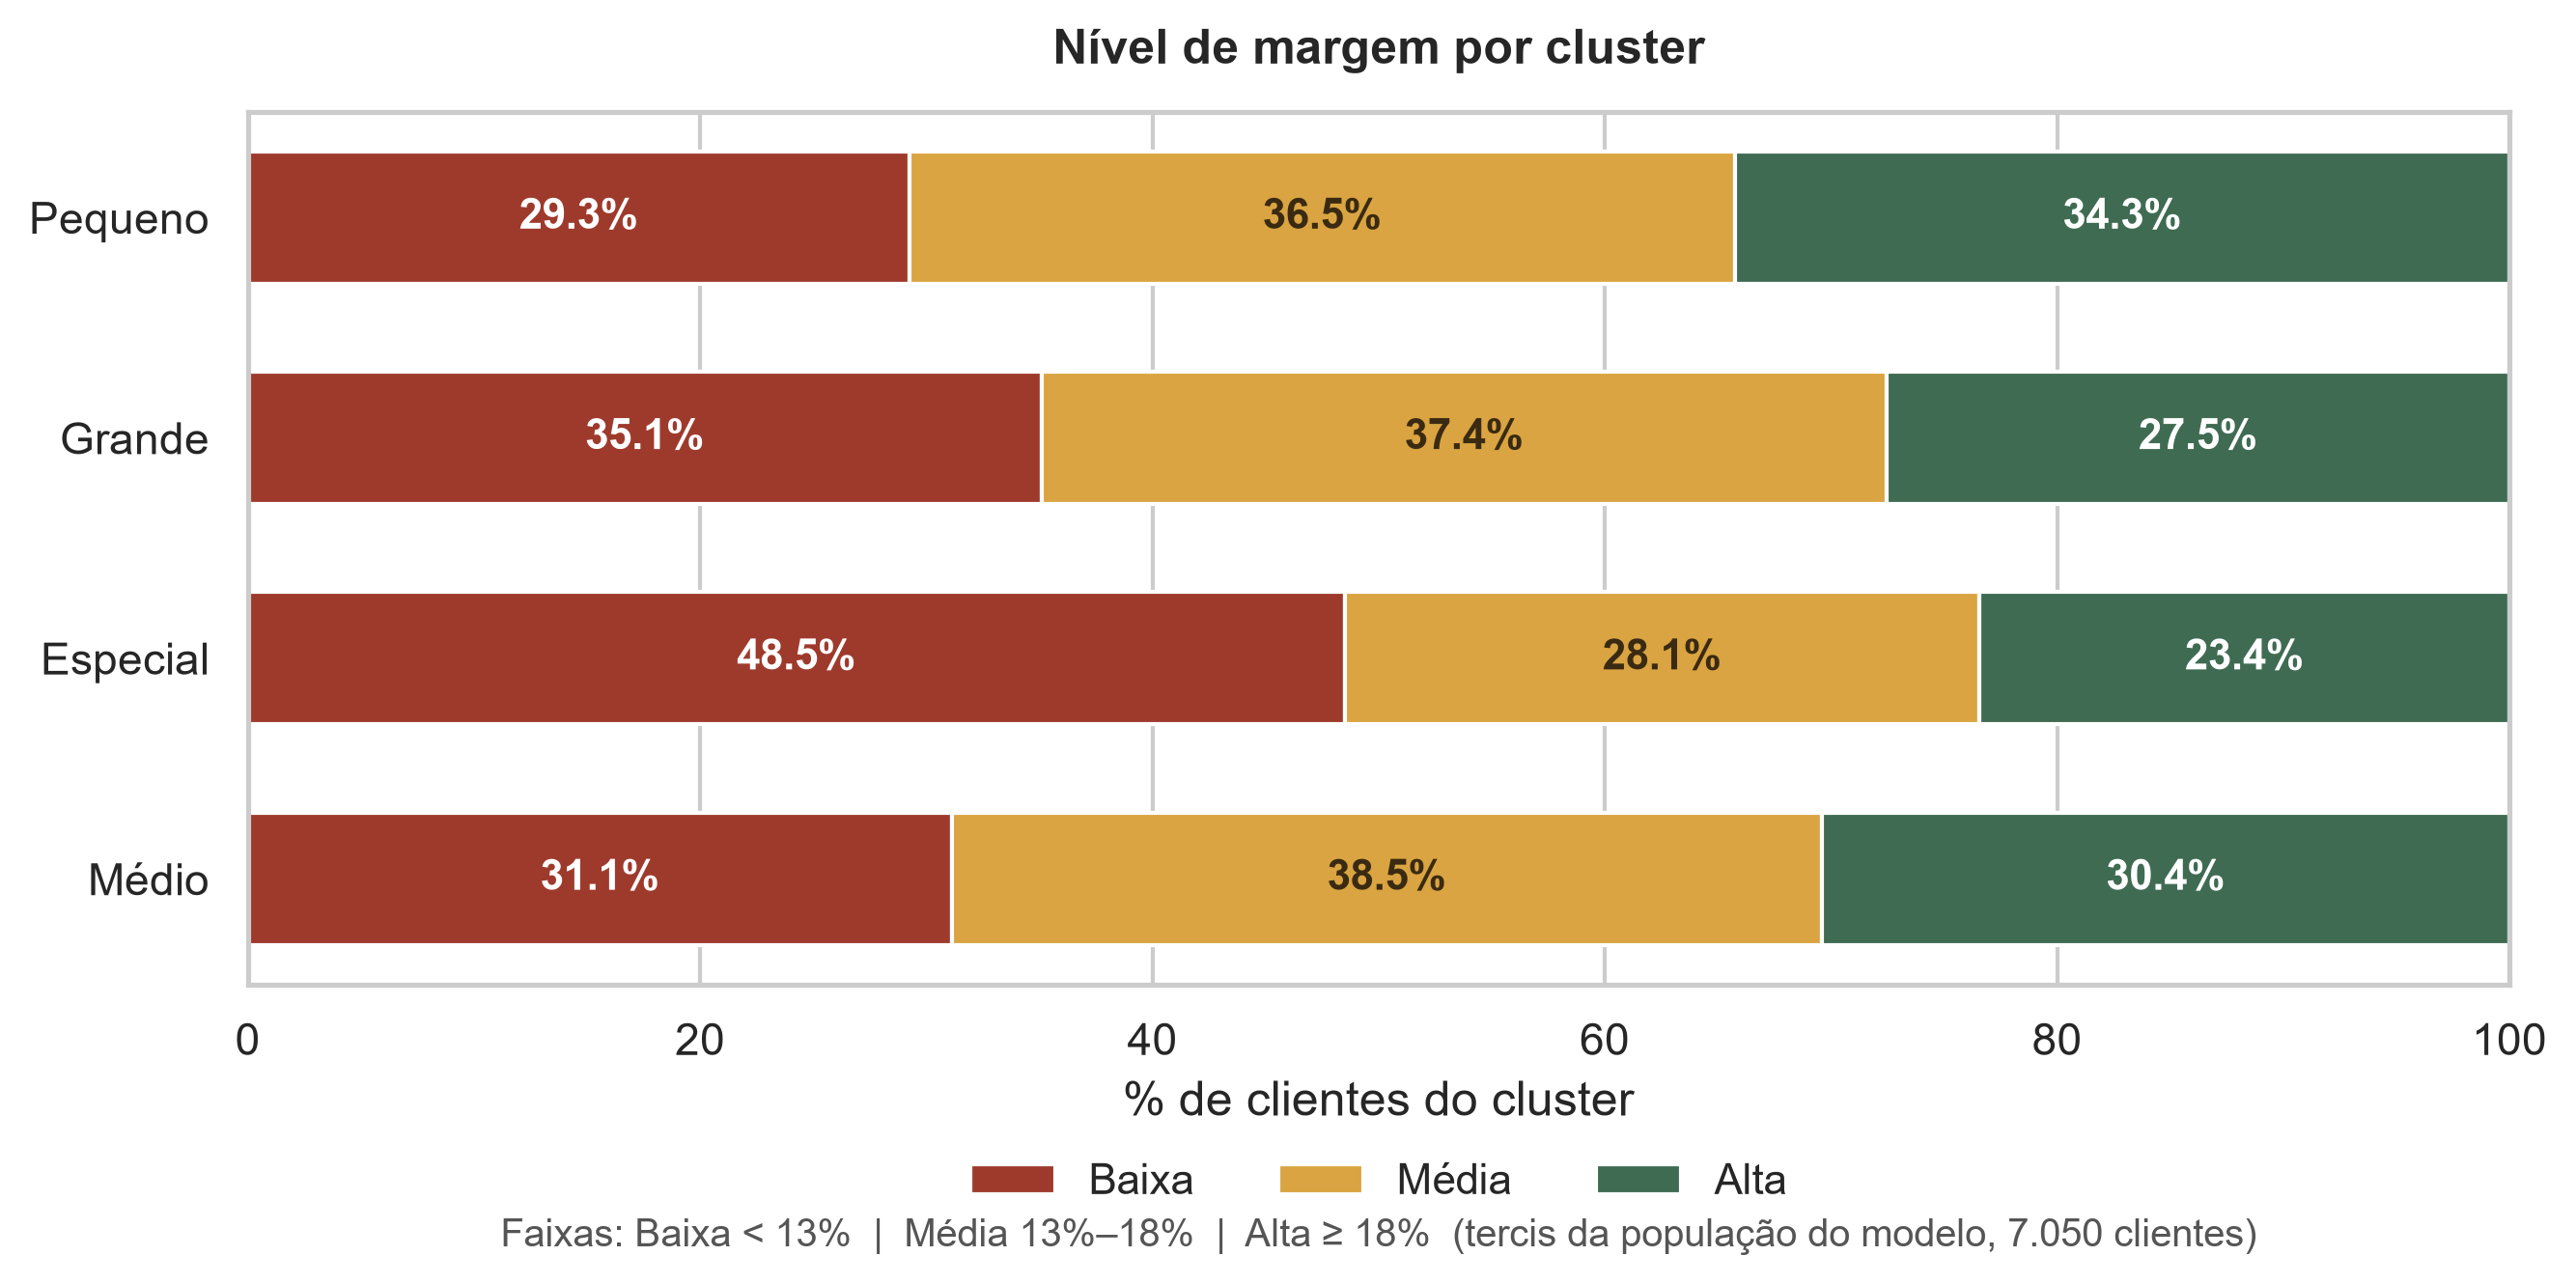

In [11]:
Image(filename=HIBRIDA / 'nivel_margem_por_cluster.png', width=750)


**Achado:** o cluster **Especial** tem quase metade dos seus clientes (48,5%) na faixa de margem **Baixa**, contra 29–35% nos demais grupos — e só 23,4% na faixa **Alta**, a menor proporção dos quatro. Confirma, no nível de cliente individual (não só na média do grupo), que a margem mais apertada do Especial é um padrão consistente, não puxada por poucos casos extremos.


### Cluster Especial, margem Baixa: quem são esses clientes?

998 clientes formam o cluster Especial; 484 (48,5%) caem na faixa de margem Baixa. Onde esses clientes estão concentrados?


### Margem unitária — top 10 específico do Especial

Complementando o preço acima: qual a margem unitária (R$/m³) de cada um desses 10 produtos, e em que faixa de margem (Baixa/Média/Alta, seção 6) cada um cai?


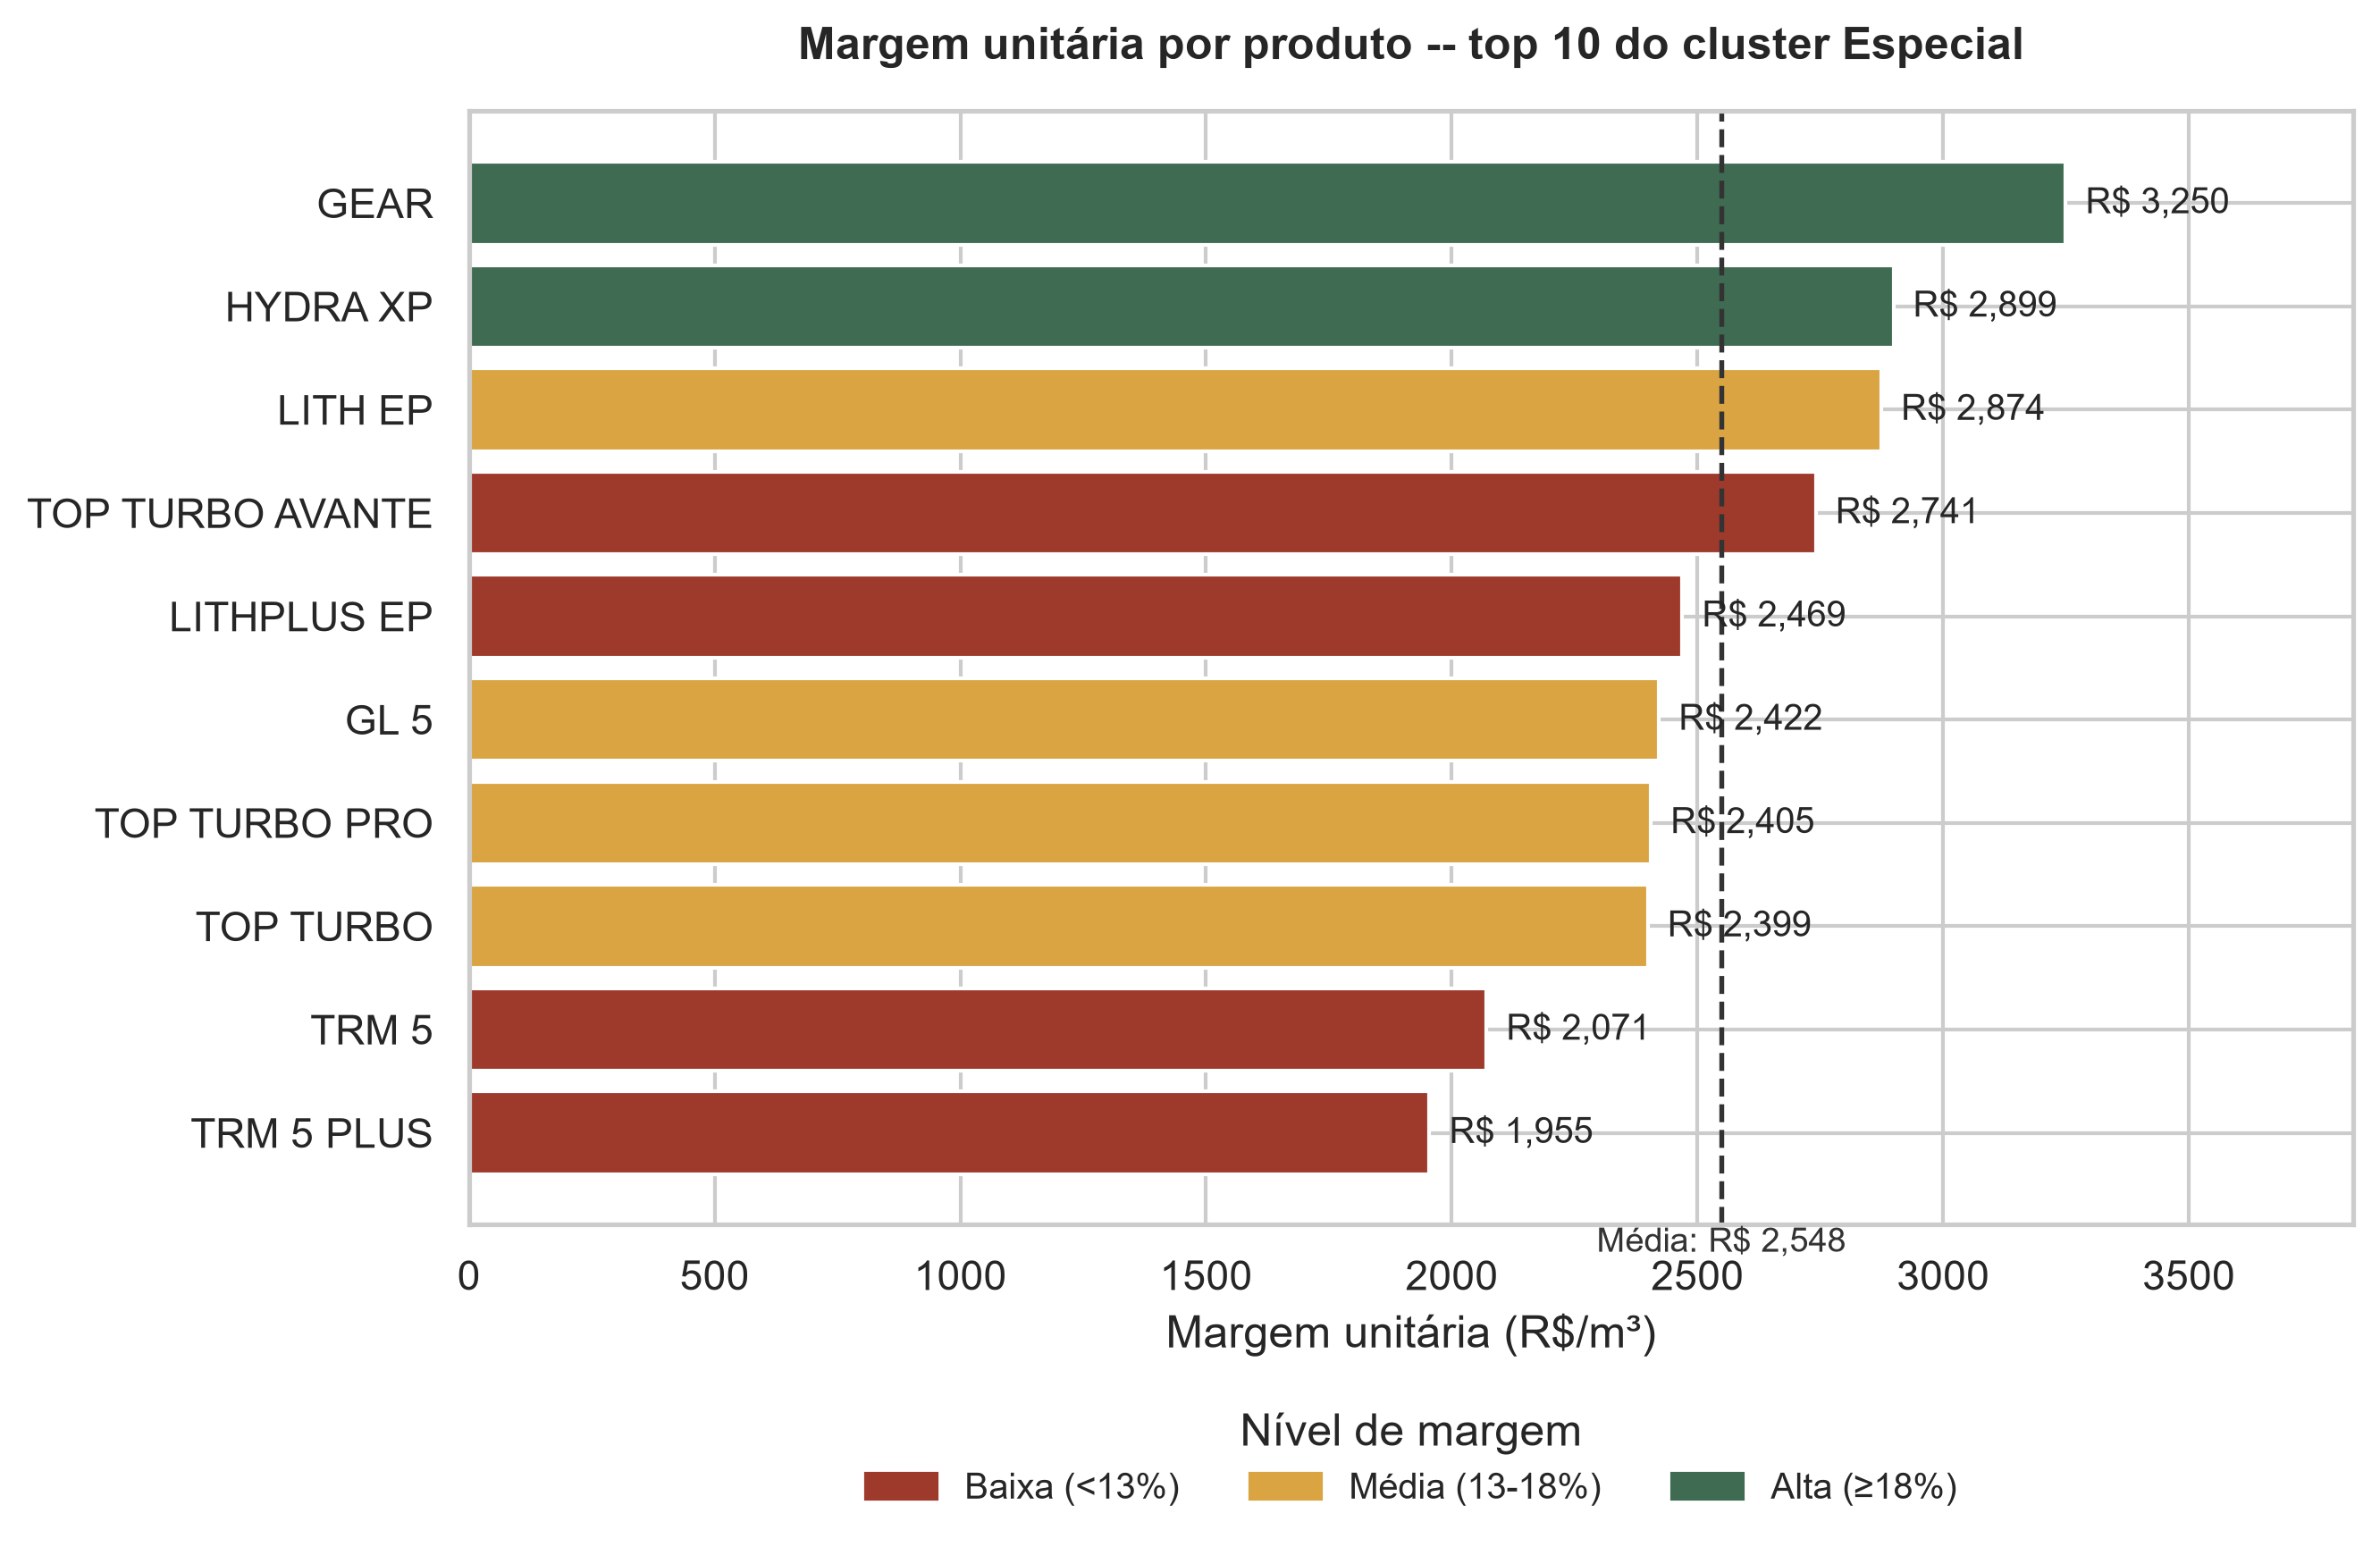

In [12]:
Image(filename=HIBRIDA / 'margem_unitaria_top10_especial.png', width=900)


**Achado:** as duas famílias mais caras do top 10 do Especial — **TOP TURBO AVANTE** e **LITHPLUS EP** — estão na faixa de margem **Baixa** (11,0%–12,0%), não na Alta. Preço mais alto não está virando margem melhor nesses produtos; o custo deles cresce proporcionalmente ainda mais. Já GEAR e HYDRA XP, com preço no meio da tabela, são as únicas com margem **Alta** (19,5%–20,5%). Das 4 famílias exclusivas do Especial, 3 (TOP TURBO AVANTE, LITHPLUS EP, TRM 5 PLUS) estão na faixa Baixa — reforça a hipótese de custo (frete/logística) específico desses produtos de nicho.


### Margem vs. custo — top 10 específico do Especial

Cada produto como uma bolha: eixo = margem (%) e custo (% do preço) — a posição na diagonal mostra o trade-off; o tamanho da bolha é a margem unitária em R$/m³, e a cor é o nível de margem.


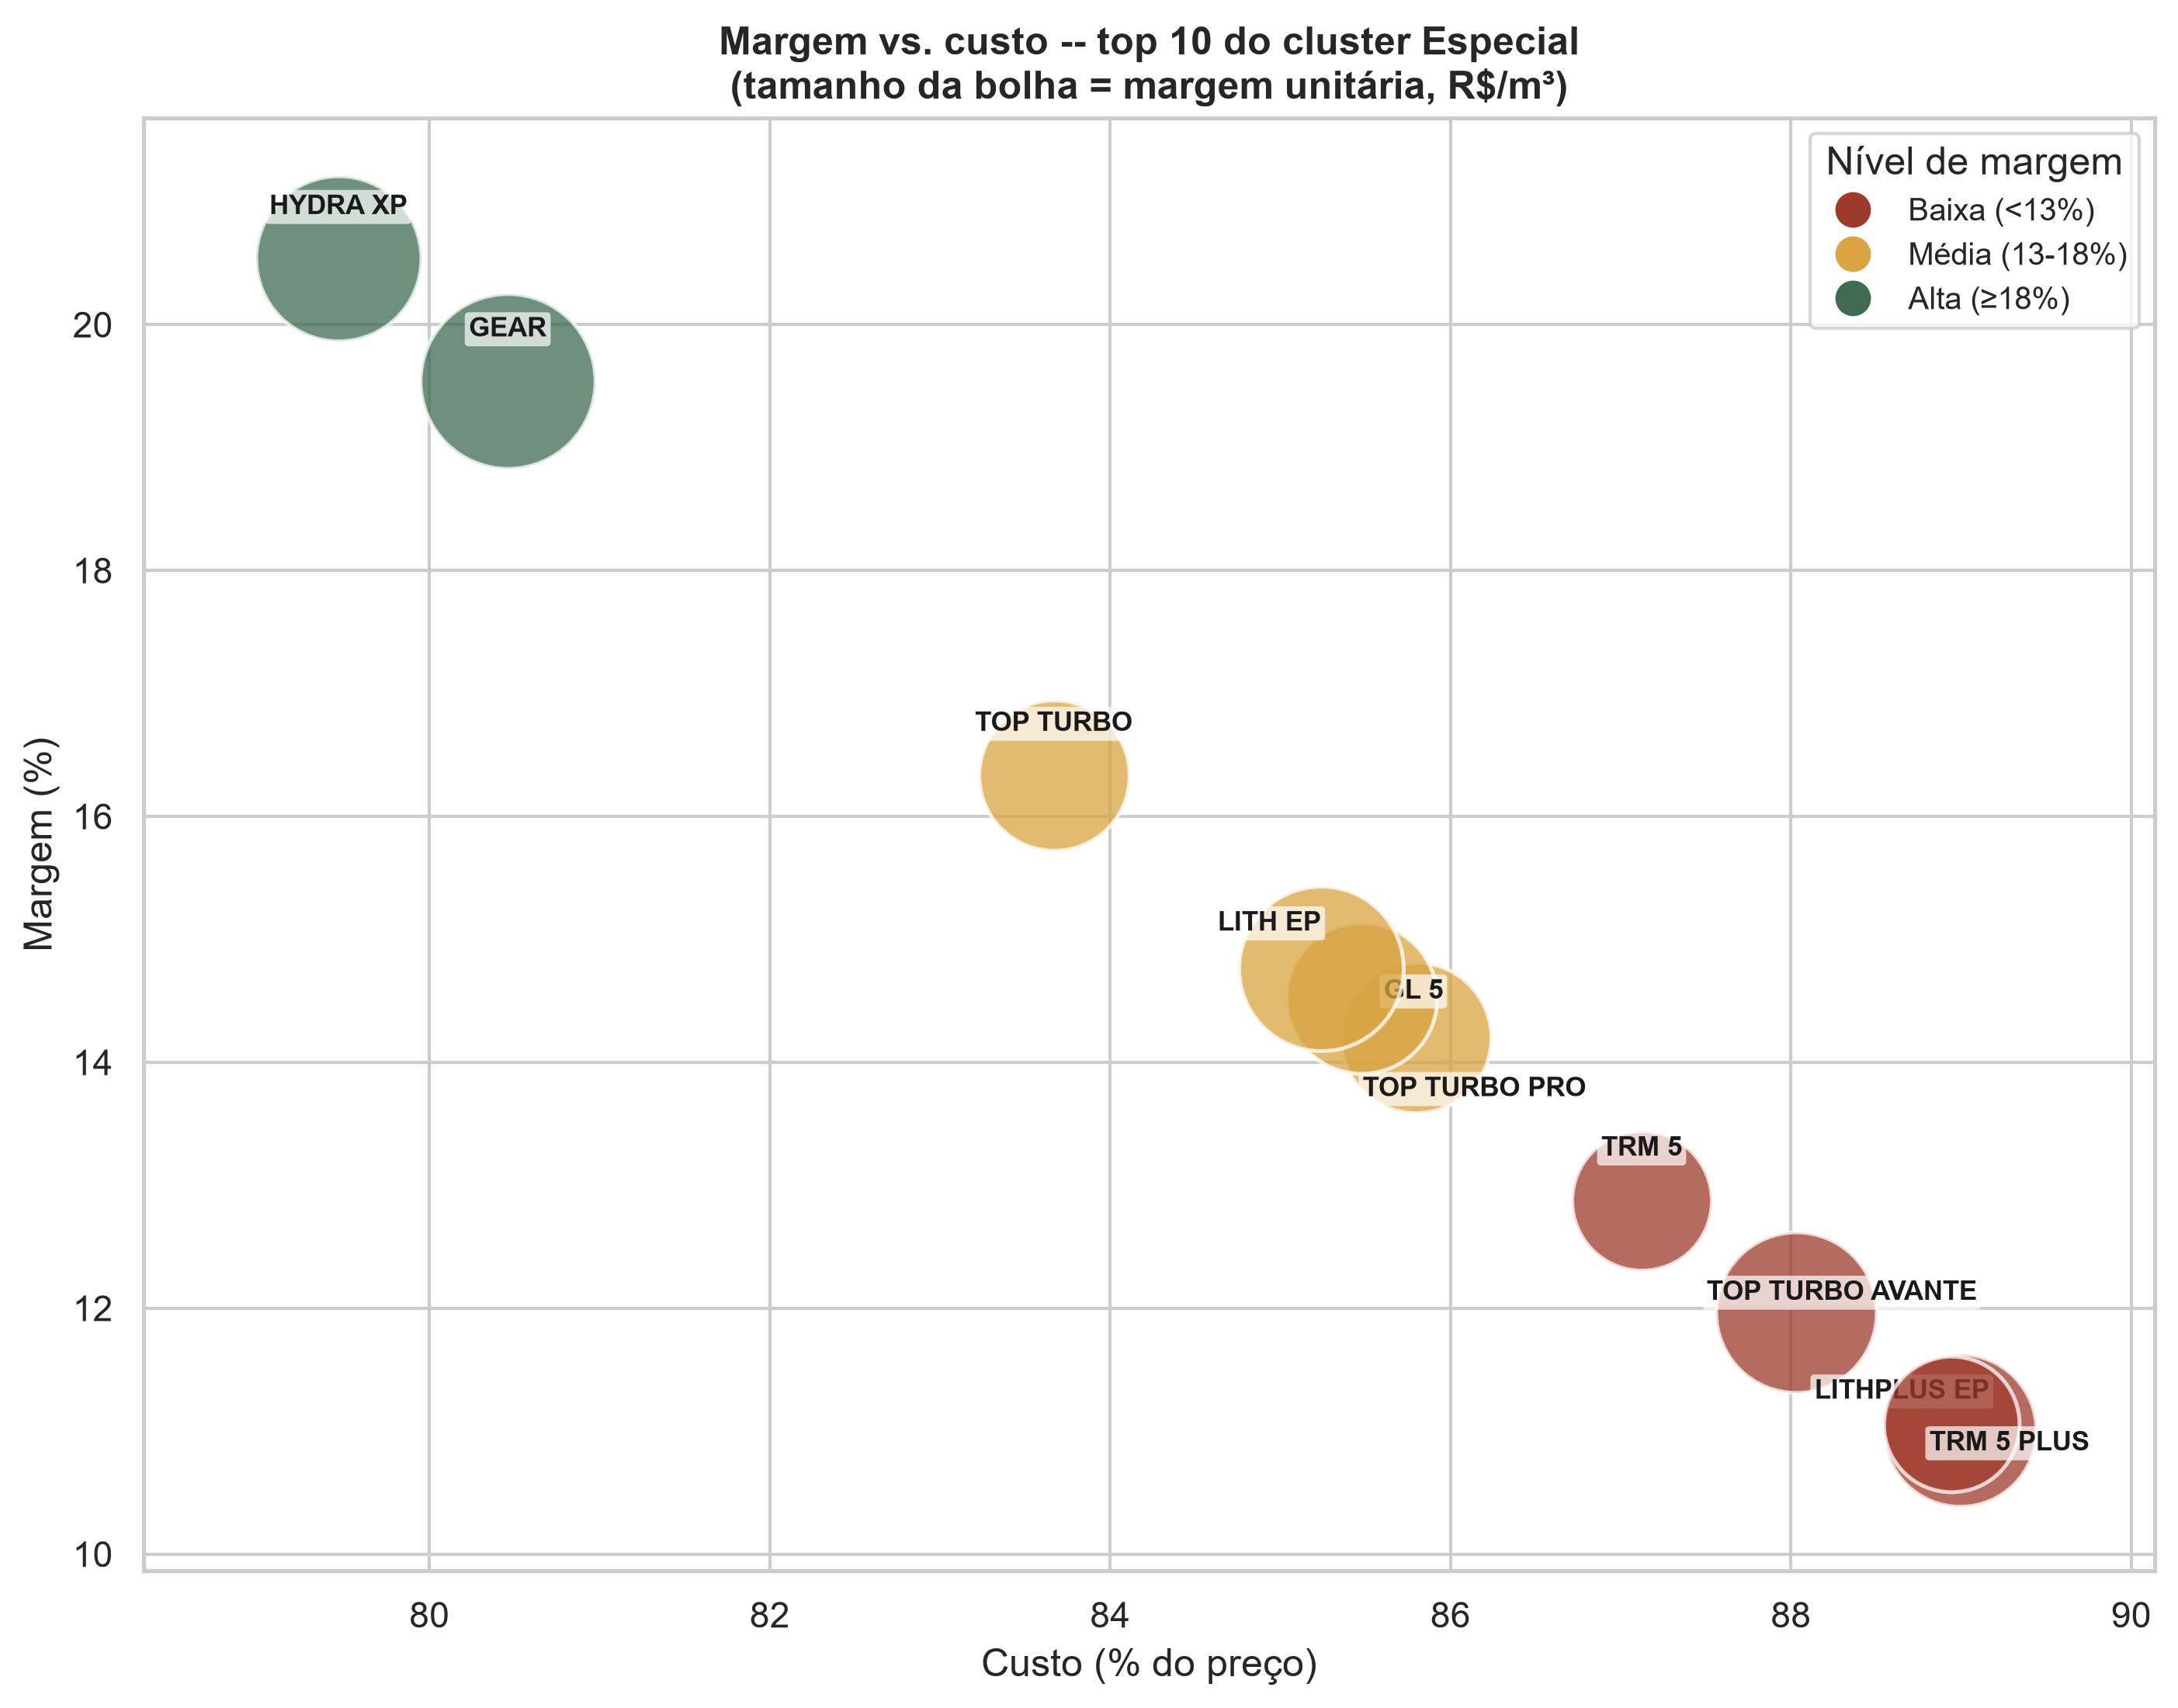

In [13]:
Image(filename=HIBRIDA / 'bolha_margem_custo_especial.png', width=850)


**Achado:** as bolhas vermelhas (margem Baixa) ficam concentradas no canto de maior custo relativo — exatamente onde estão as famílias exclusivas mais caras do Especial. As bolhas verdes (margem Alta) ficam no canto oposto, com custo relativo bem menor.


### O frete explica a margem baixa desses produtos?

A hipótese natural, dado tudo que vimos até aqui sobre frete/UF, é que os produtos de margem Baixa custem mais para entregar. Testamos: qual o frete médio dos clientes que compram esses produtos, dentro do próprio Especial, comparado aos que compram os outros produtos do top 10?


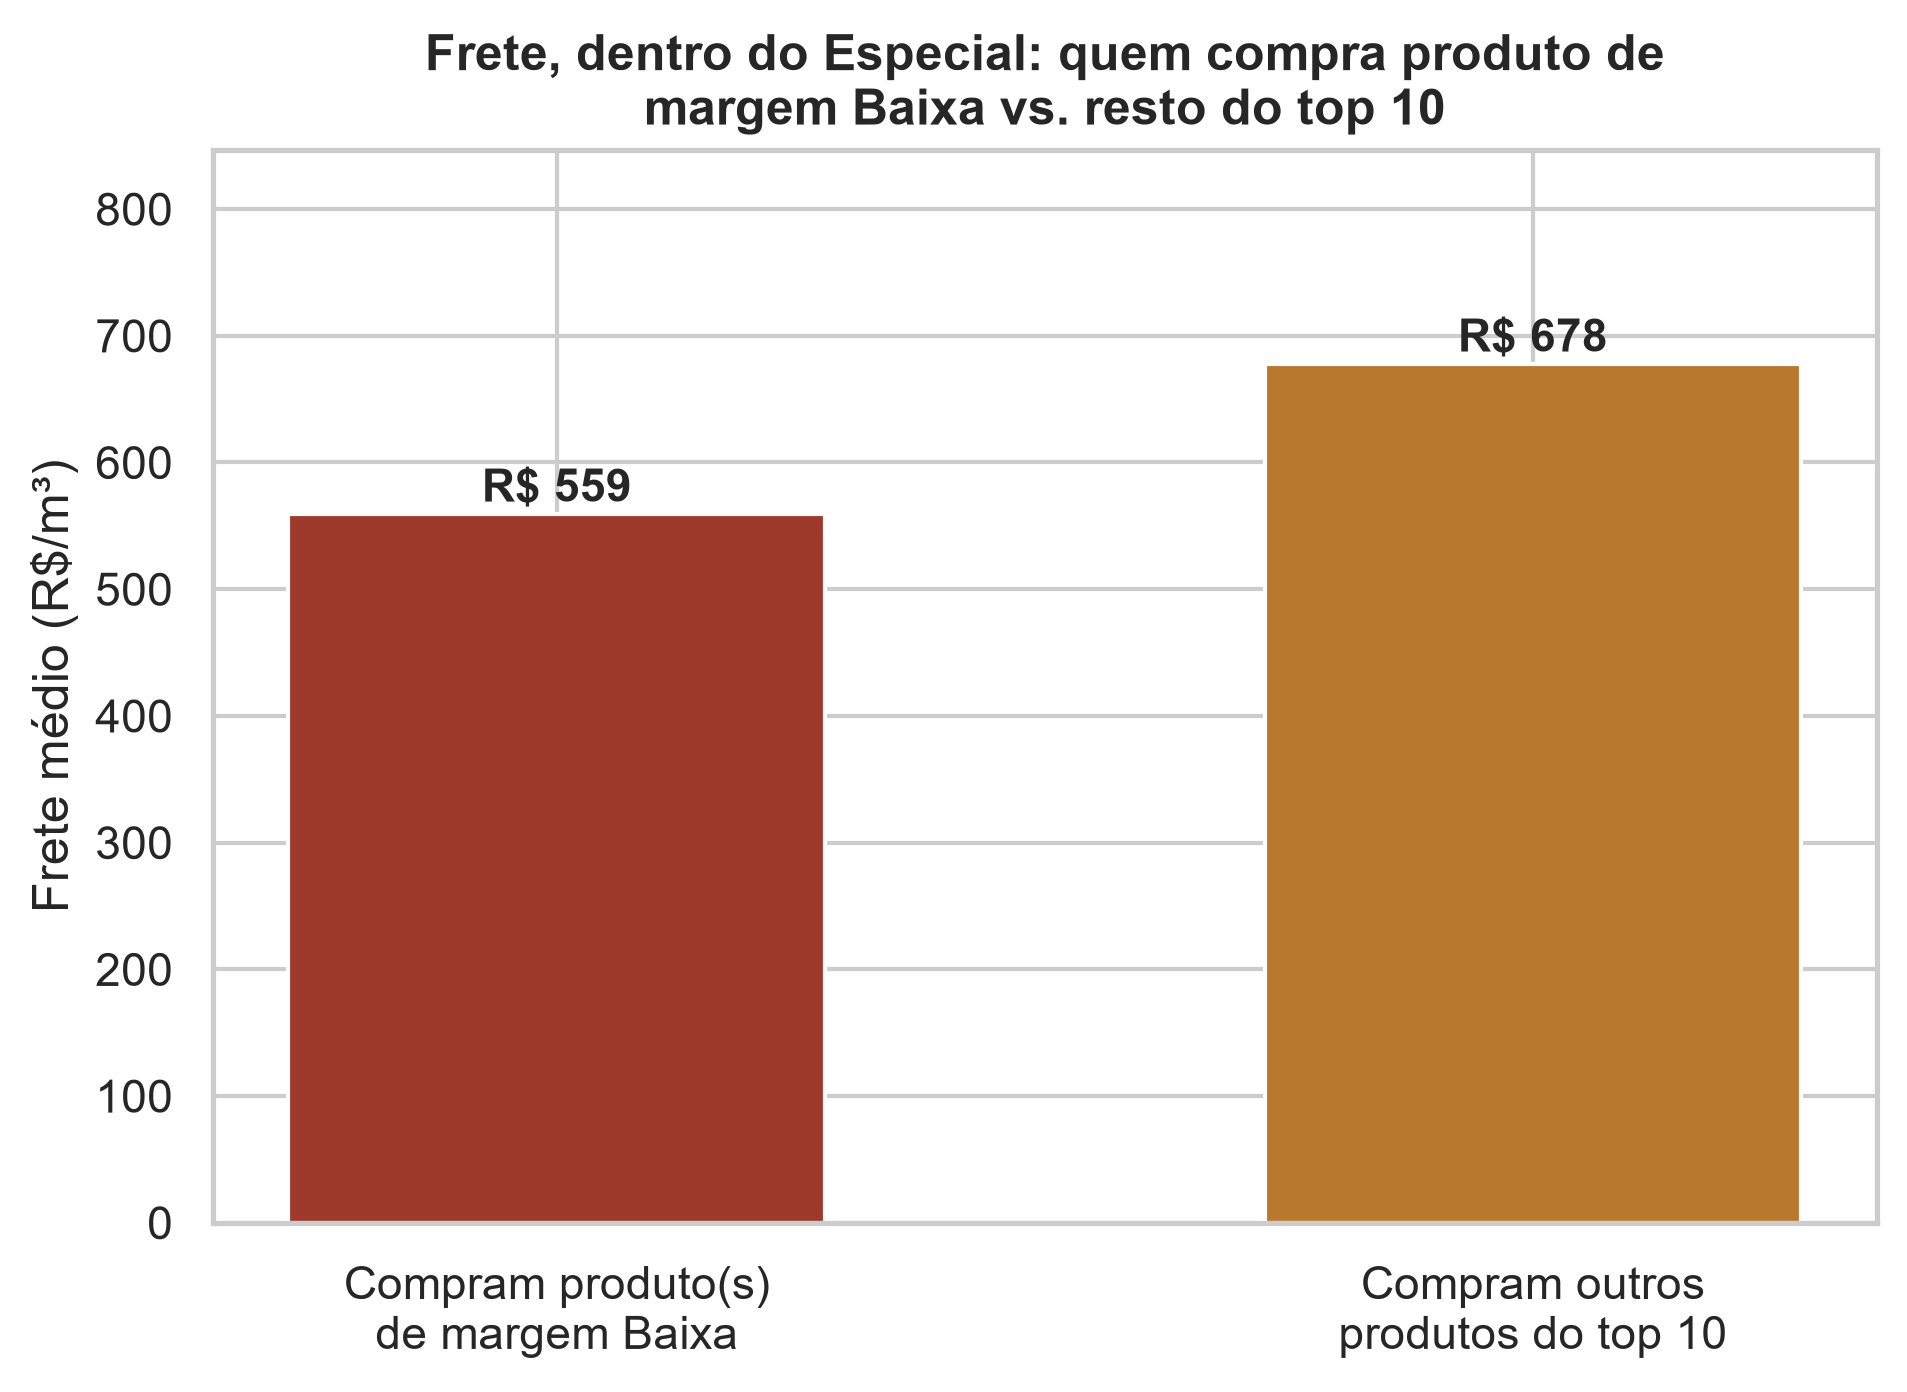

In [14]:
Image(filename=HIBRIDA / 'frete_produtos_margem_baixa.png', width=650)


**Achado: não é frete.** O frete médio de quem compra os produtos de margem Baixa (R$ 559/m³, n=440) é, na verdade, **menor** que o de quem compra os outros produtos do top 10 (R$ 678/m³, n=411) — o frete não explica a margem apertada desses 4 produtos especificamente. O achado de frete/UF (seção 6) segue válido no nível agregado do cluster, mas não é a causa da margem baixa desses produtos em particular.


### Produtos com margem Baixa no Especial: quantos são, e onde são vendidos

4 dos 10 produtos do top 10 do Especial caem na faixa de margem Baixa: **LITHPLUS EP**, **TRM 5 PLUS**, **TOP TURBO AVANTE** e **TRM 5**. Em quais UF esses clientes estão?


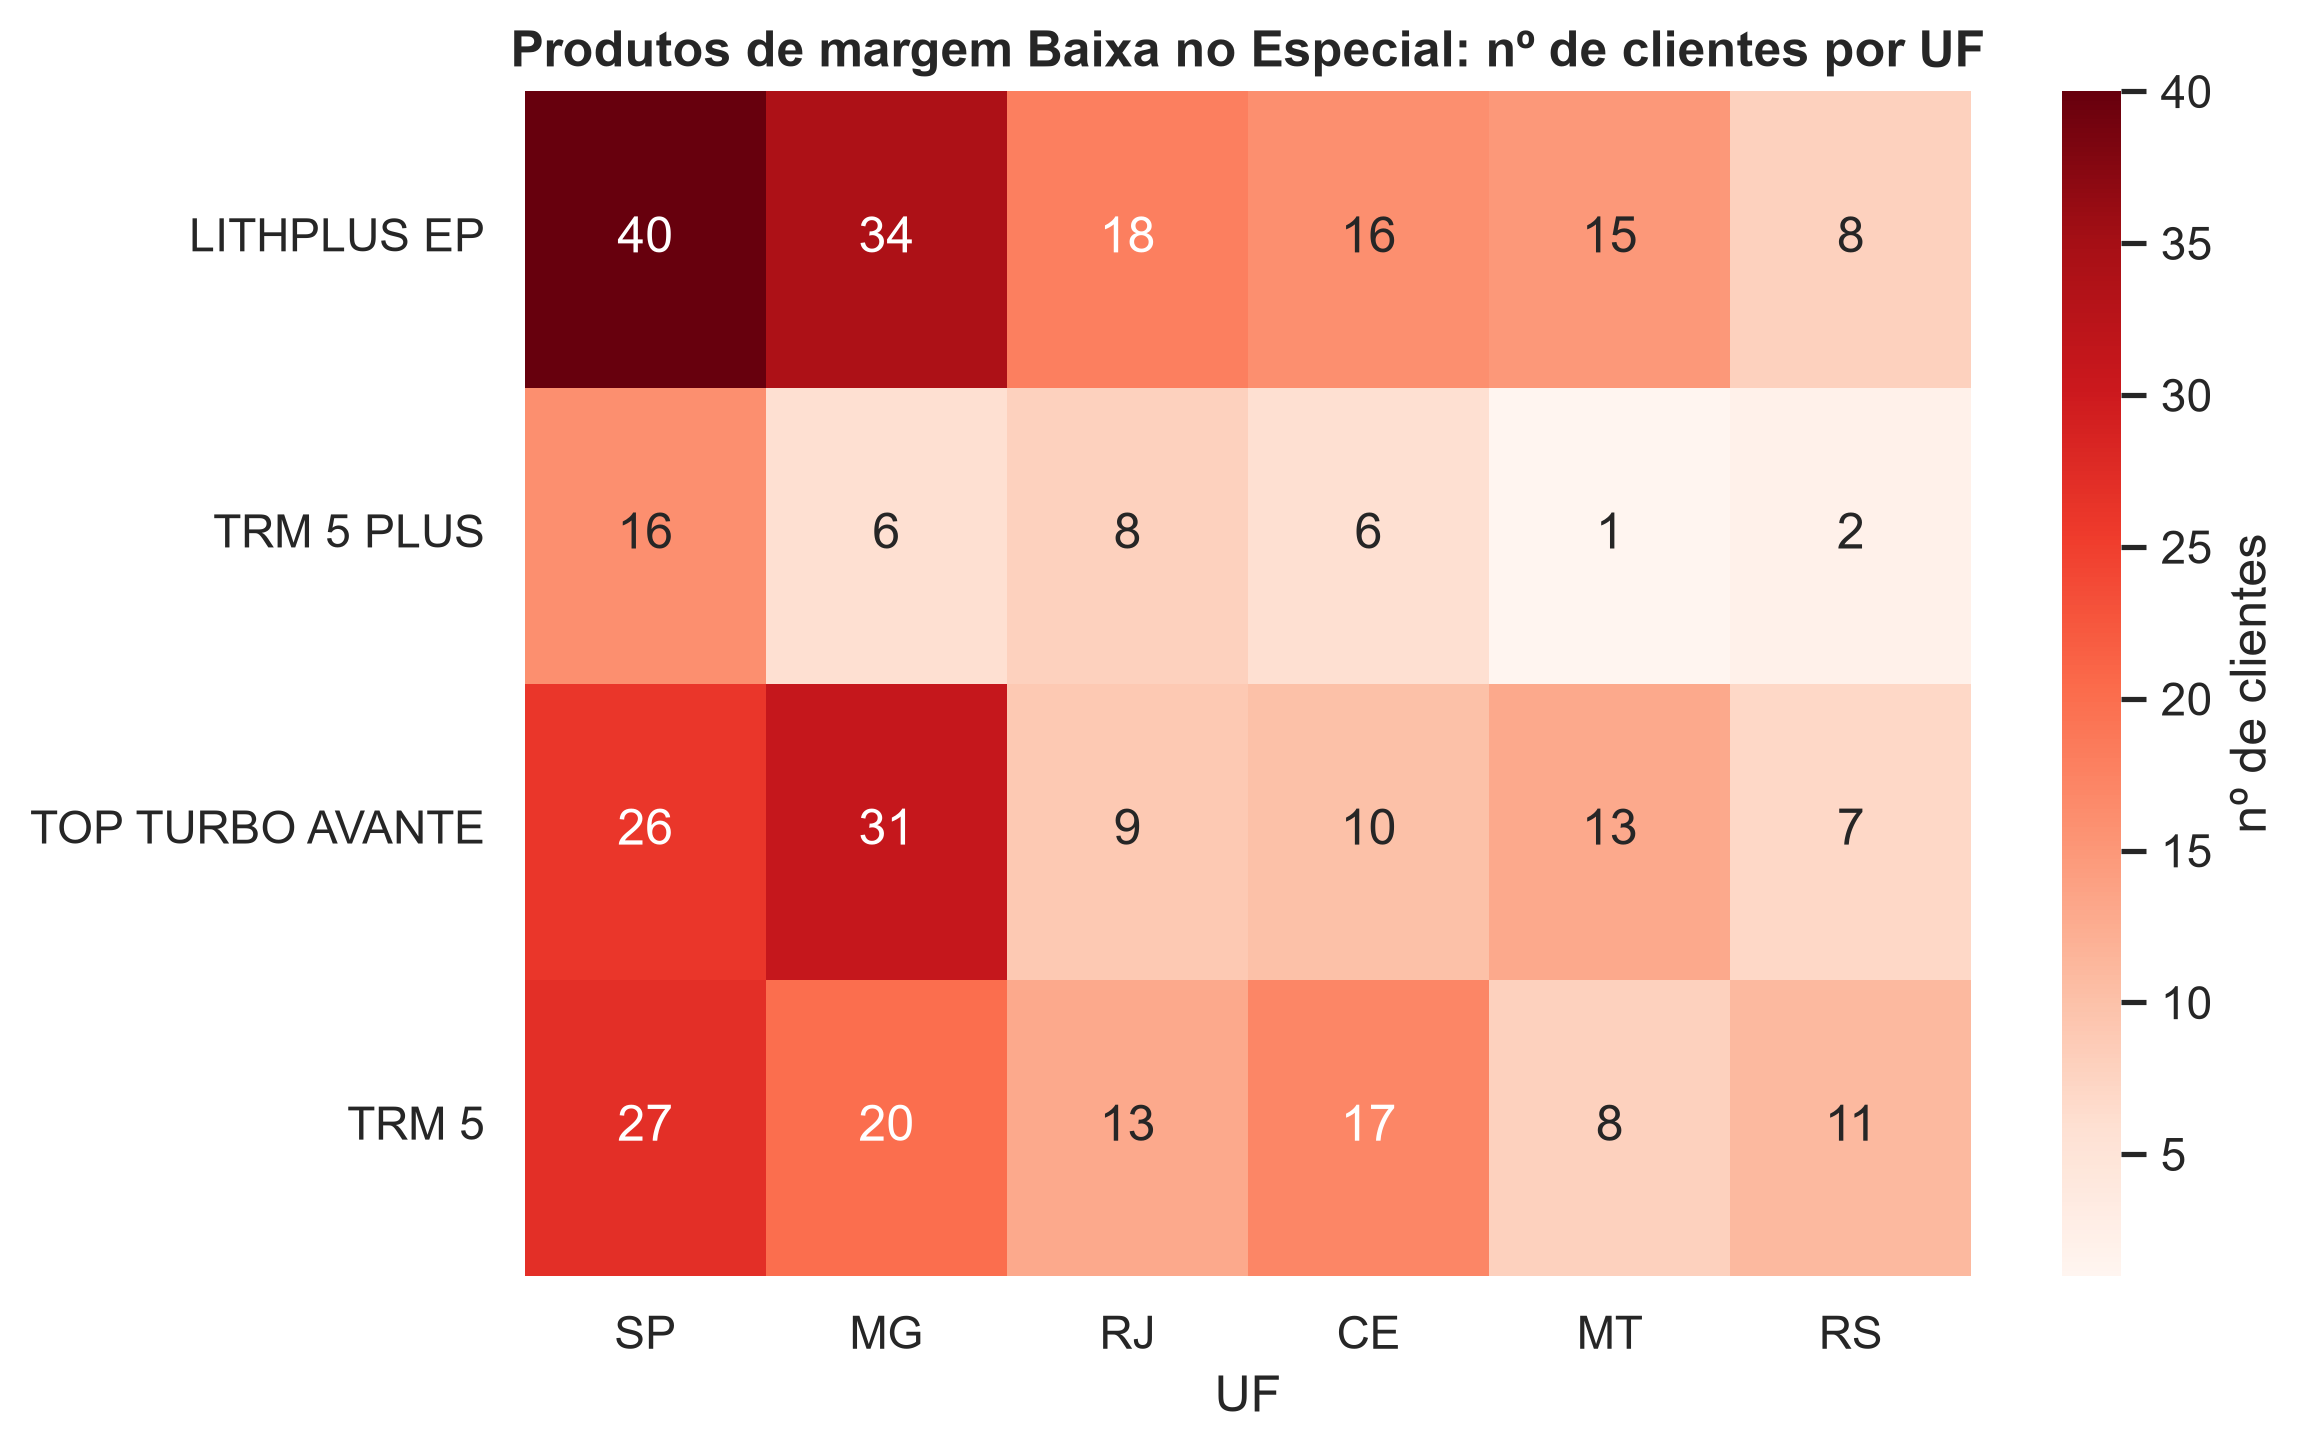

In [15]:
Image(filename=HIBRIDA / 'clientes_uf_produtos_margem_baixa.png', width=800)


**Achado:** 440 clientes (44,1% do Especial) compram pelo menos um desses 4 produtos, espalhados pelas mesmas UFs que já vimos antes (SP, MG, CE e MT concentram a maior parte) — não é um problema geográfico isolado.


### Por que a margem desses 4 produtos é baixa?

Já vimos que não é frete. Testamos a outra hipótese óbvia: será que é um problema comercial específico do Especial (desconto mal calibrado, por exemplo)? Comparamos a margem desses mesmos 4 produtos nos outros 3 clusters:


In [16]:
print('Margem % desses 4 produtos, em cada cluster:')
check = pd.DataFrame({
    'Pequeno': [10.0, 10.1, 9.7, 14.4], 'Grande': [8.6, 9.9, 12.9, 15.7],
    'Especial': [11.0, 11.1, 12.0, 12.9], 'Médio': [9.4, 10.9, 11.3, 15.4],
}, index=['LITHPLUS EP', 'TRM 5 PLUS', 'TOP TURBO AVANTE', 'TRM 5'])
display(check)


Margem % desses 4 produtos, em cada cluster:


,Pequeno,Grande,Especial,Médio
LITHPLUS EP,10.0,8.6,11.0,9.4
TRM 5 PLUS,10.1,9.9,11.1,10.9
TOP TURBO AVANTE,9.7,12.9,12.0,11.3
TRM 5,14.4,15.7,12.9,15.4


**Achado: não é (só) o Especial.** Esses 4 produtos têm margem apertada em **todos os 4 clusters** (8,6% a 15,7%) — não é uma questão de logística, região ou desconto mal aplicado no Especial. Em 2 dos 4 produtos (LITHPLUS EP e TRM 5 PLUS) a margem do Especial é a **melhor** entre os 4 clusters (11,0% e 11,1%); em TOP TURBO AVANTE, fica no meio (12,0%, melhor que Pequeno e Médio, pior que Grande). Só TRM 5 é consistentemente pior no Especial (12,9% vs. 14,4%–15,7% nos demais). A causa mais provável é o **custo de aquisição do próprio produto** (as formulações "PLUS"/"AVANTE" sugerem insumos mais caros), não algo específico do Especial. O que arrasta a média de margem do Especial para baixo é o **mix**: o grupo compra proporcionalmente mais desses produtos inerentemente de margem apertada do que os outros três clusters — não porque recebe um preço ou desconto piores nesses produtos especificamente.


### CNAE por cluster e % de clientes AGRO


In [17]:
print('Top 5 divisões de CNAE por cluster (% de clientes) -- versão simplificada:\n')
for c in sorted(seg['cluster'].unique()):
    sub = seg.loc[seg['cluster'] == c, 'cnae_divisao_nome']
    dist = sub.value_counts(normalize=True).head(5) * 100
    print(f'Cluster {c} ({len(sub):,} clientes):')
    for cnae, pct in dist.items():
        print(f'  {cnae}: {pct:.1f}%')
    print()


Top 5 divisões de CNAE por cluster (% de clientes) -- versão simplificada:

Cluster 0 (4,656 clientes):
  Transporte terrestre: 34.3%
  Obras de infraestrutura: 7.6%
  Aluguel de máquinas e equipamentos: 5.6%
  Comércio por atacado: 4.7%
  Produtos de minerais não-metálicos: 4.2%

Cluster 1 (265 clientes):
  Transporte terrestre: 40.5%
  Extração de minerais não-metálicos: 7.6%
  Obras de infraestrutura: 6.4%
  Produtos de minerais não-metálicos: 4.9%
  Aluguel de máquinas e equipamentos: 4.9%

Cluster 2 (998 clientes):
  Transporte terrestre: 43.2%
  Obras de infraestrutura: 6.6%
  Extração de minerais não-metálicos: 5.5%
  Aluguel de máquinas e equipamentos: 5.0%
  Produtos de minerais não-metálicos: 4.9%

Cluster 3 (1,131 clientes):
  Transporte terrestre: 39.0%
  Extração de minerais não-metálicos: 8.9%
  Aluguel de máquinas e equipamentos: 6.4%
  Obras de infraestrutura: 5.5%
  Serviços especializados para construção: 4.4%



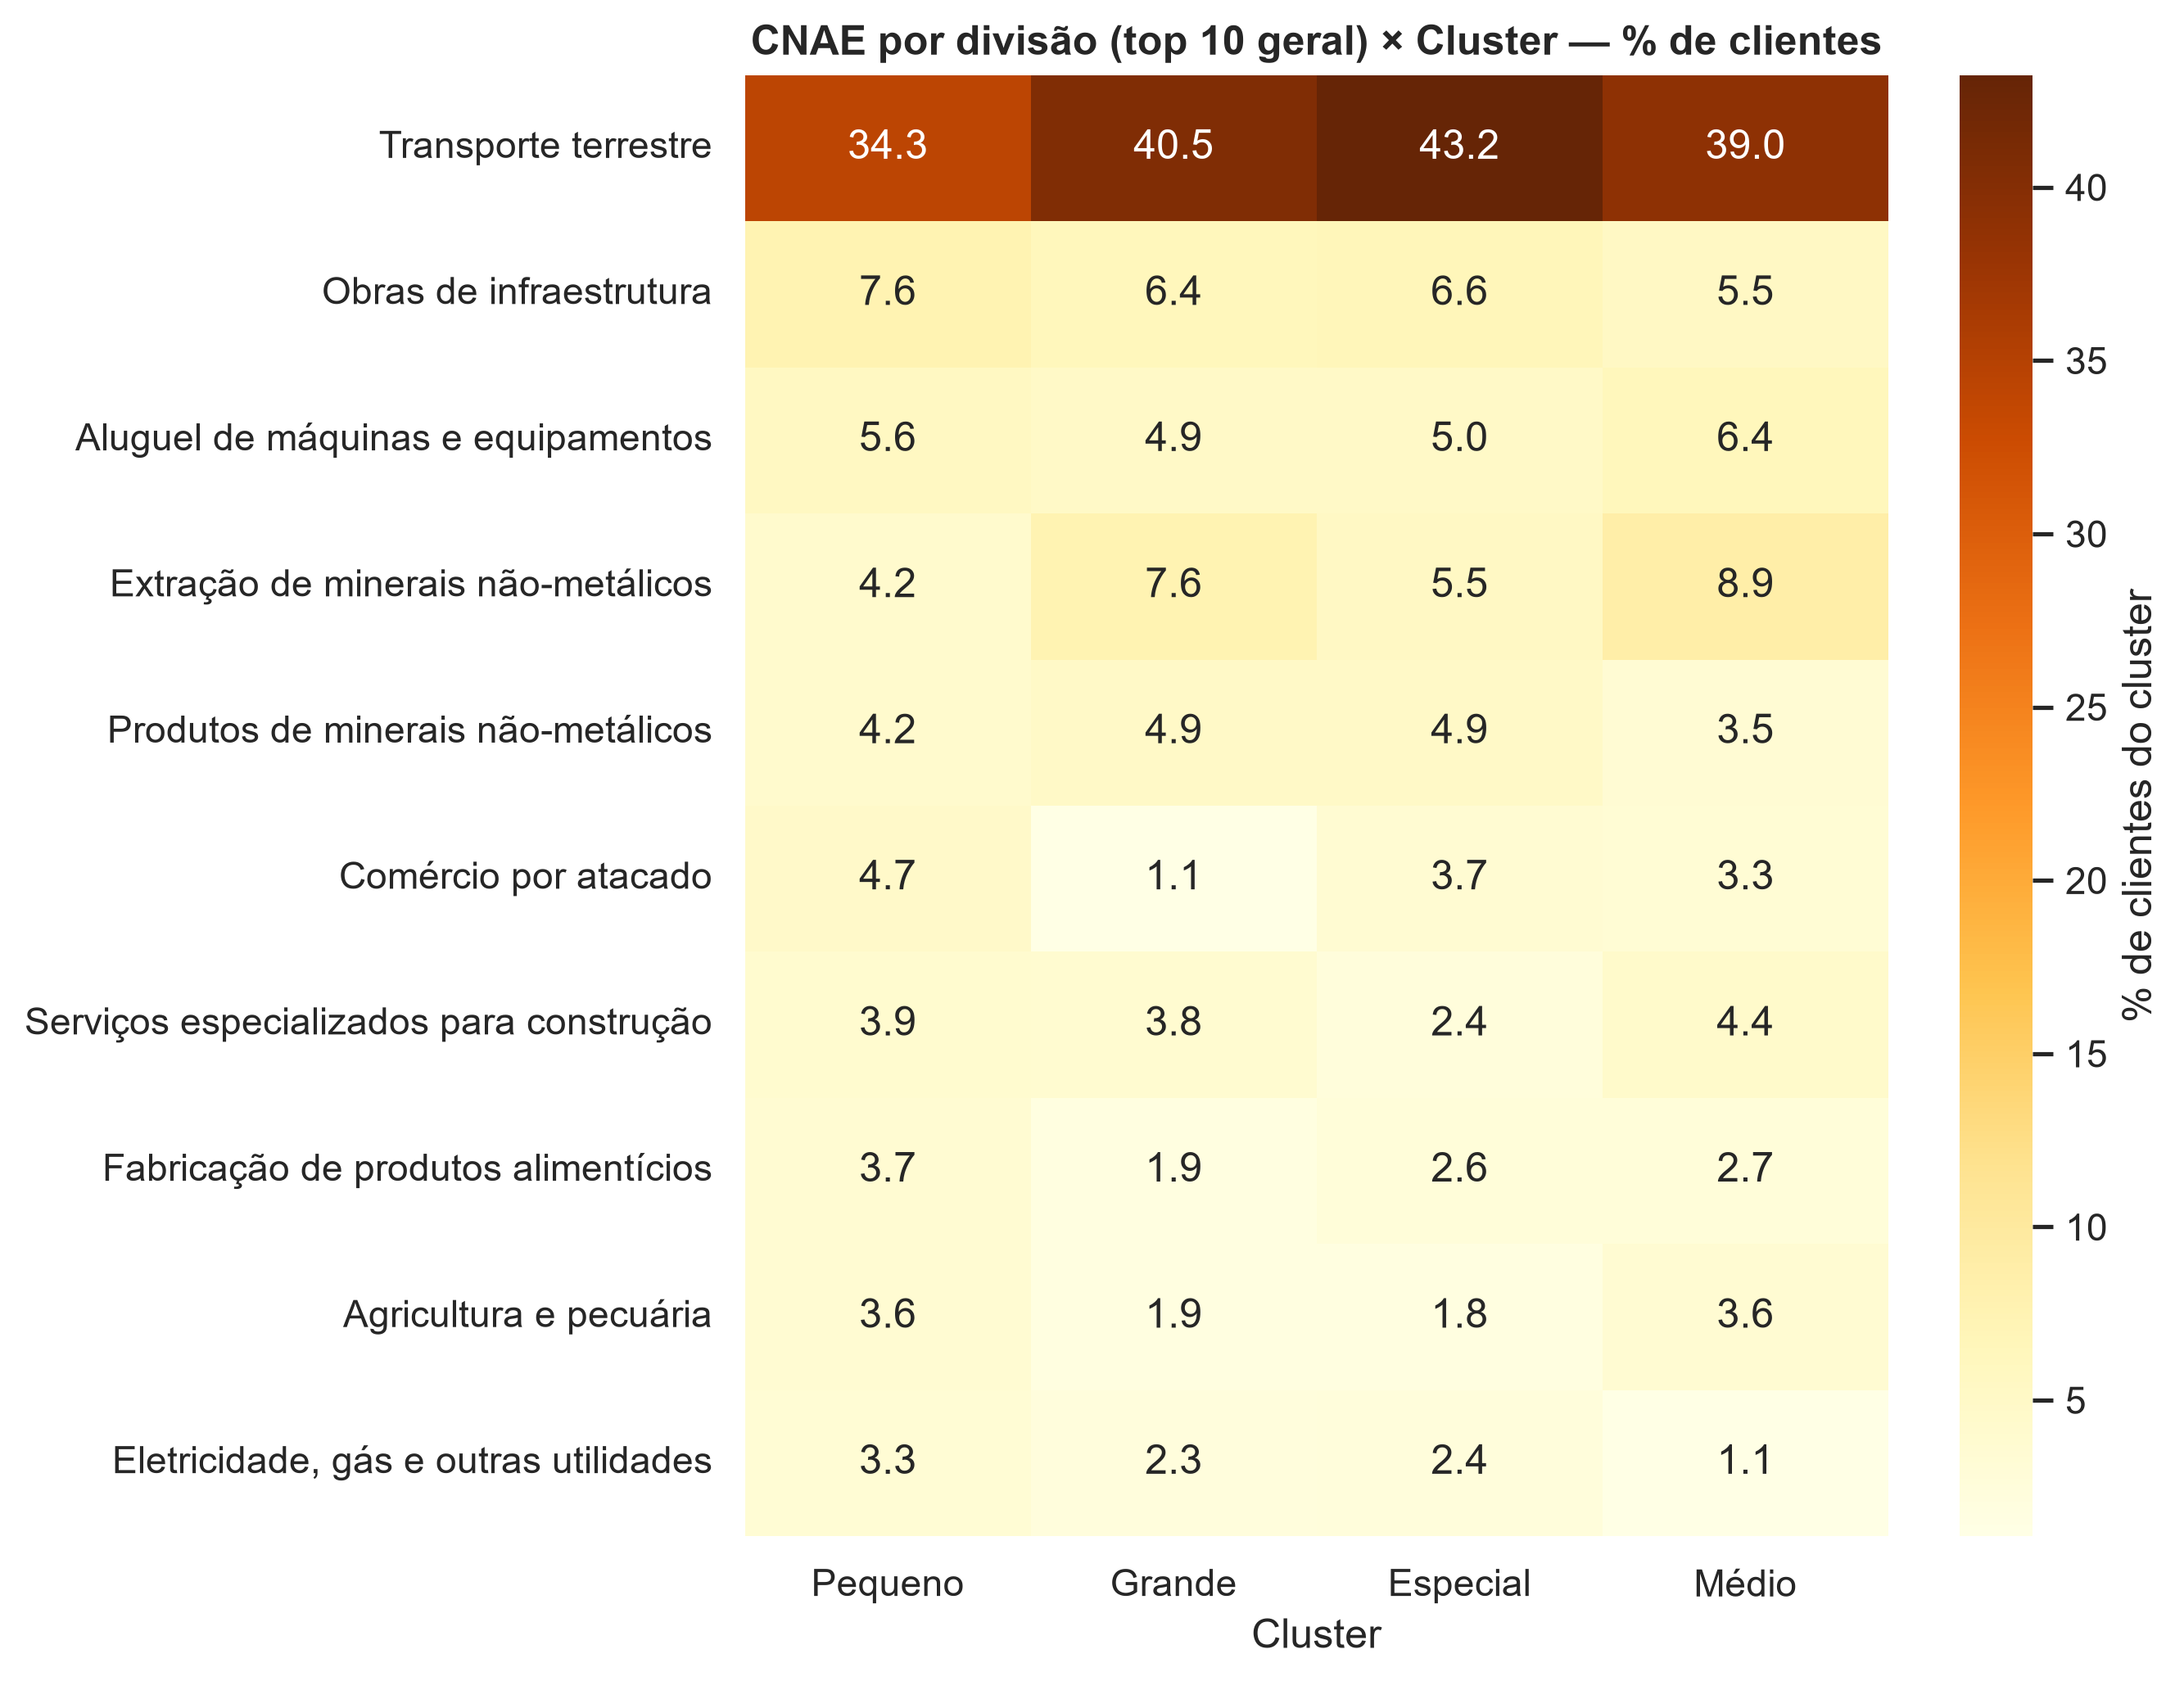

In [18]:
Image(filename=HIBRIDA / 'cnae_por_cluster.png', width=800)


`segmento_b2b` tagueava só 3,9% da base como AGRONEGOCIO — mas esse rótulo mistura agricultura
de verdade (soja, café, laranja...) com pecuária, pesca, madeira e transporte ligado ao agro.
Usando CNAE seção A (divisões 01 agricultura/pecuária, 02 produção florestal, 03 pesca/
aquicultura) para isolar quem é agro de verdade:


In [19]:
cnae_codigo_map = customer_features_full.set_index('Código Cliente')['cnae_codigo']
seg['cnae_codigo'] = seg['Código Cliente'].map(cnae_codigo_map)
seg['cnae_secao_agro'] = seg['cnae_codigo'].astype('string').str[:2].isin(['01', '02', '03'])

pct_agro = seg['cnae_secao_agro'].mean() * 100
print(f"% de clientes AGRO (CNAE seção A): {pct_agro:.2f}% "
      f"({seg['cnae_secao_agro'].sum():,} de {len(seg):,} clientes)\n")
print('% de clientes AGRO por cluster:')
display((seg.groupby('cluster')['cnae_secao_agro'].mean() * 100).round(2))


% de clientes AGRO (CNAE seção A): 4.18% (295 de 7,050 clientes)

% de clientes AGRO por cluster:


cluster
0    4.40
1    3.02
2    2.81
3    4.77
Name: cnae_secao_agro, dtype: float64

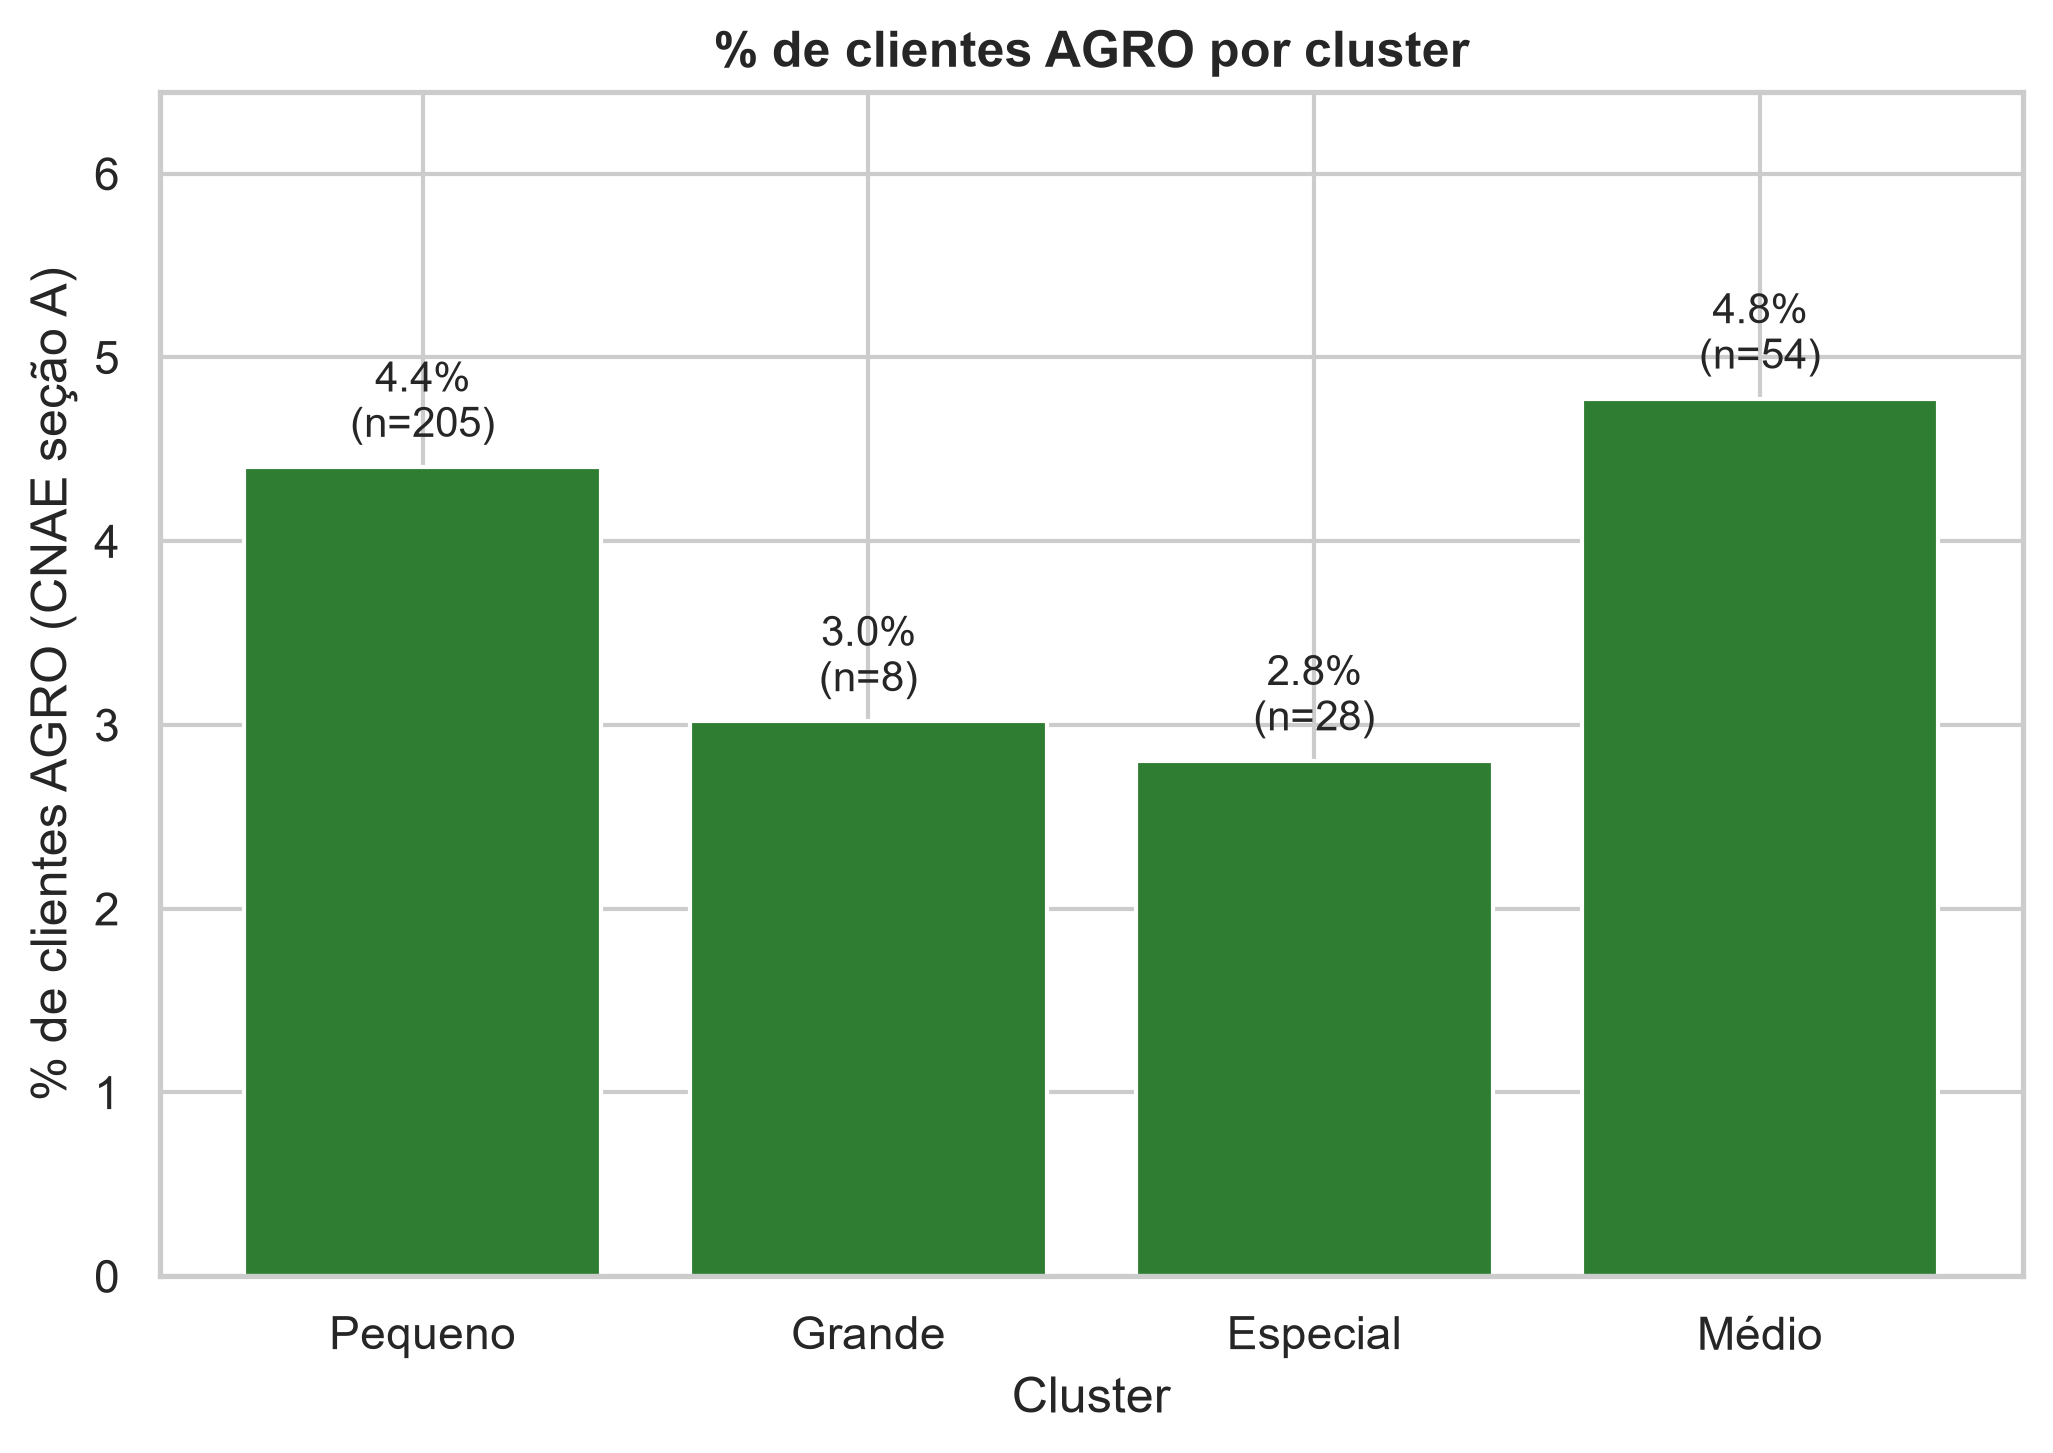

In [20]:
Image(filename=HIBRIDA / 'agro_por_cluster.png', width=550)


Os clientes AGRO não são um bloco único — estão espalhados nos 4 clusters, cada um com um perfil de compra diferente. Olhando a família de produto que compram dentro de cada cluster (% do volume AGRO daquele cluster):


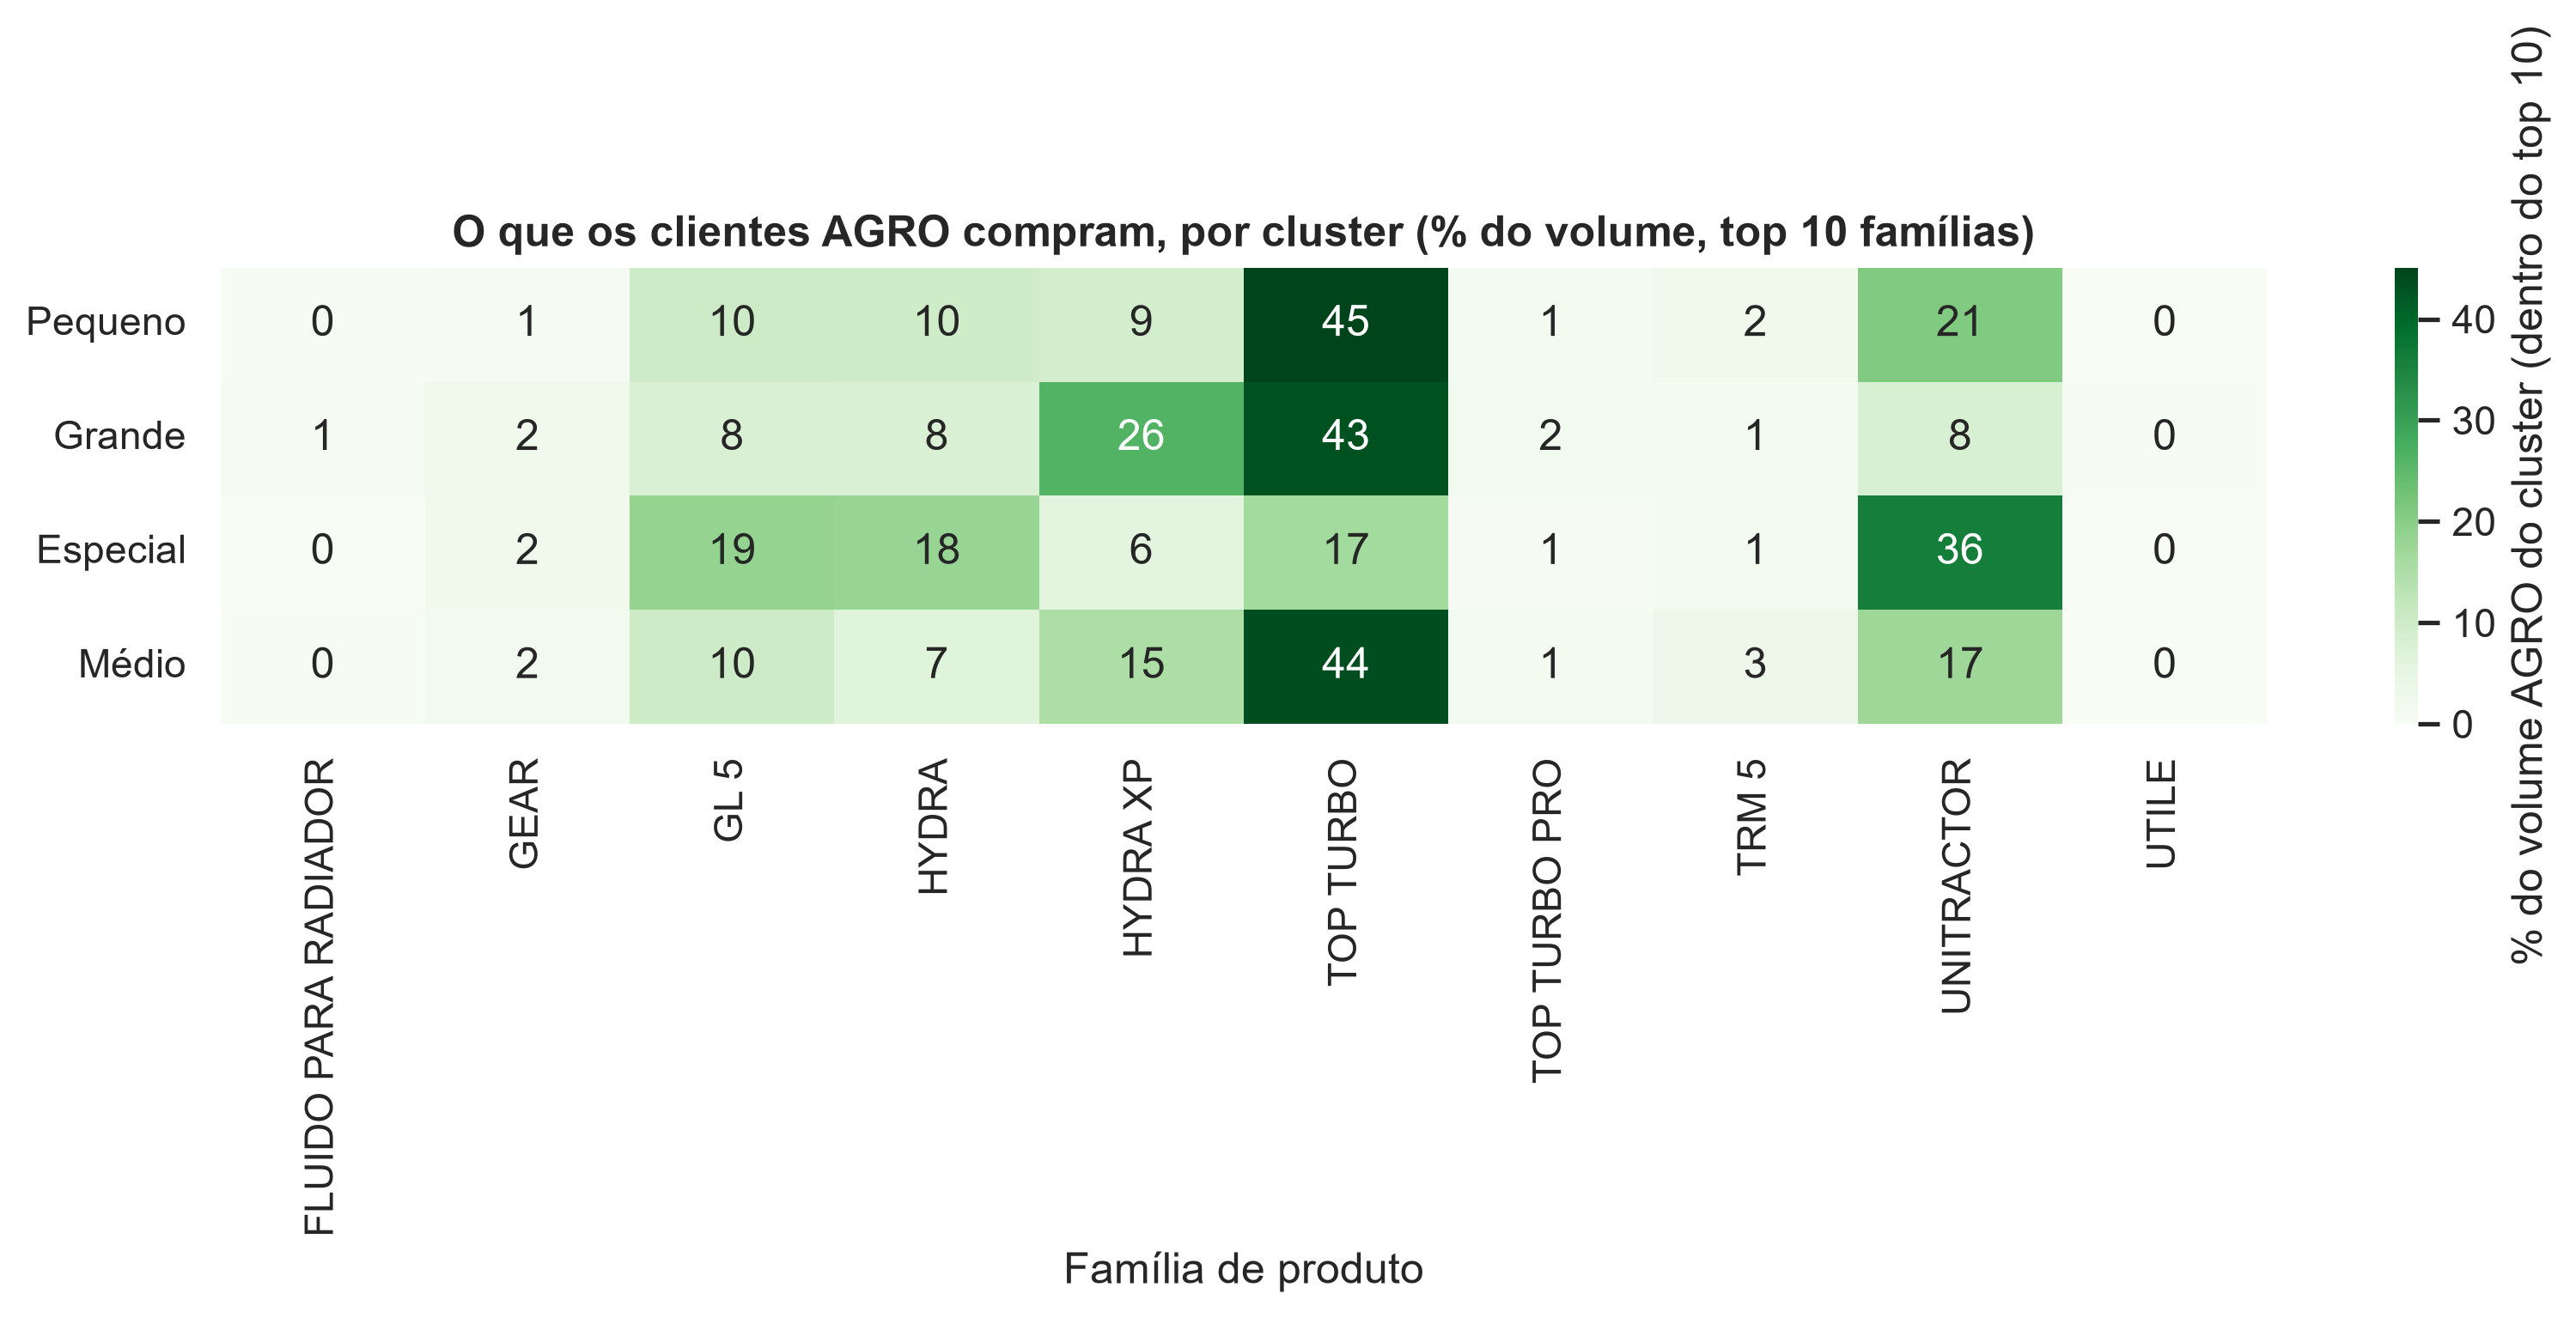

In [21]:
Image(filename=HIBRIDA / 'produtos_agro_por_cluster.png', width=900)


**Próximo passo (não implementado ainda):** cruzar o CNAE de cada cliente AGRO com o
calendário de safra da cultura correspondente (soja, café, laranja etc. têm janelas de
colheita bem diferentes) para testar uma feature de sazonalidade específica desse recorte —
mais promissor do que uma sazonalidade genérica pra base inteira (já testada e descartada por
falta de cobertura de dado para a maioria dos clientes, que não são agro).


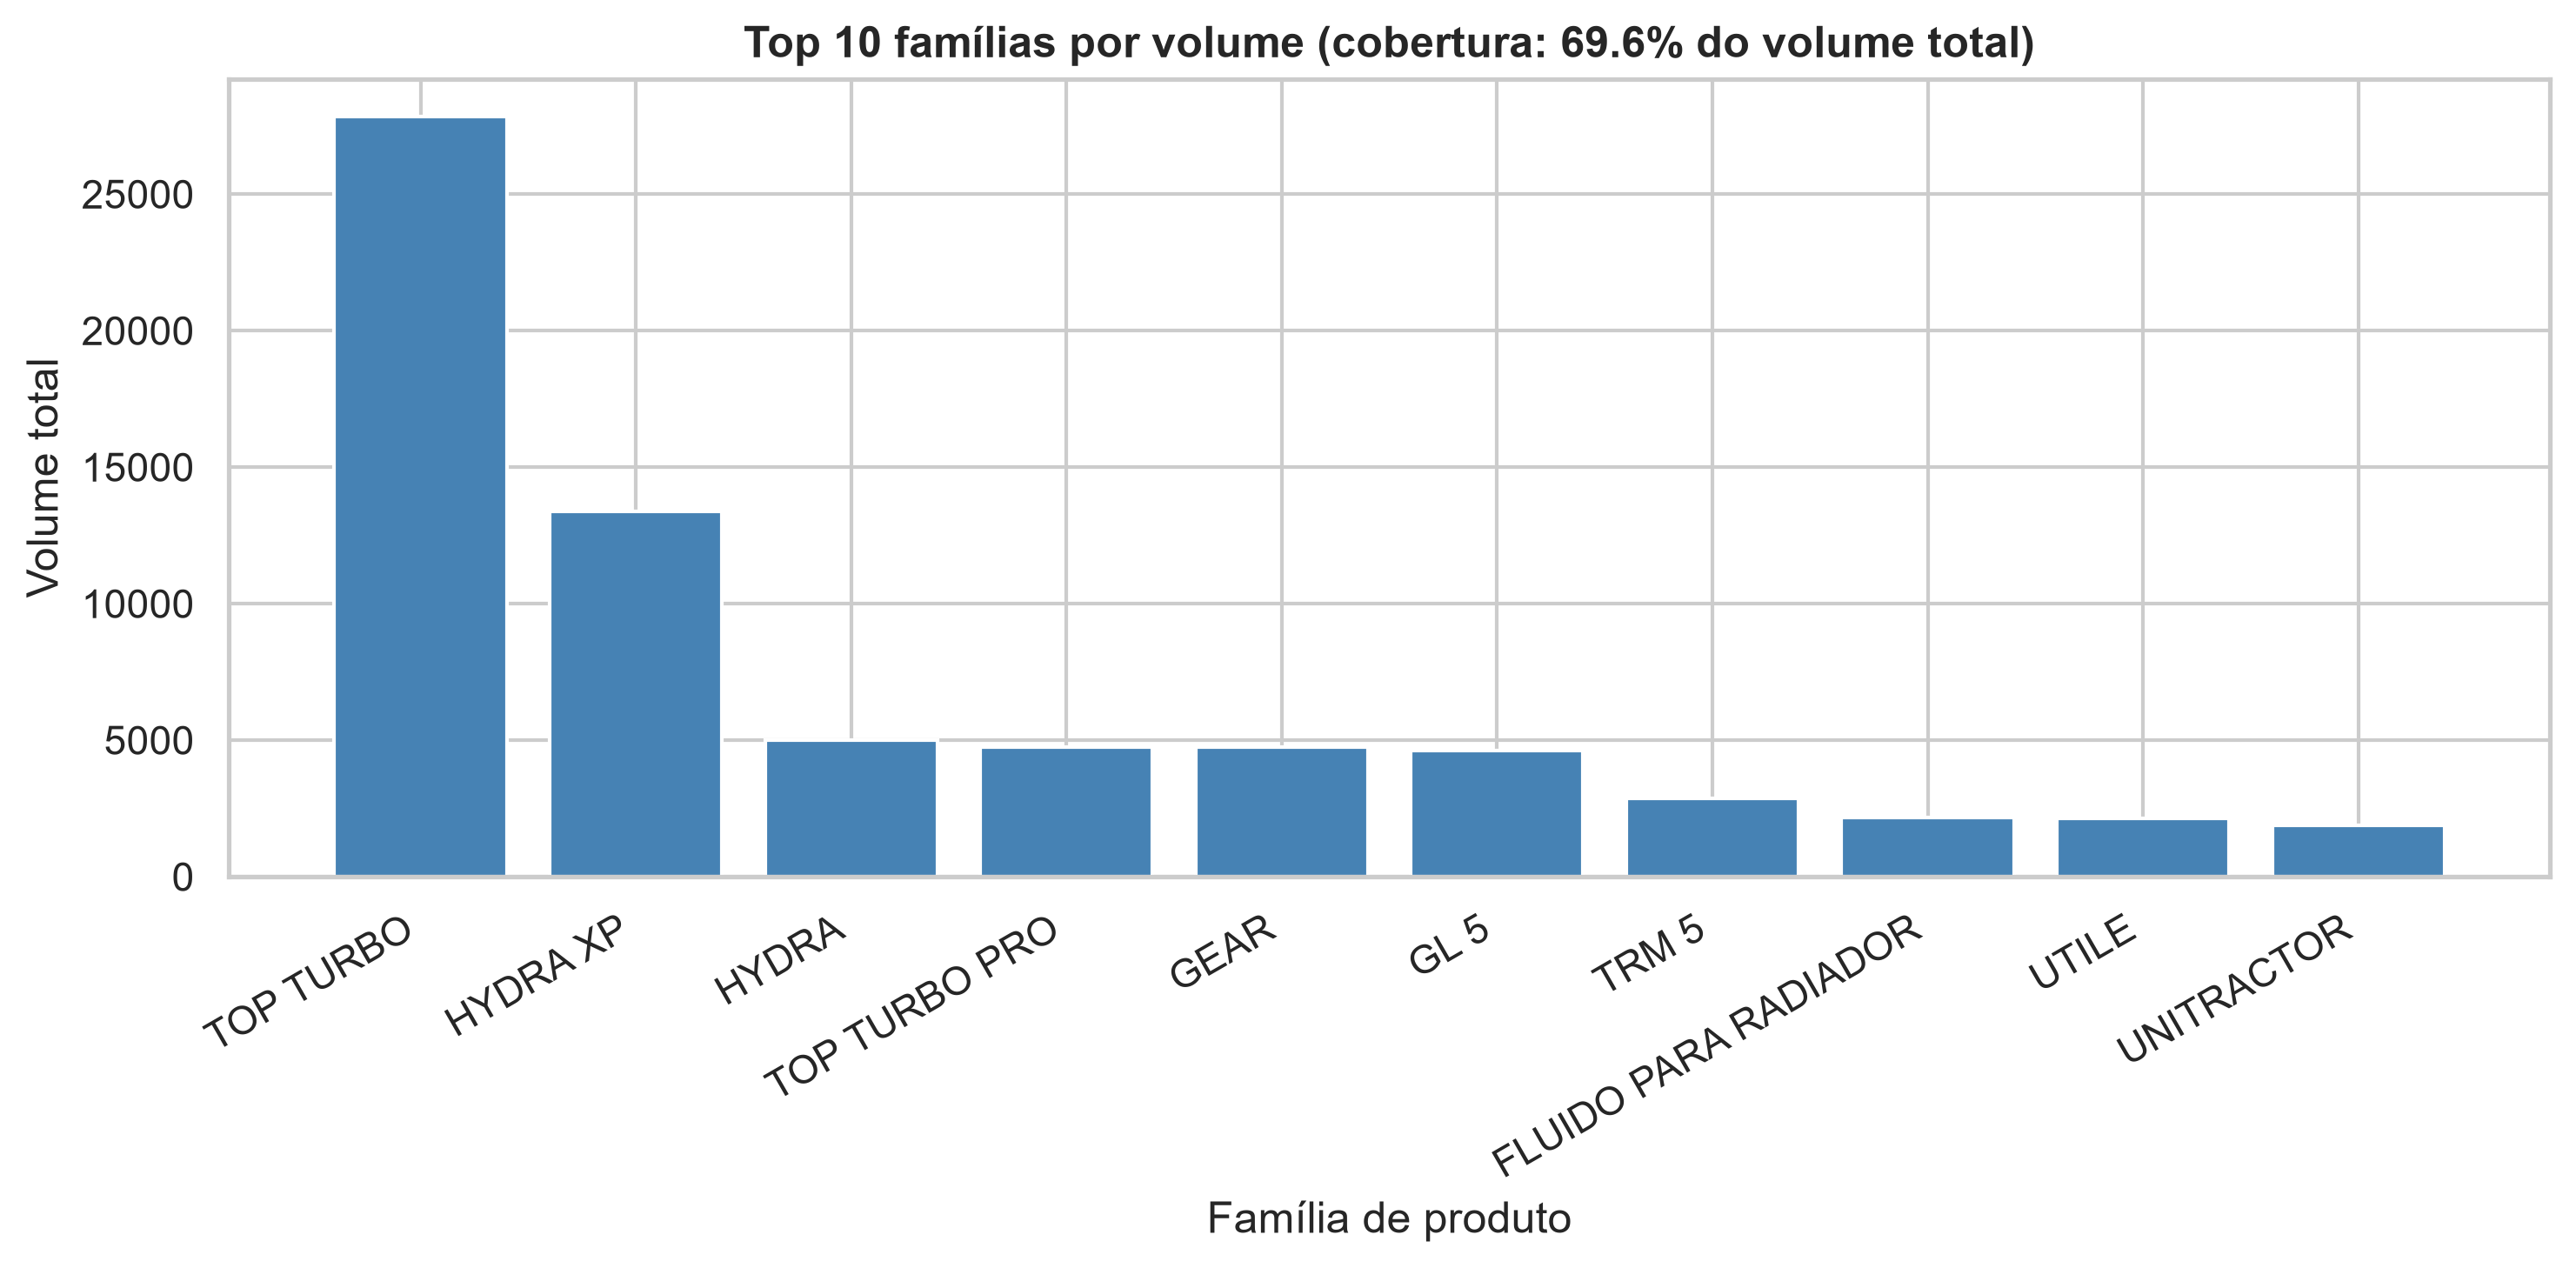

In [22]:
Image(filename=HIBRIDA / 'top_familias.png', width=950)


### Top 10 famílias: quanto pesam no volume e na receita de cada cluster

As 10 famílias com maior volume na base toda, e a participação de cada uma no volume e na receita líquida de cada cluster.


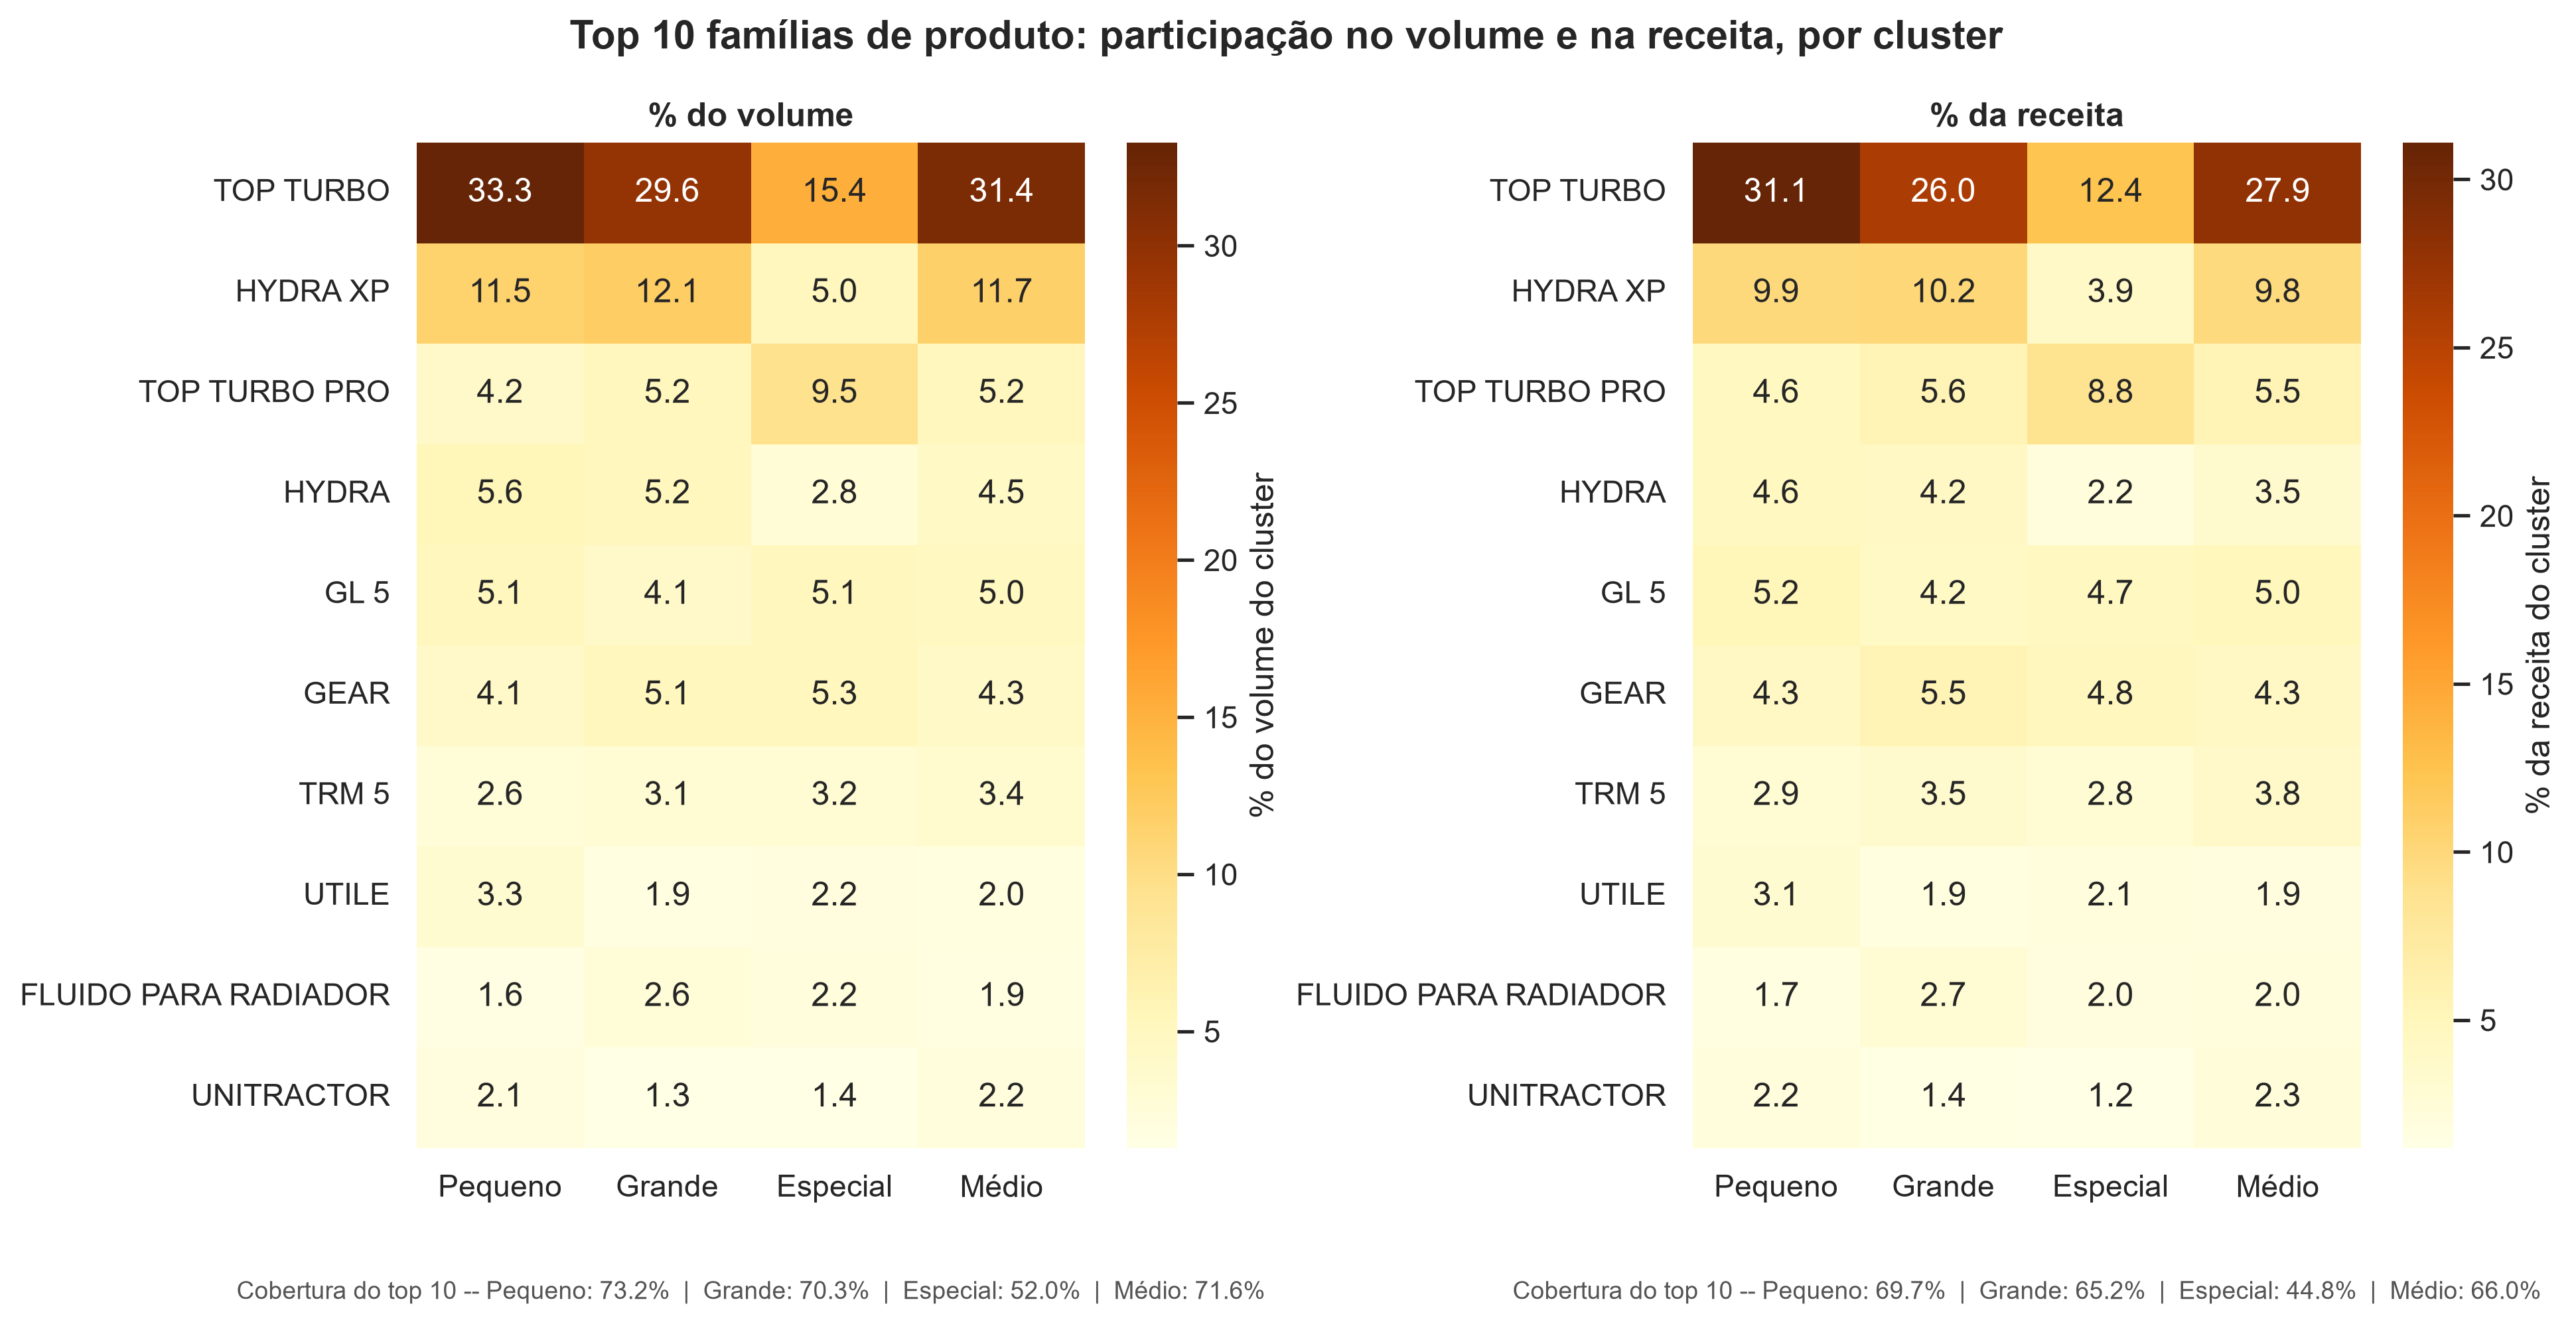

In [23]:
Image(filename=HIBRIDA / 'top10_familias_volume_receita_cluster.png', width=1000)


**Achado:** o Especial tem menos concentração nas famílias líderes — TOP TURBO cai para ~15% do volume e ~12% da receita (contra ~30% nos outros três clusters) — e a cobertura do top 10 cai para **~52% do volume e ~45% da receita**, contra **~65%–73%** nos outros três grupos. Ou seja, quase metade do volume/receita do Especial vem de fora das 10 famílias mais vendidas da base — o mix de produtos do Especial já é um pouco mais disperso. Mas isso sozinho não explica a diferença de preço/margem vista antes — o achado de margem unitária (seção 6) já mostrou que a queda de margem acontece em toda família, dispersa ou não.


### Top 10 famílias — só dentro do cluster Especial

O top 10 acima é o mesmo para os 4 clusters. Recalculando o top 10 usando só as transações do Especial, aparece um conjunto parcialmente diferente:


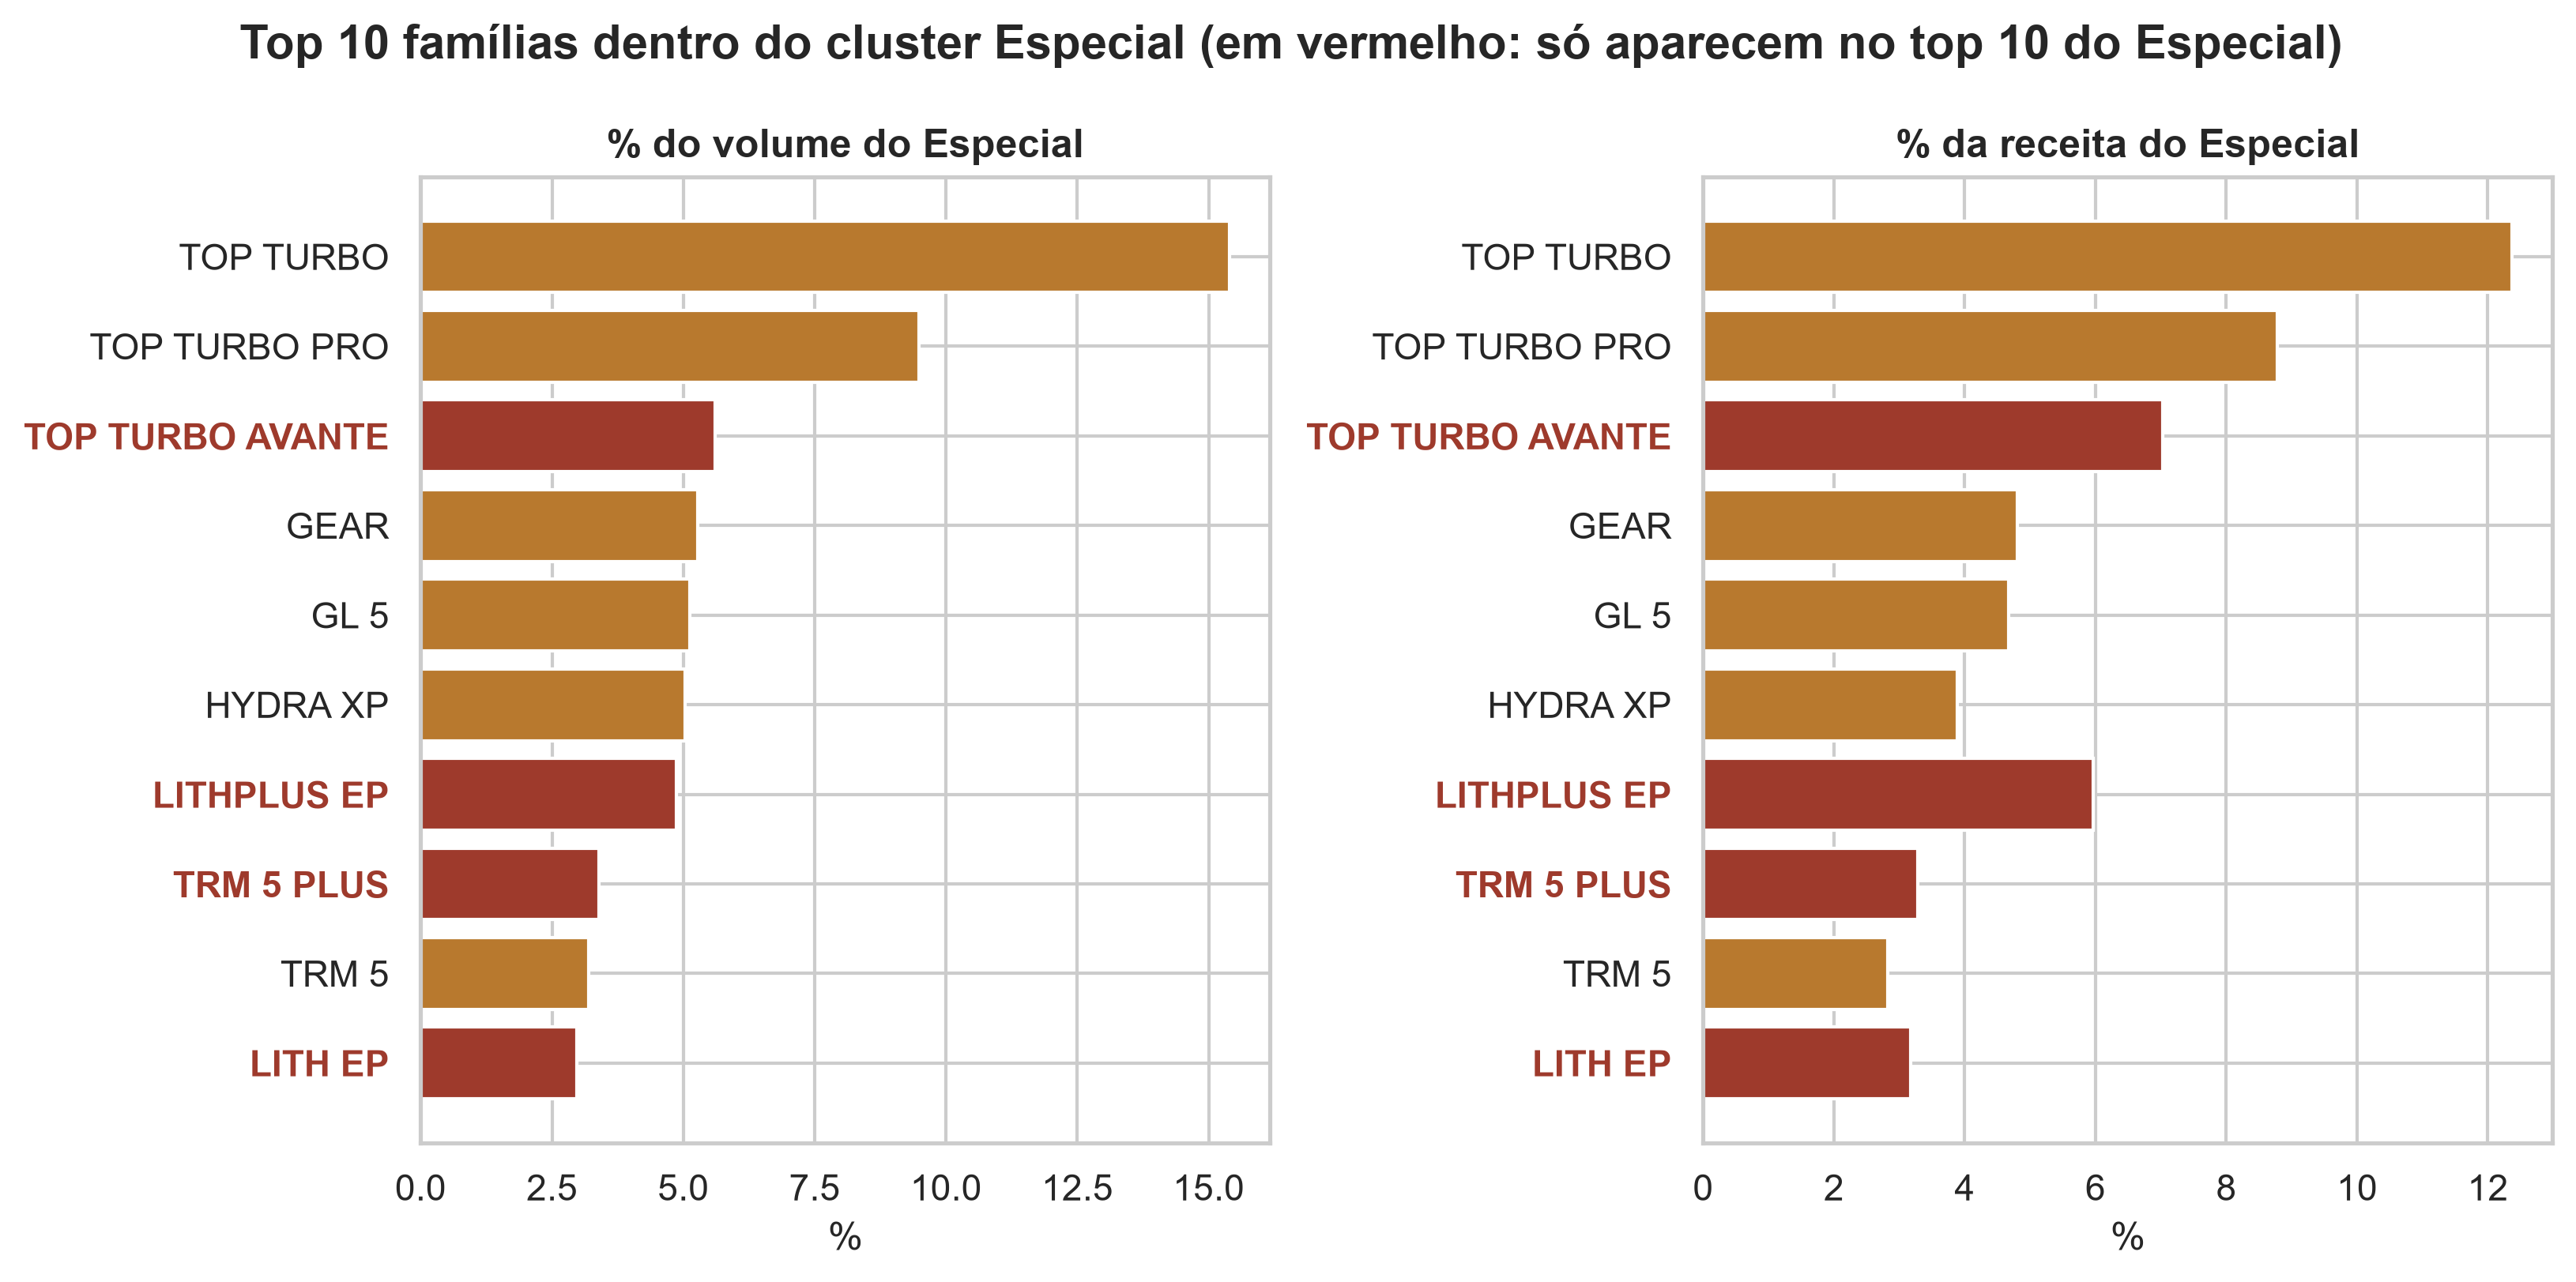

In [24]:
Image(filename=HIBRIDA / 'top10_familias_especial.png', width=1000)


**Achado:** 4 das 10 famílias do top do Especial (**TOP TURBO AVANTE**, **LITHPLUS EP**, **TRM 5 PLUS**, **LITH EP**) não aparecem no top 10 da base toda — o Especial não compra só menos concentrado, compra produtos parcialmente diferentes. Em compensação, 4 famílias do top 10 geral (FLUIDO PARA RADIADOR, HYDRA, UNITRACTOR, UTILE) nem entram no top 10 do Especial. Olhando o próprio Especial, esse top 10 cobre 60,4% do volume e 56,8% da receita — mais que os 52,0%/44,8% do top 10 geral aplicado ao Especial.


Frequência de compra também não se distribui igual entre os clusters:


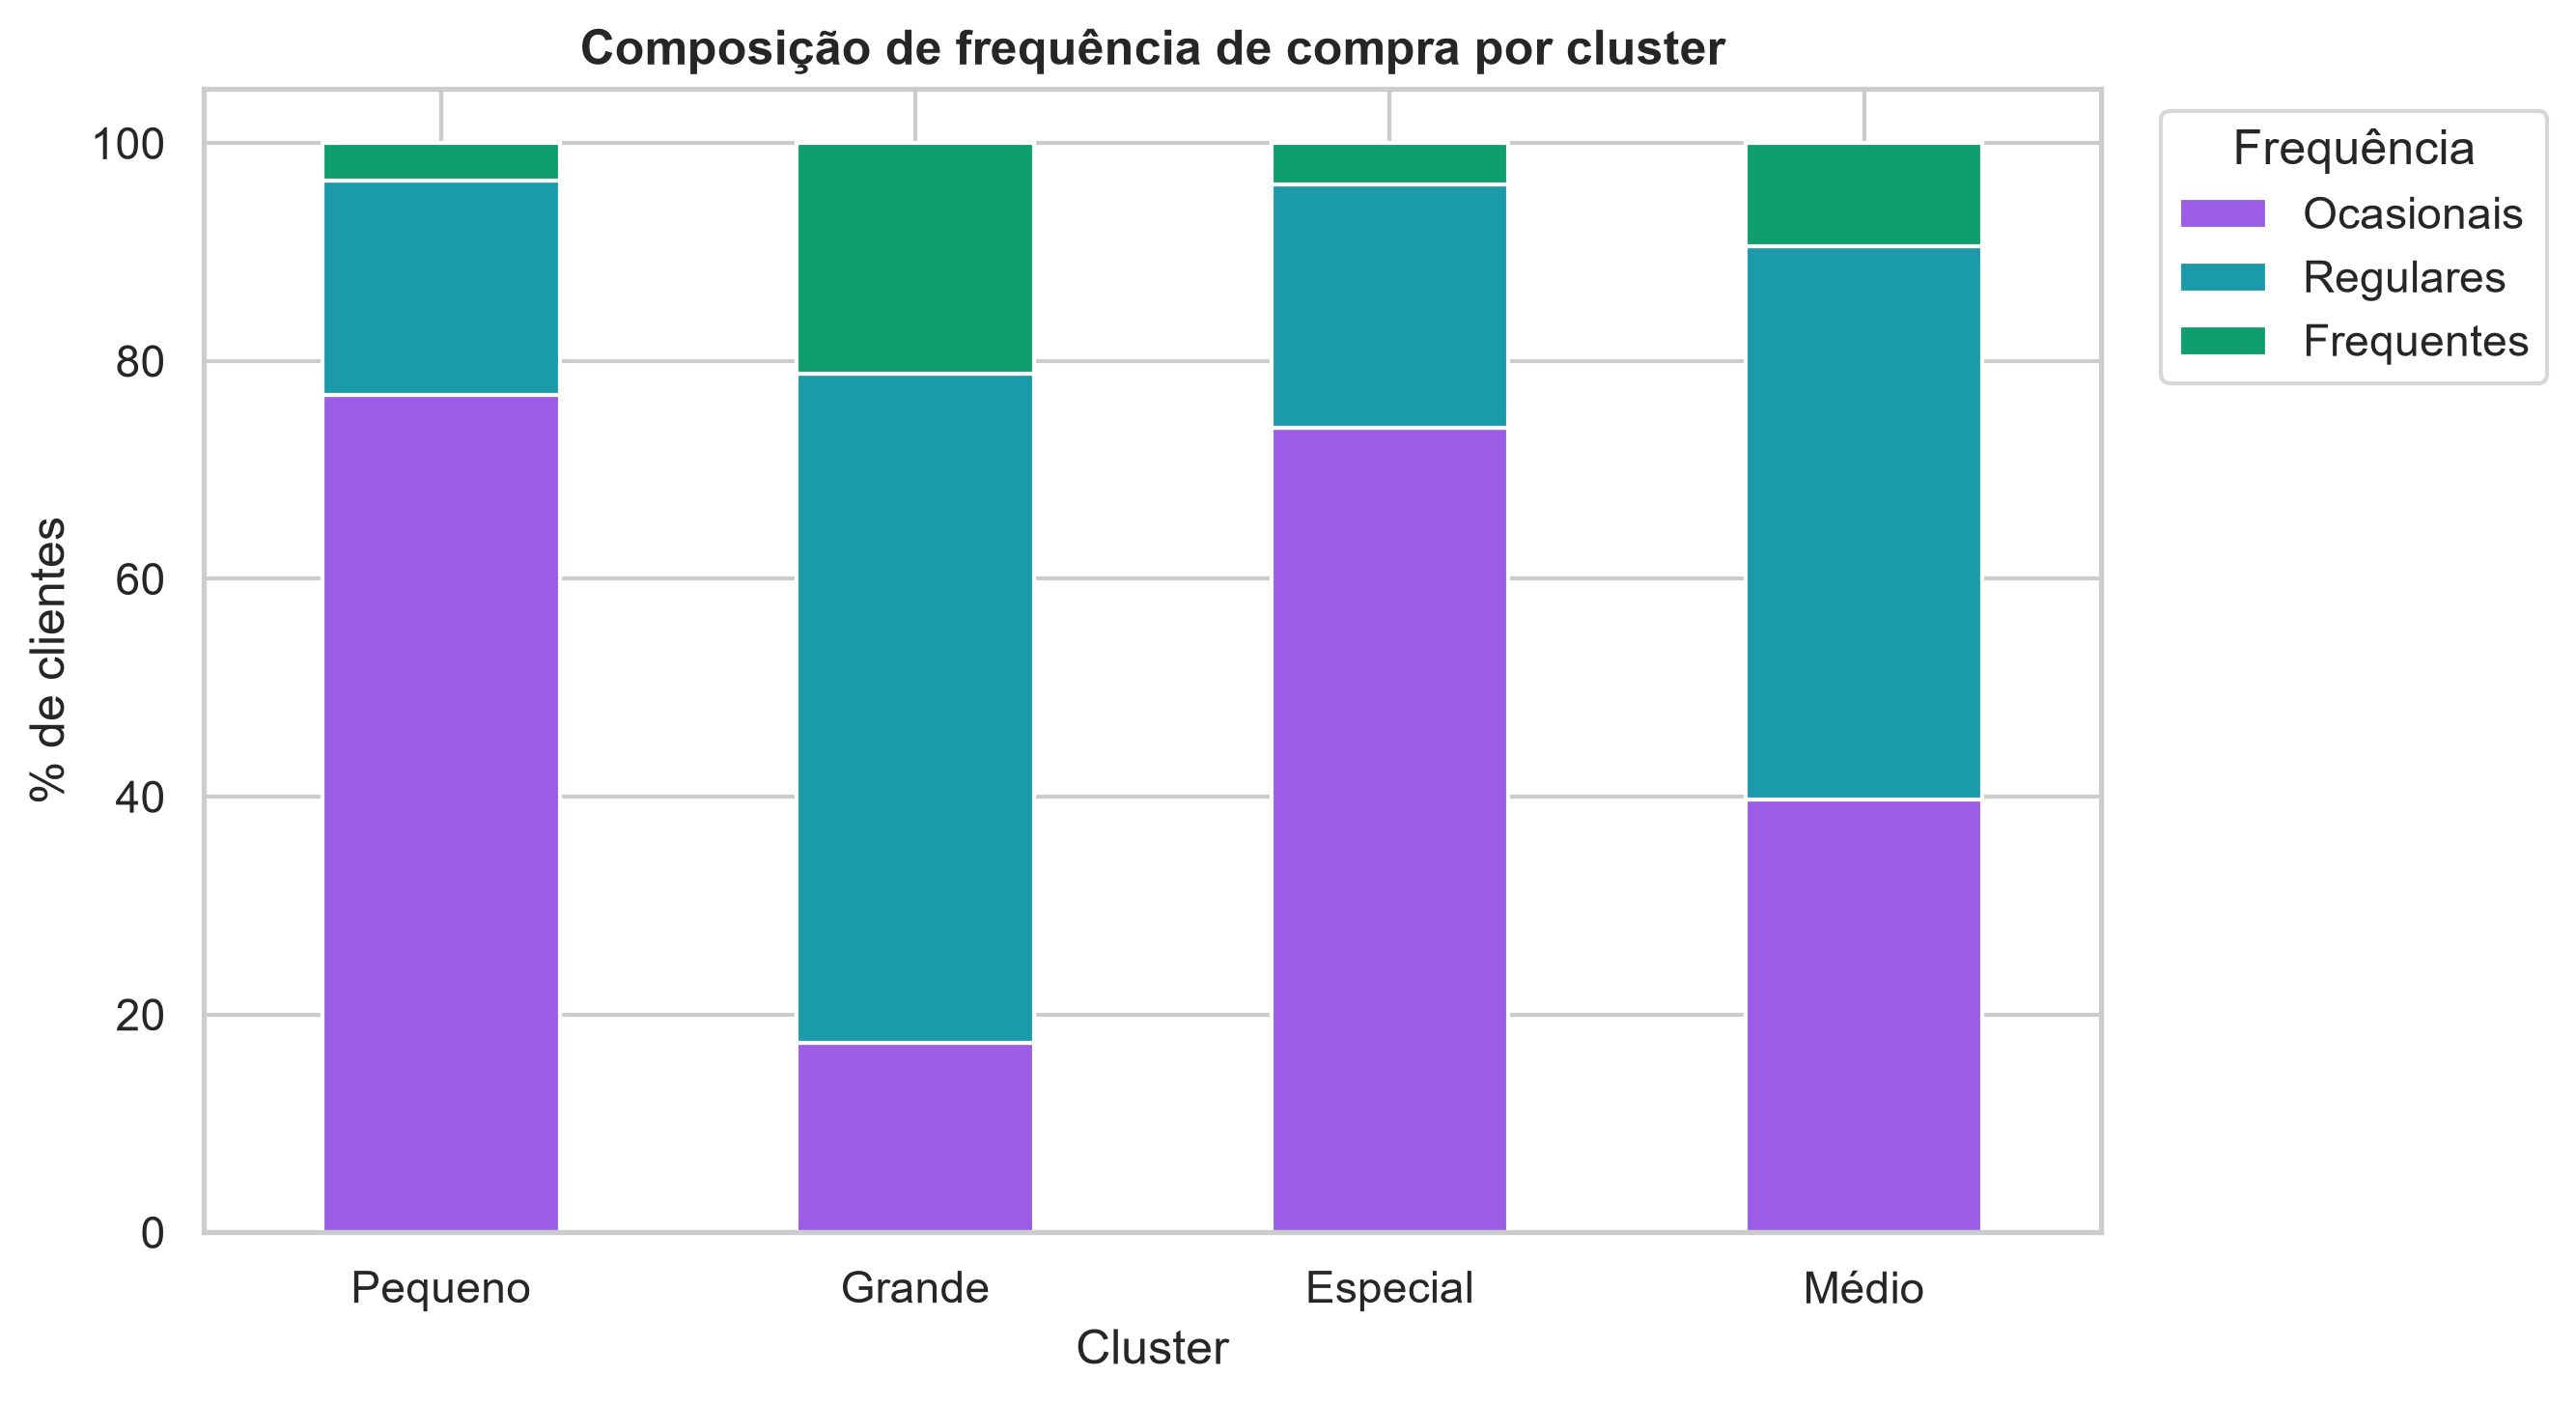

In [25]:
Image(filename=HIBRIDA / 'frequencia_por_cluster.png', width=950)


Segmentos (cluster × família): 40
Com menos de 10 clientes: 0


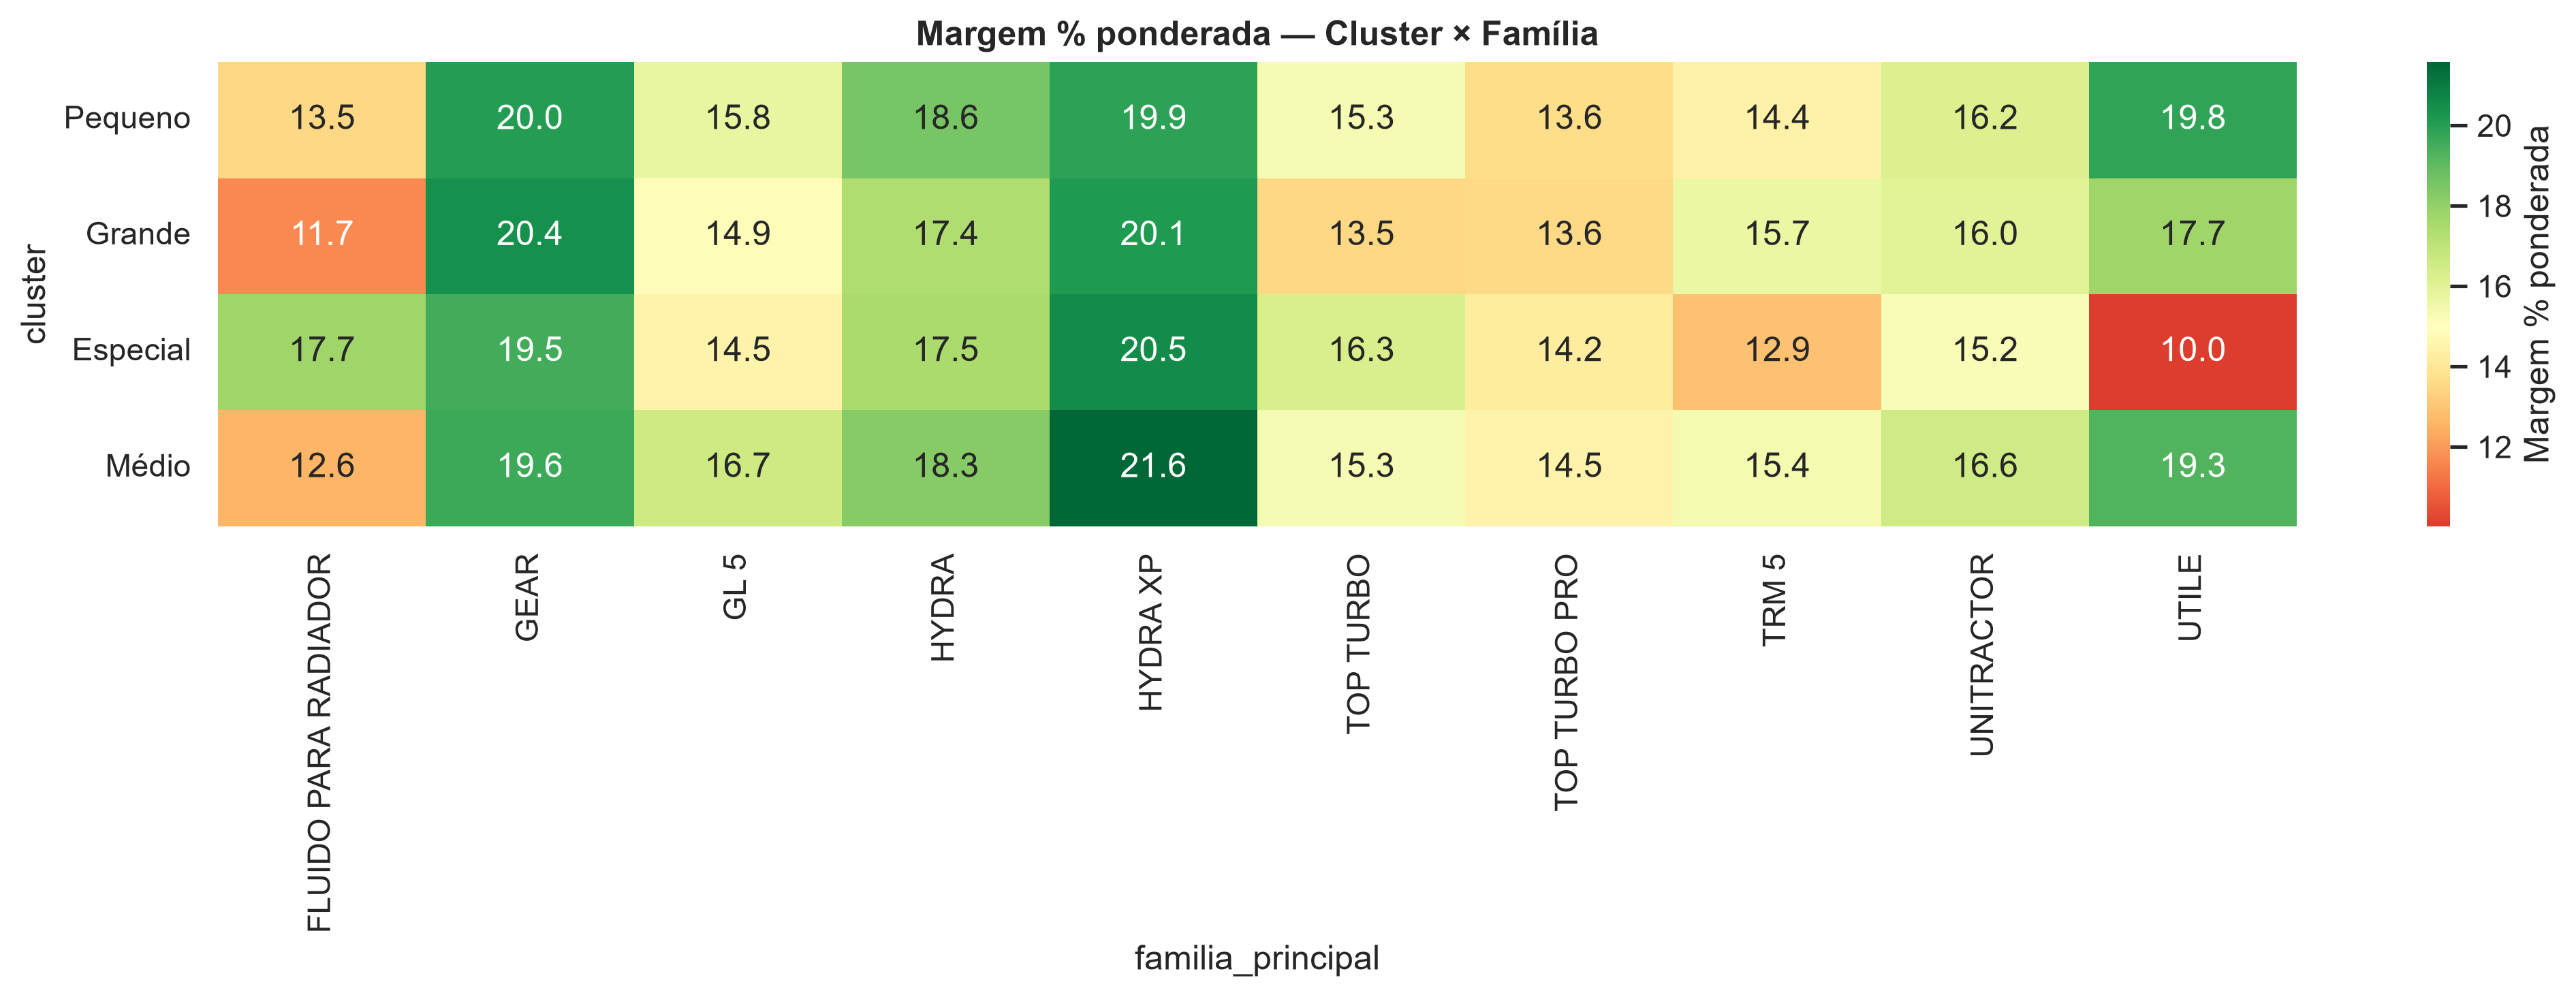

In [26]:
matriz = pd.read_csv(HIBRIDA / 'matriz_cluster_familia_consolidada.csv')
print(f"Segmentos (cluster × família): {len(matriz)}")
print(f"Com menos de 10 clientes: {(matriz['clientes_unicos'] < 10).sum() if 'celula_pequena' not in matriz else matriz['celula_pequena'].sum()}")
Image(filename=HIBRIDA / 'heatmap_margem_cluster_familia.png', width=950)


O heatmap abaixo mostra o preço ponderado (R$/m³) em cada combinação cluster × família — o
grupo Especial se destaca por pagar mais em praticamente **toda** família, não só num produto
específico.


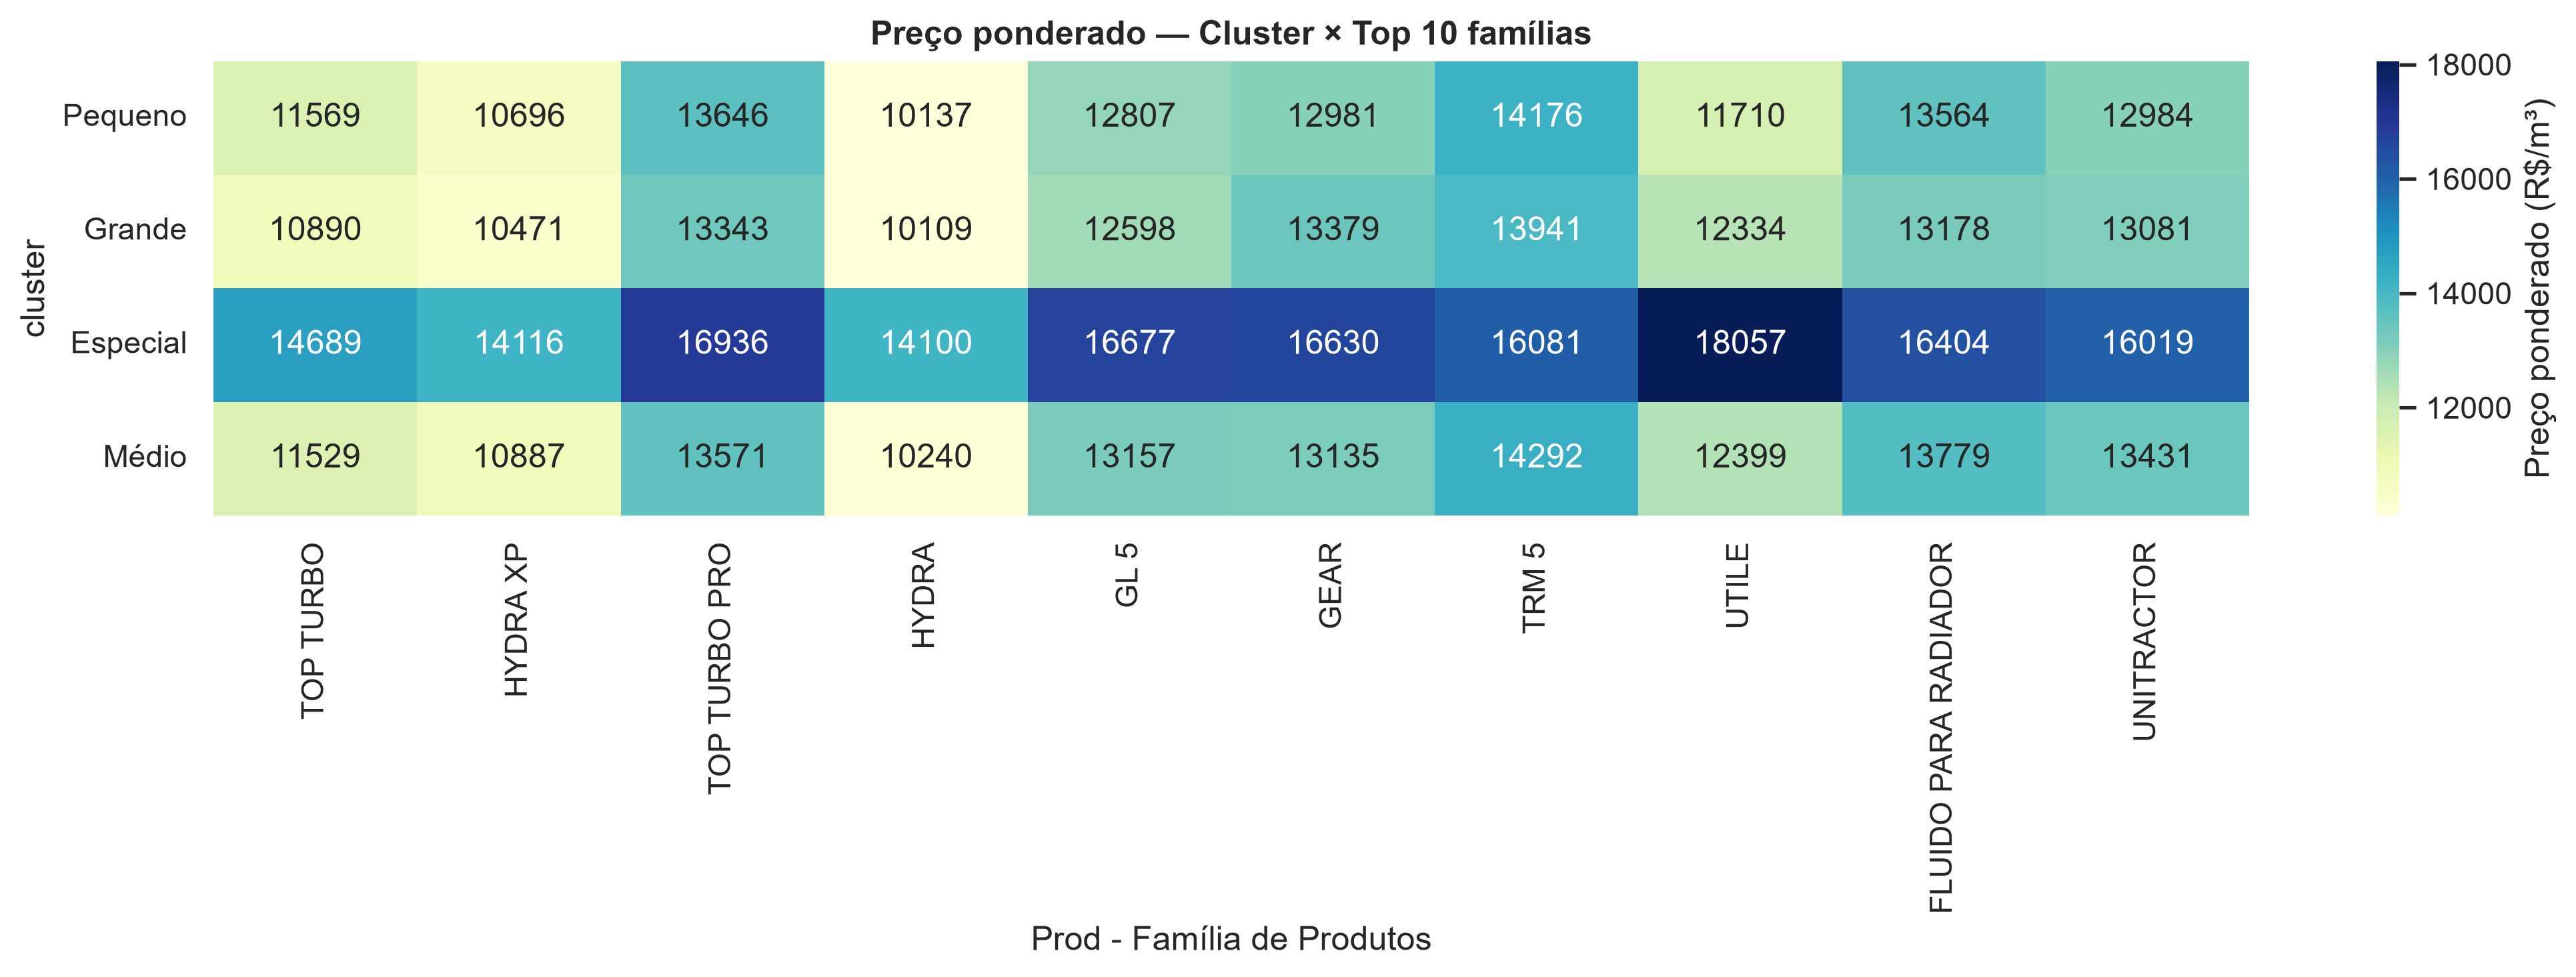

In [27]:
Image(filename=HIBRIDA / 'heatmap_preco_cluster_familia.png', width=950)


### Preço ponderado — top 10 específico do Especial

O heatmap acima usa o top 10 geral. Olhando o preço só nas famílias que o próprio Especial mais compra (incluindo as 4 exclusivas):


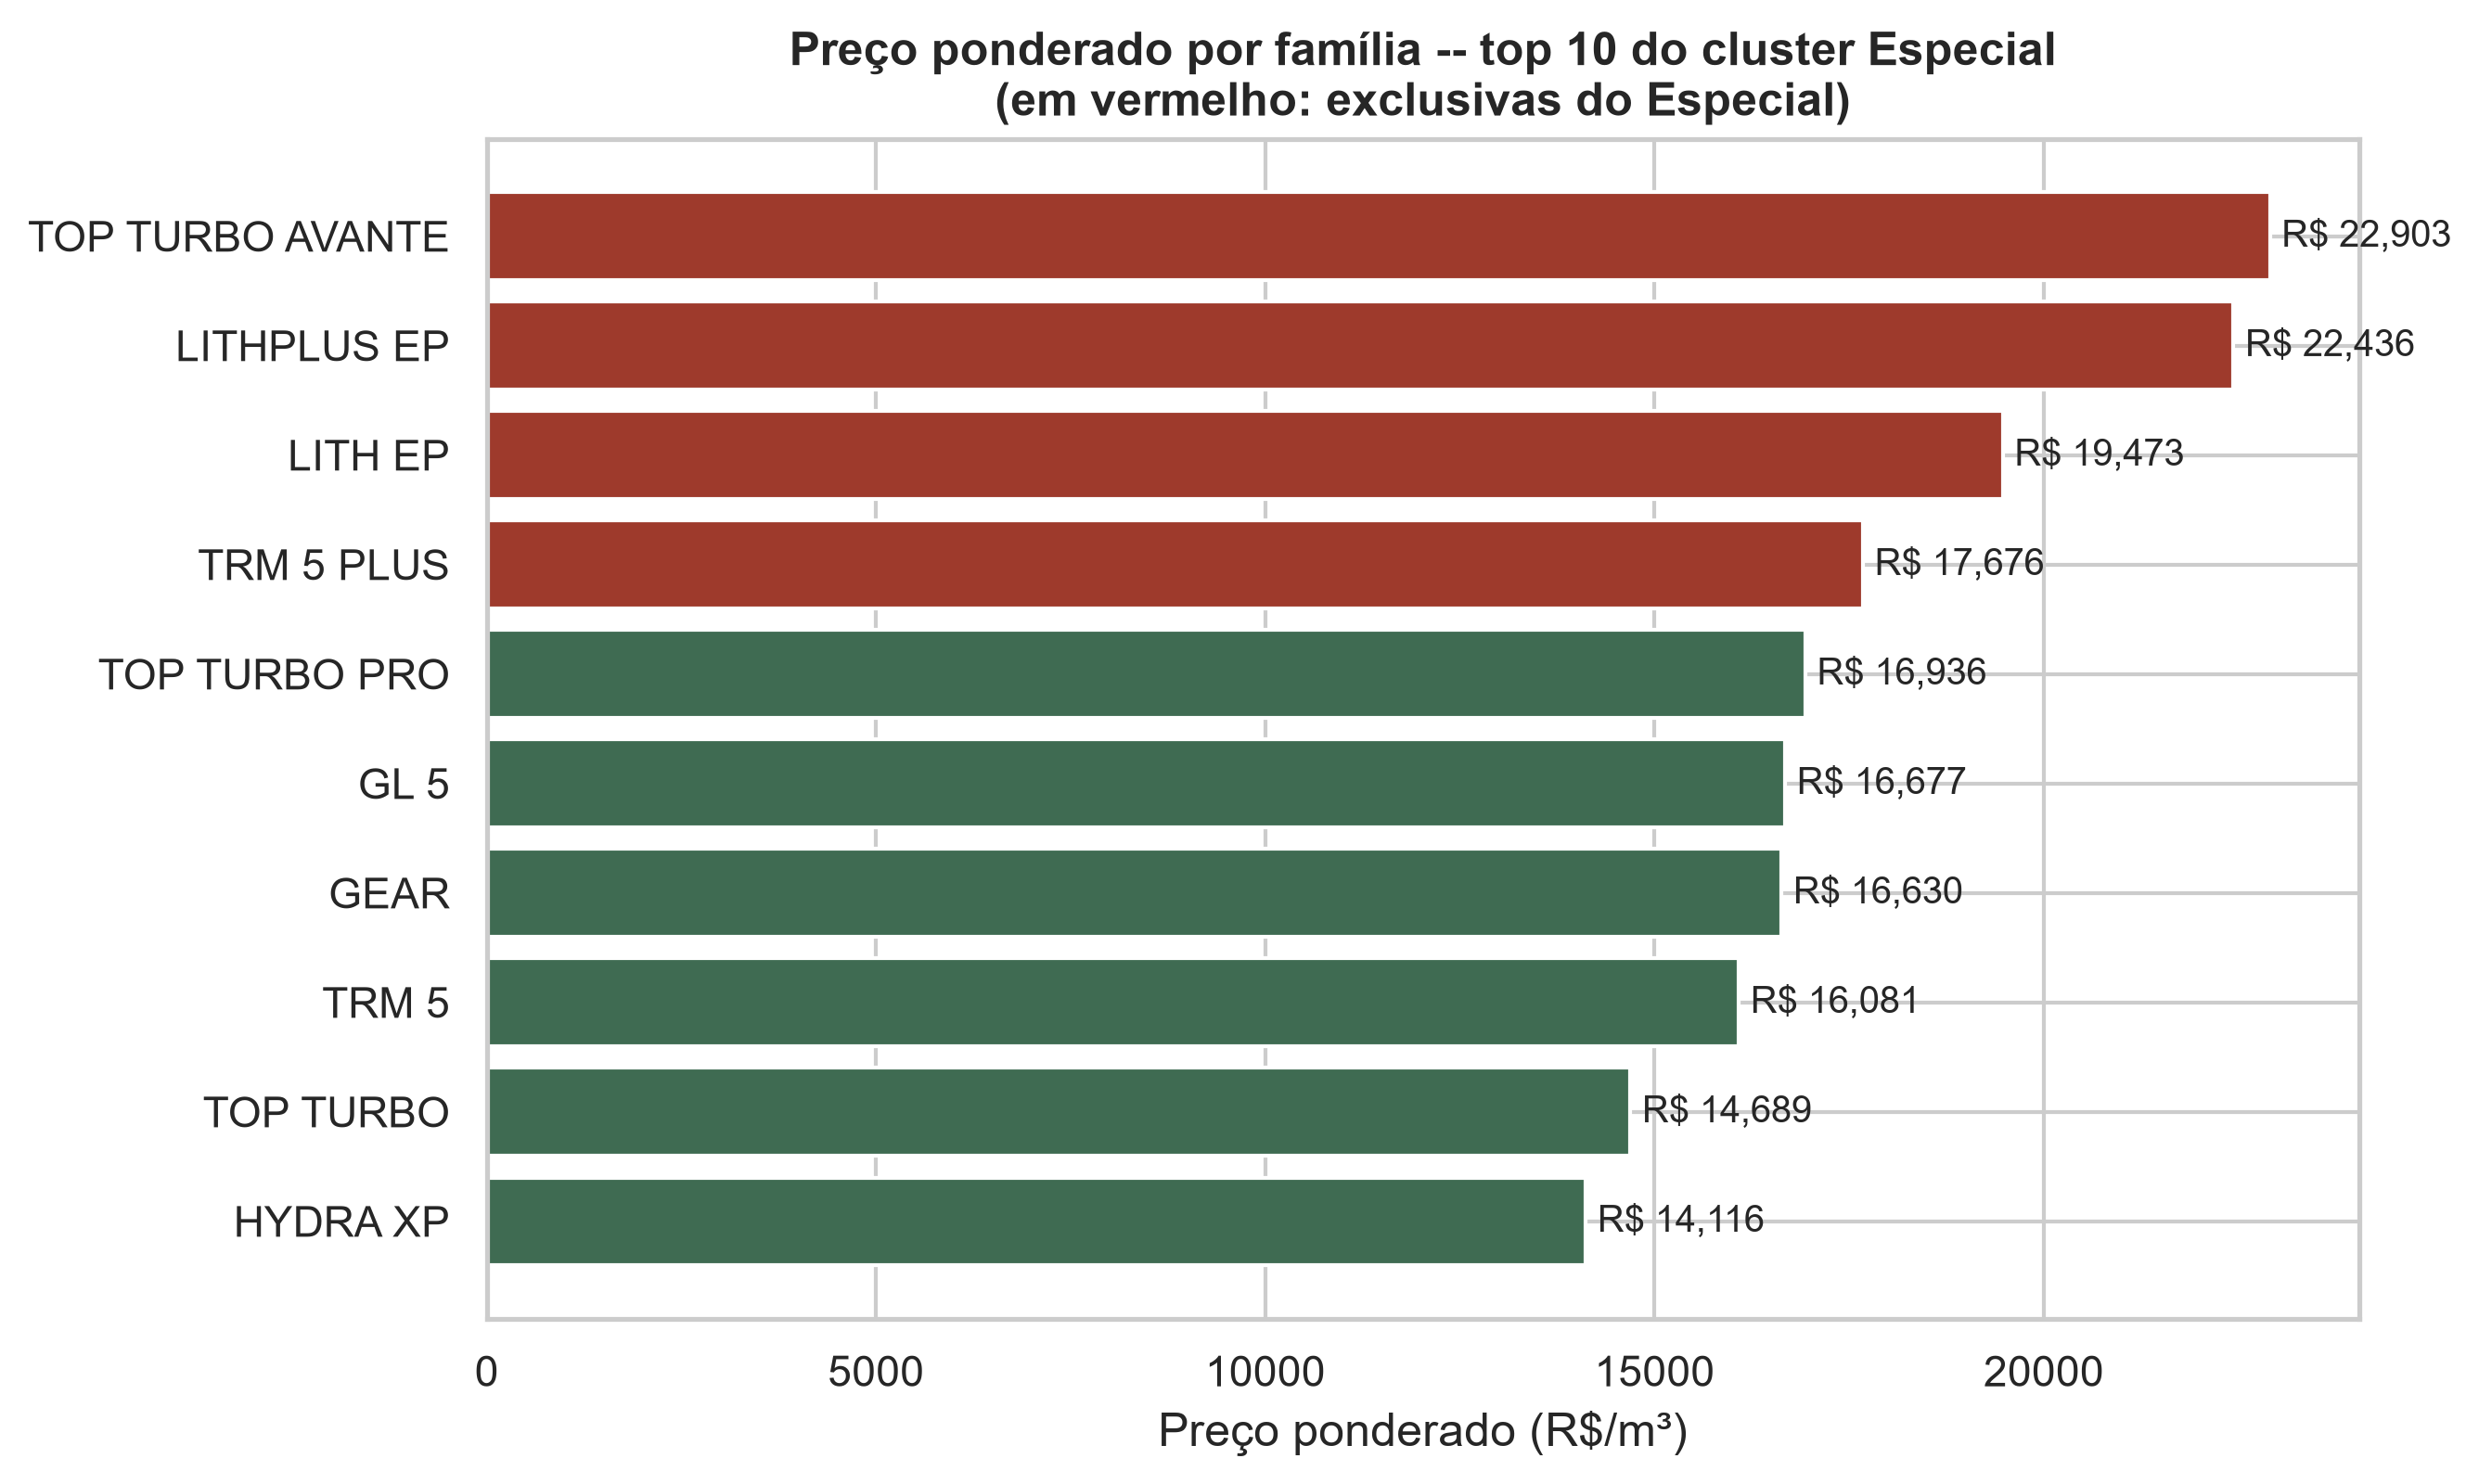

In [28]:
Image(filename=HIBRIDA / 'preco_top10_familias_especial.png', width=900)


**Achado:** as 2 famílias exclusivas do Especial com maior volume são também as mais caras de toda a lista — **TOP TURBO AVANTE** (R$ 22.903/m³) e **LITHPLUS EP** (R$ 22.436/m³), acima até do pico visto no top 10 geral (R$ 18.057/m³ em UTILE). O mix específico do Especial não é só diferente — é mais caro ainda.


### Preço por UF — top 10 específico do Especial

O achado de UF (seção 6, Mato Grosso/MS sobrerrepresentados e pagando mais frete) foi visto no agregado do cluster. Abrindo por produto: células com menos de 10 clientes ficam em branco (amostra pequena demais).


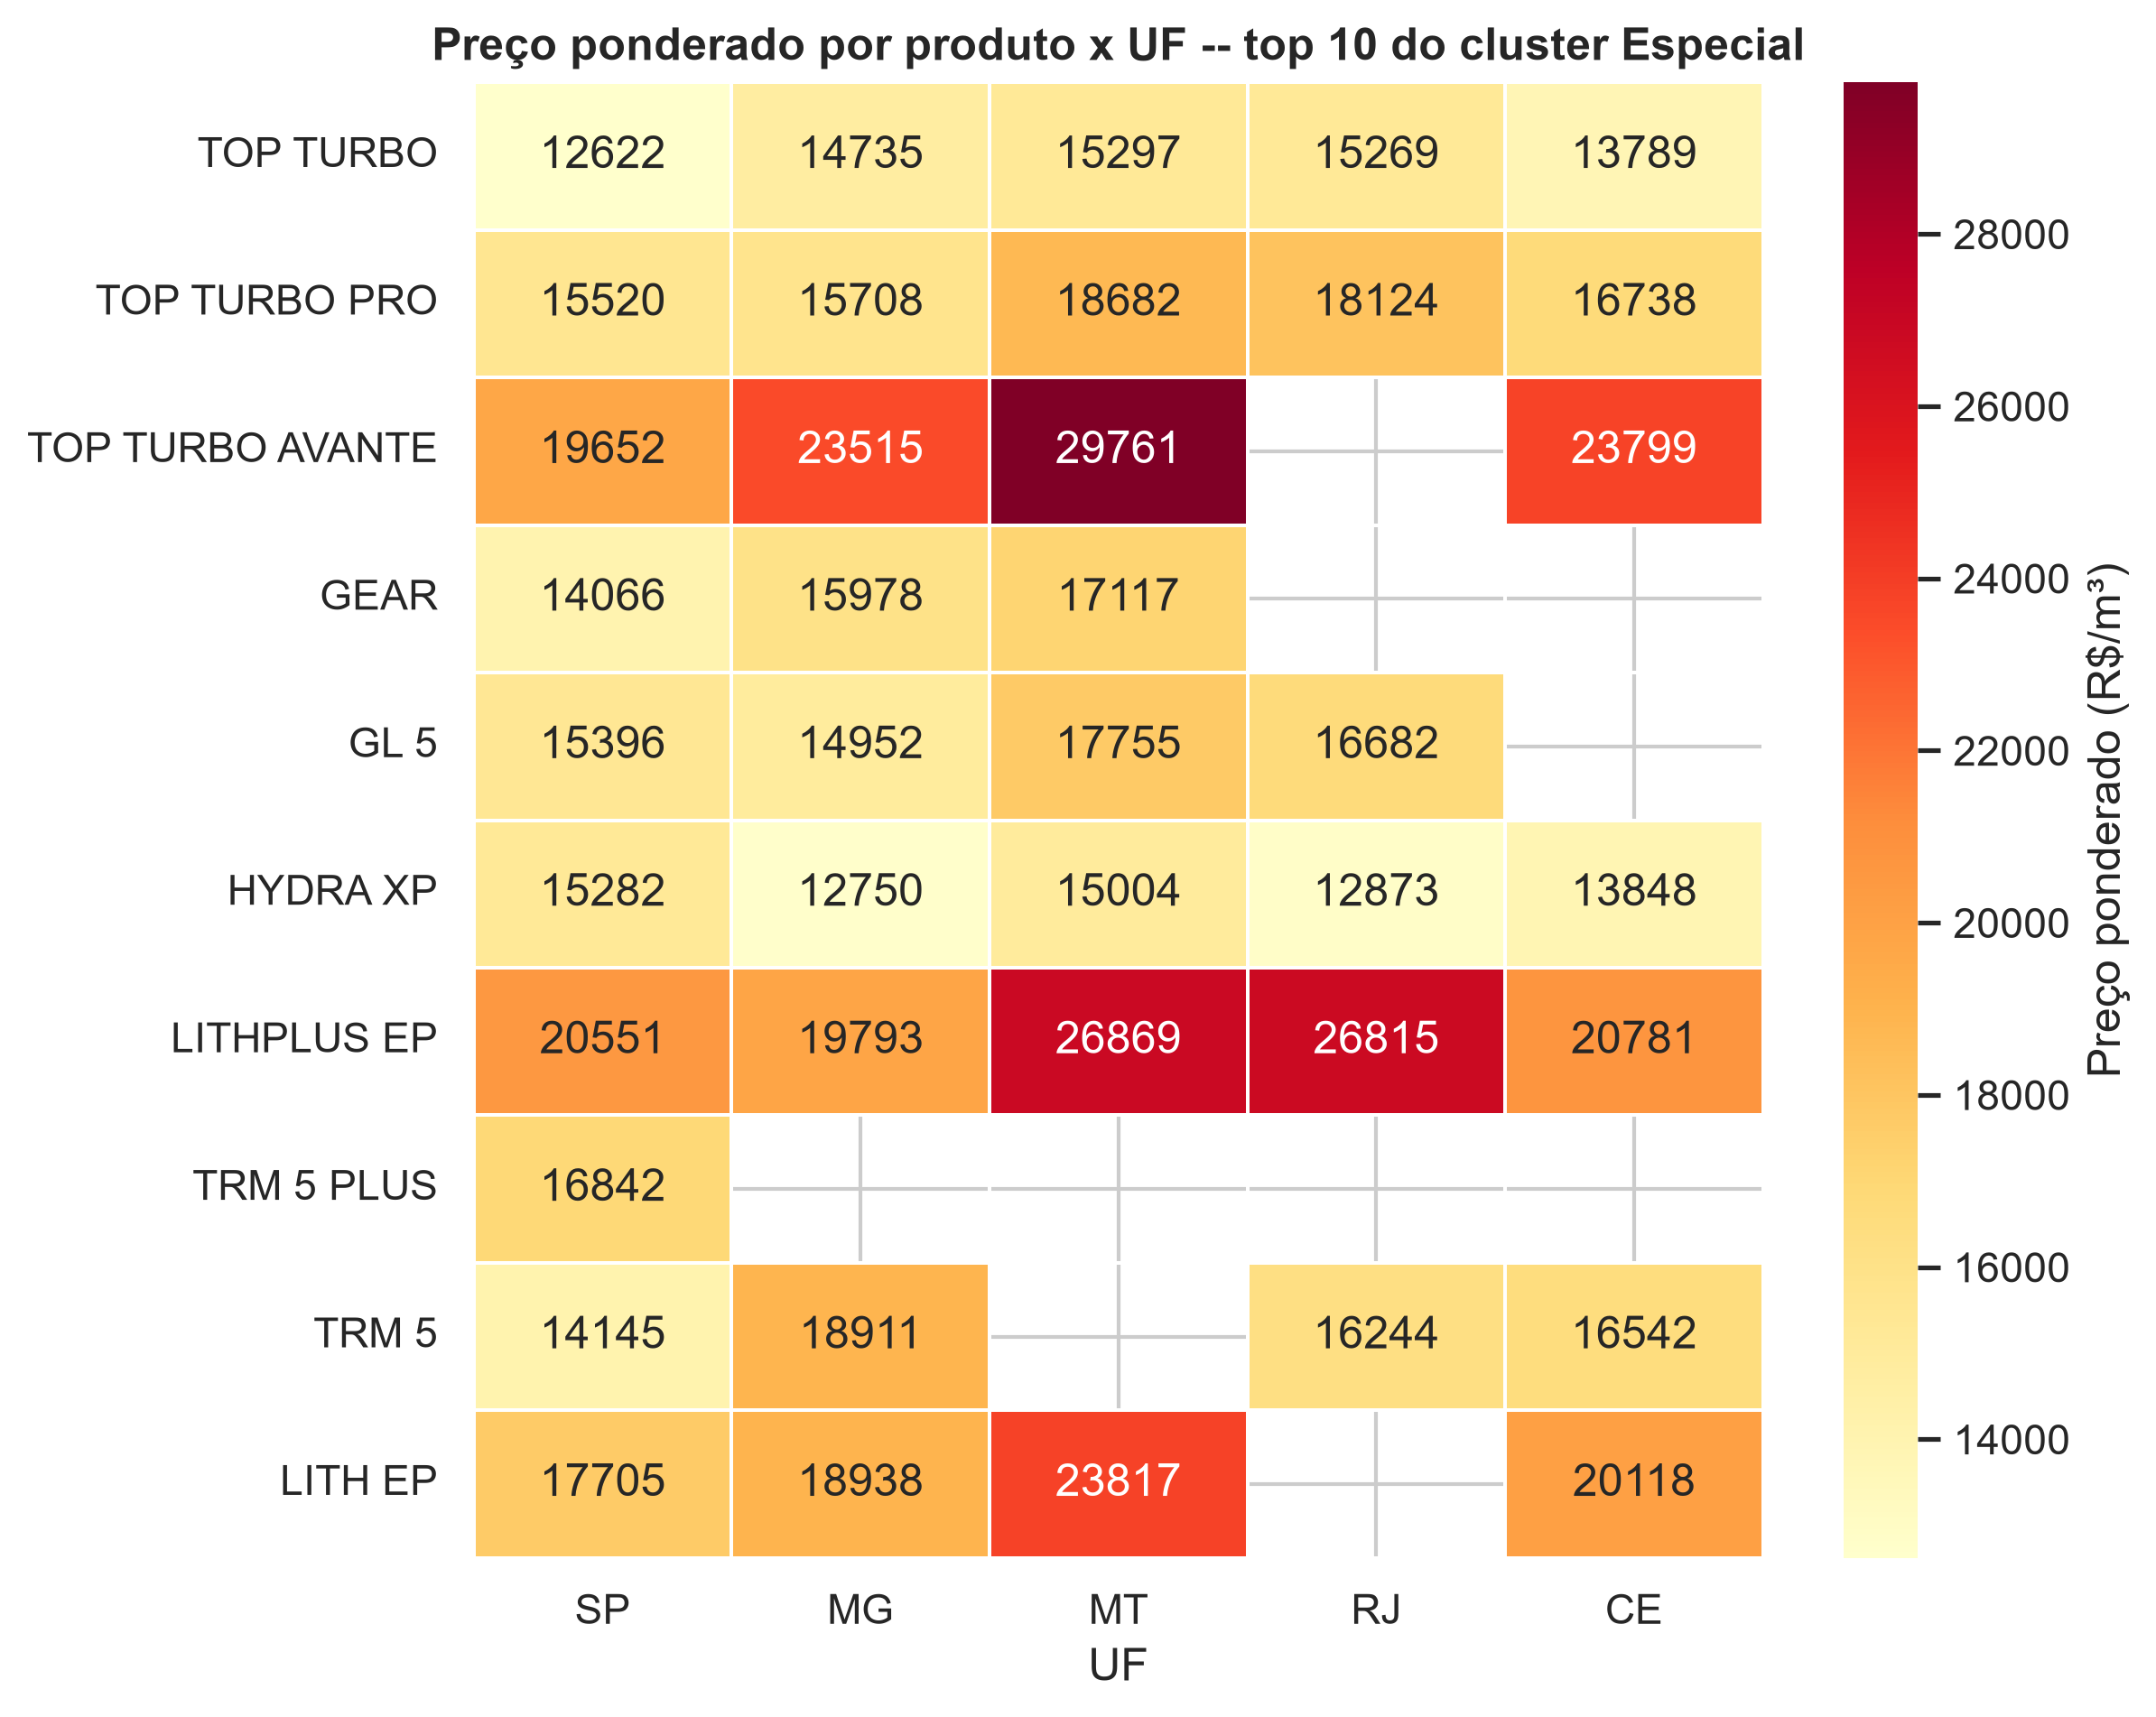

In [29]:
Image(filename=HIBRIDA / 'preco_uf_top10_especial.png', width=900)


**Achado:** Mato Grosso é a UF mais cara em praticamente todo produto do top 10 do Especial onde há amostra suficiente — chegando a **R$ 29.761/m³ em TOP TURBO AVANTE** e **R$ 26.869/m³ em LITHPLUS EP**, bem acima do que se paga nas mesmas famílias em São Paulo ou Minas Gerais. O achado de frete/UF não é só um efeito de composição de cluster — ele aparece produto a produto.


### Preço por UF — comparando os 4 clusters

O mesmo recorte, agora para os 4 clusters lado a lado, usando o top 10 *geral* e a mesma escala de cor em todos os painéis.


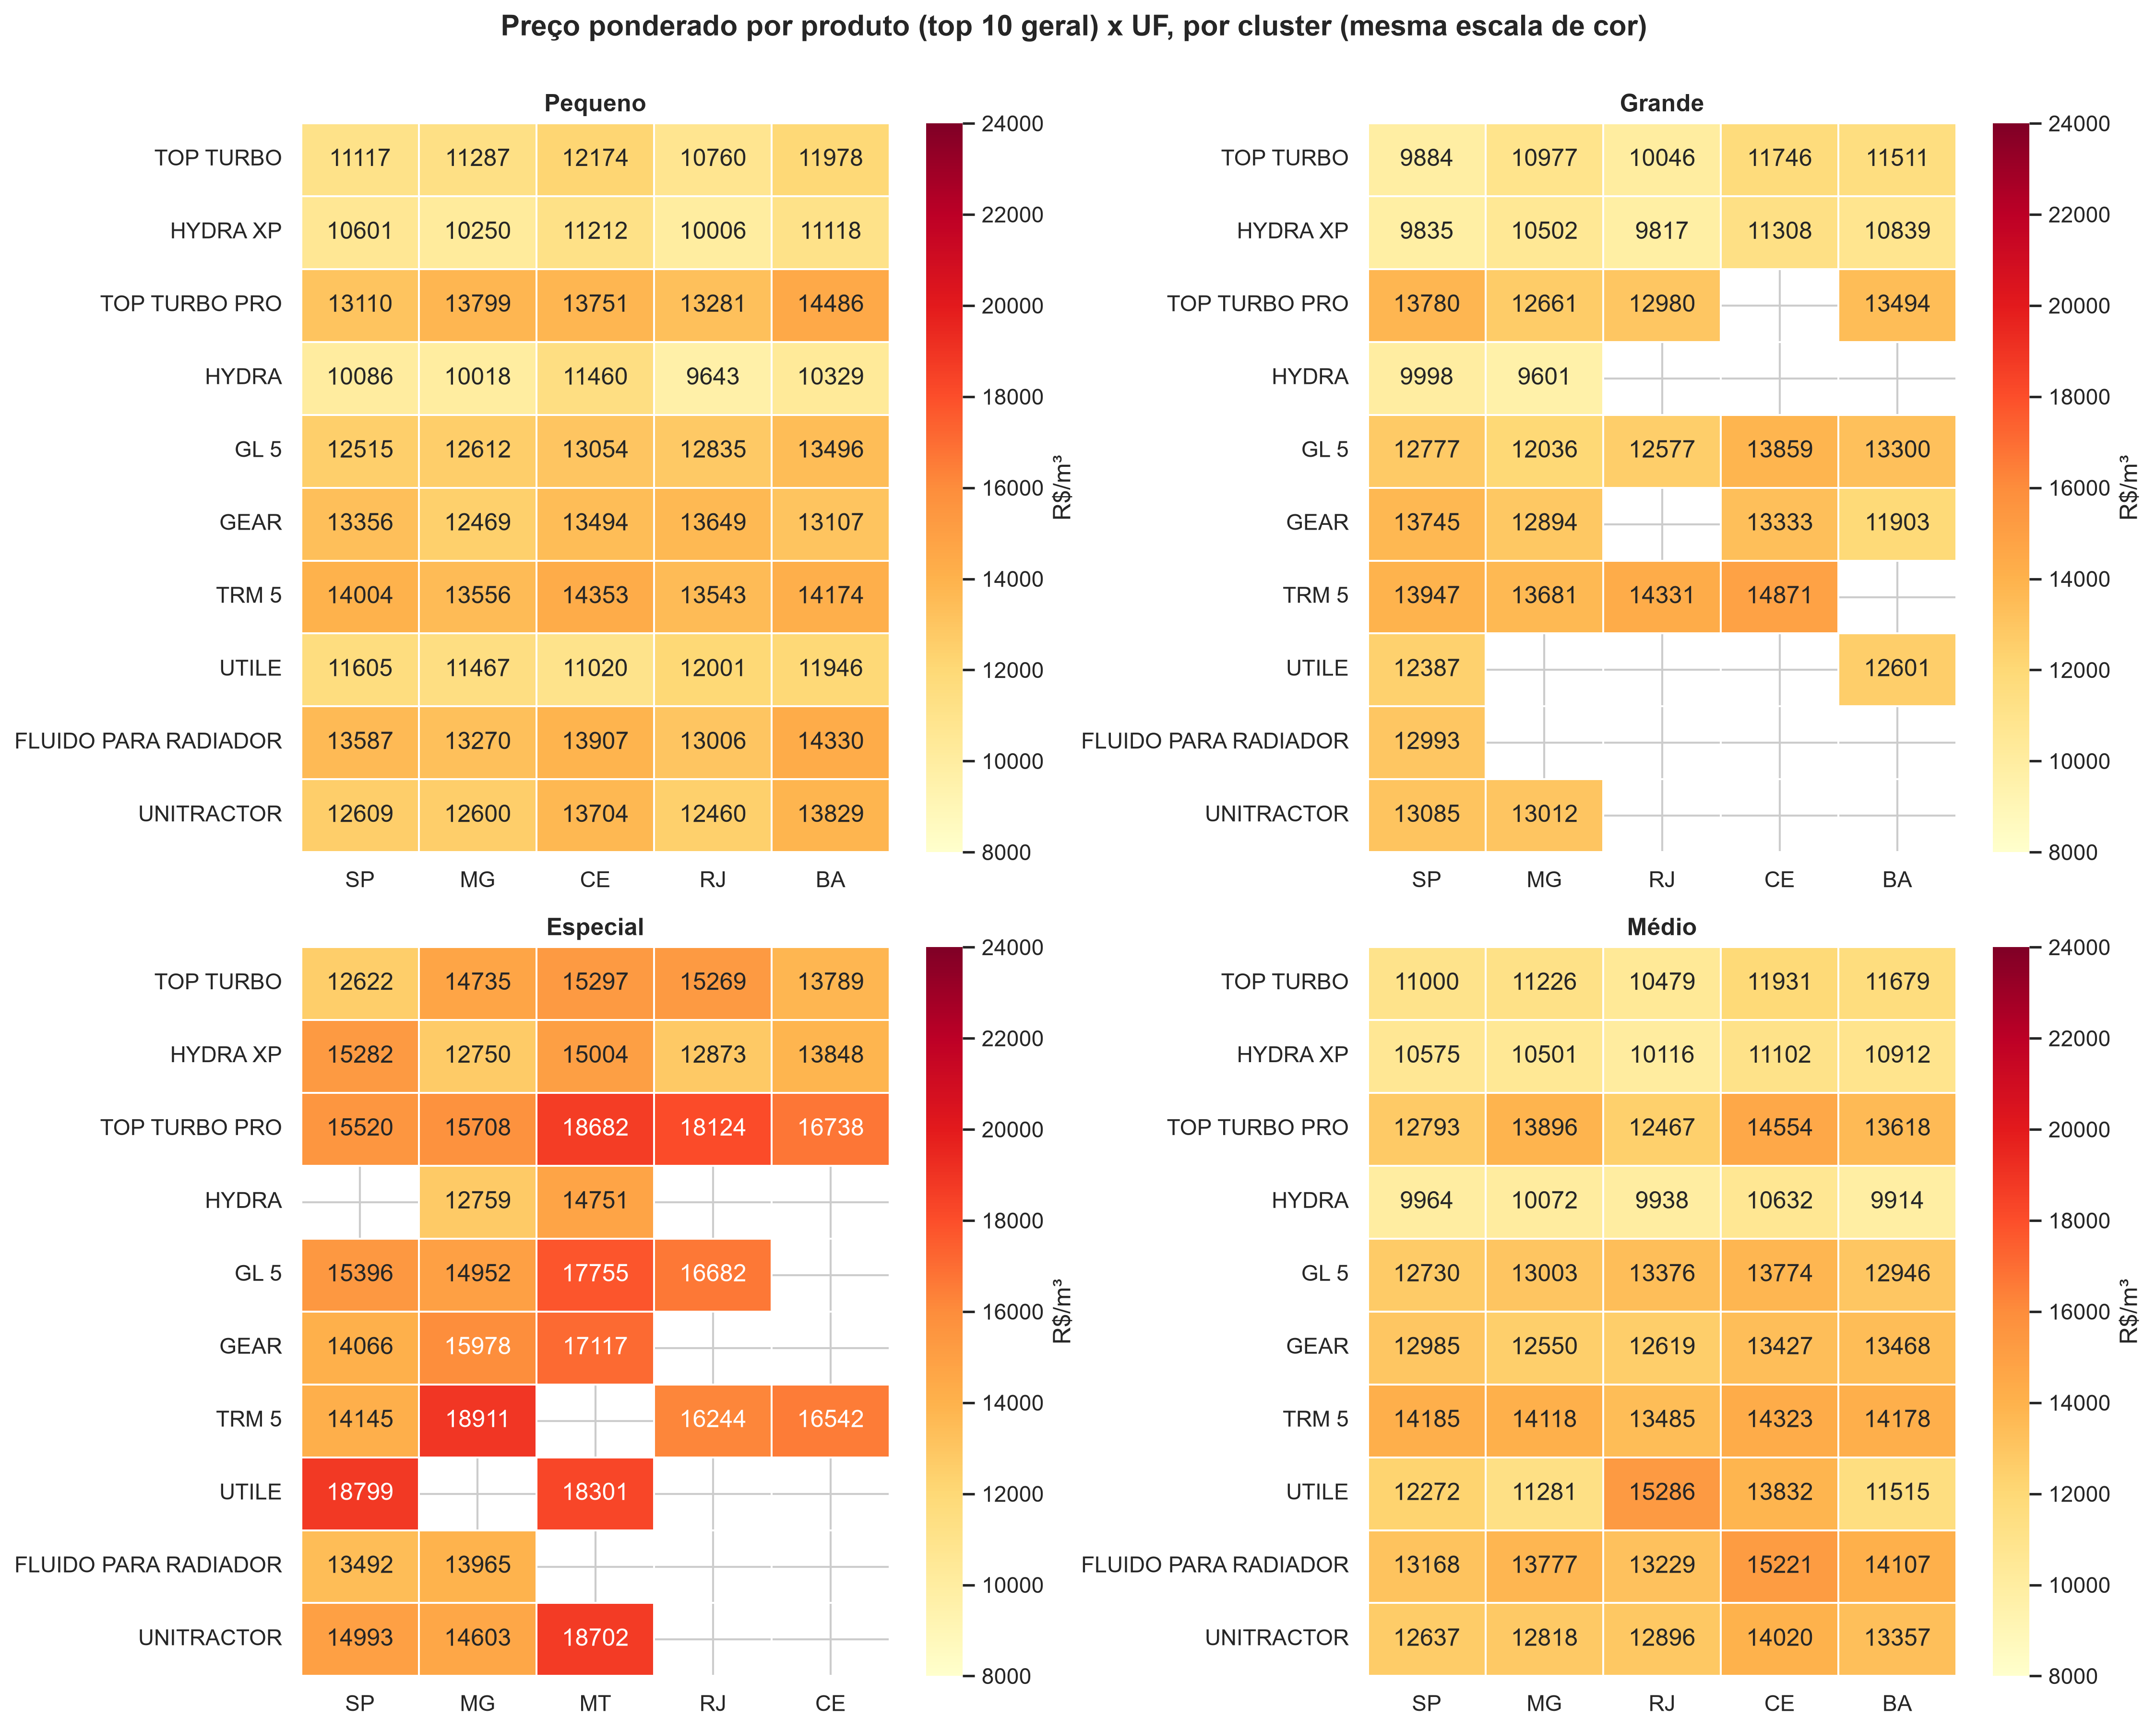

In [30]:
Image(filename=HIBRIDA / 'preco_uf_4clusters.png', width=1000)


**Achado:** na mesma escala de cor, o painel do Especial é visivelmente mais escuro (mais caro) que Pequeno, Grande e Médio em praticamente toda combinação produto × UF — não é um efeito de uma UF ou produto isolado, é o cluster inteiro que paga mais, em qualquer corte que se olhe.


### Maiores segmentos de CNAE por receita

As visões acima são por **contagem de clientes** — um CNAE pode ter poucos clientes mas
concentrar muita receita. Olhando por receita, cluster a cluster:


In [31]:
receita_cnae_cluster = seg.groupby(['cluster', 'cnae_divisao_nome'])['receita_liquida_total'].sum()

for c in sorted(seg['cluster'].unique()):
    sub = receita_cnae_cluster.loc[c].sort_values(ascending=False)
    receita_total_cluster = sub.sum()
    top5 = sub.head(5)
    print(f"Cluster {c} — receita total: R$ {receita_total_cluster:,.0f}")
    for cnae, receita in top5.items():
        print(f"  {cnae[:55]:55s} R$ {receita:>14,.0f}  ({receita / receita_total_cluster * 100:5.1f}%)")
    print()


Cluster 0 — receita total: R$ 198,131,213
  Transporte terrestre                                    R$     77,611,944  ( 39.2%)
  Obras de infraestrutura                                 R$     12,106,233  (  6.1%)
  Aluguel de máquinas e equipamentos                      R$     10,200,418  (  5.1%)
  Extração de minerais não-metálicos                      R$      9,217,502  (  4.7%)
  Produtos de minerais não-metálicos                      R$      8,850,961  (  4.5%)

Cluster 1 — receita total: R$ 288,274,480
  Transporte terrestre                                    R$    120,227,508  ( 41.7%)
  Extração de minerais não-metálicos                      R$     22,251,204  (  7.7%)
  Obras de infraestrutura                                 R$     16,209,702  (  5.6%)
  Produtos de minerais não-metálicos                      R$     13,833,095  (  4.8%)
  Serviços especializados para construção                 R$     12,820,134  (  4.4%)

Cluster 2 — receita total: R$ 52,407,731
  Transporte 

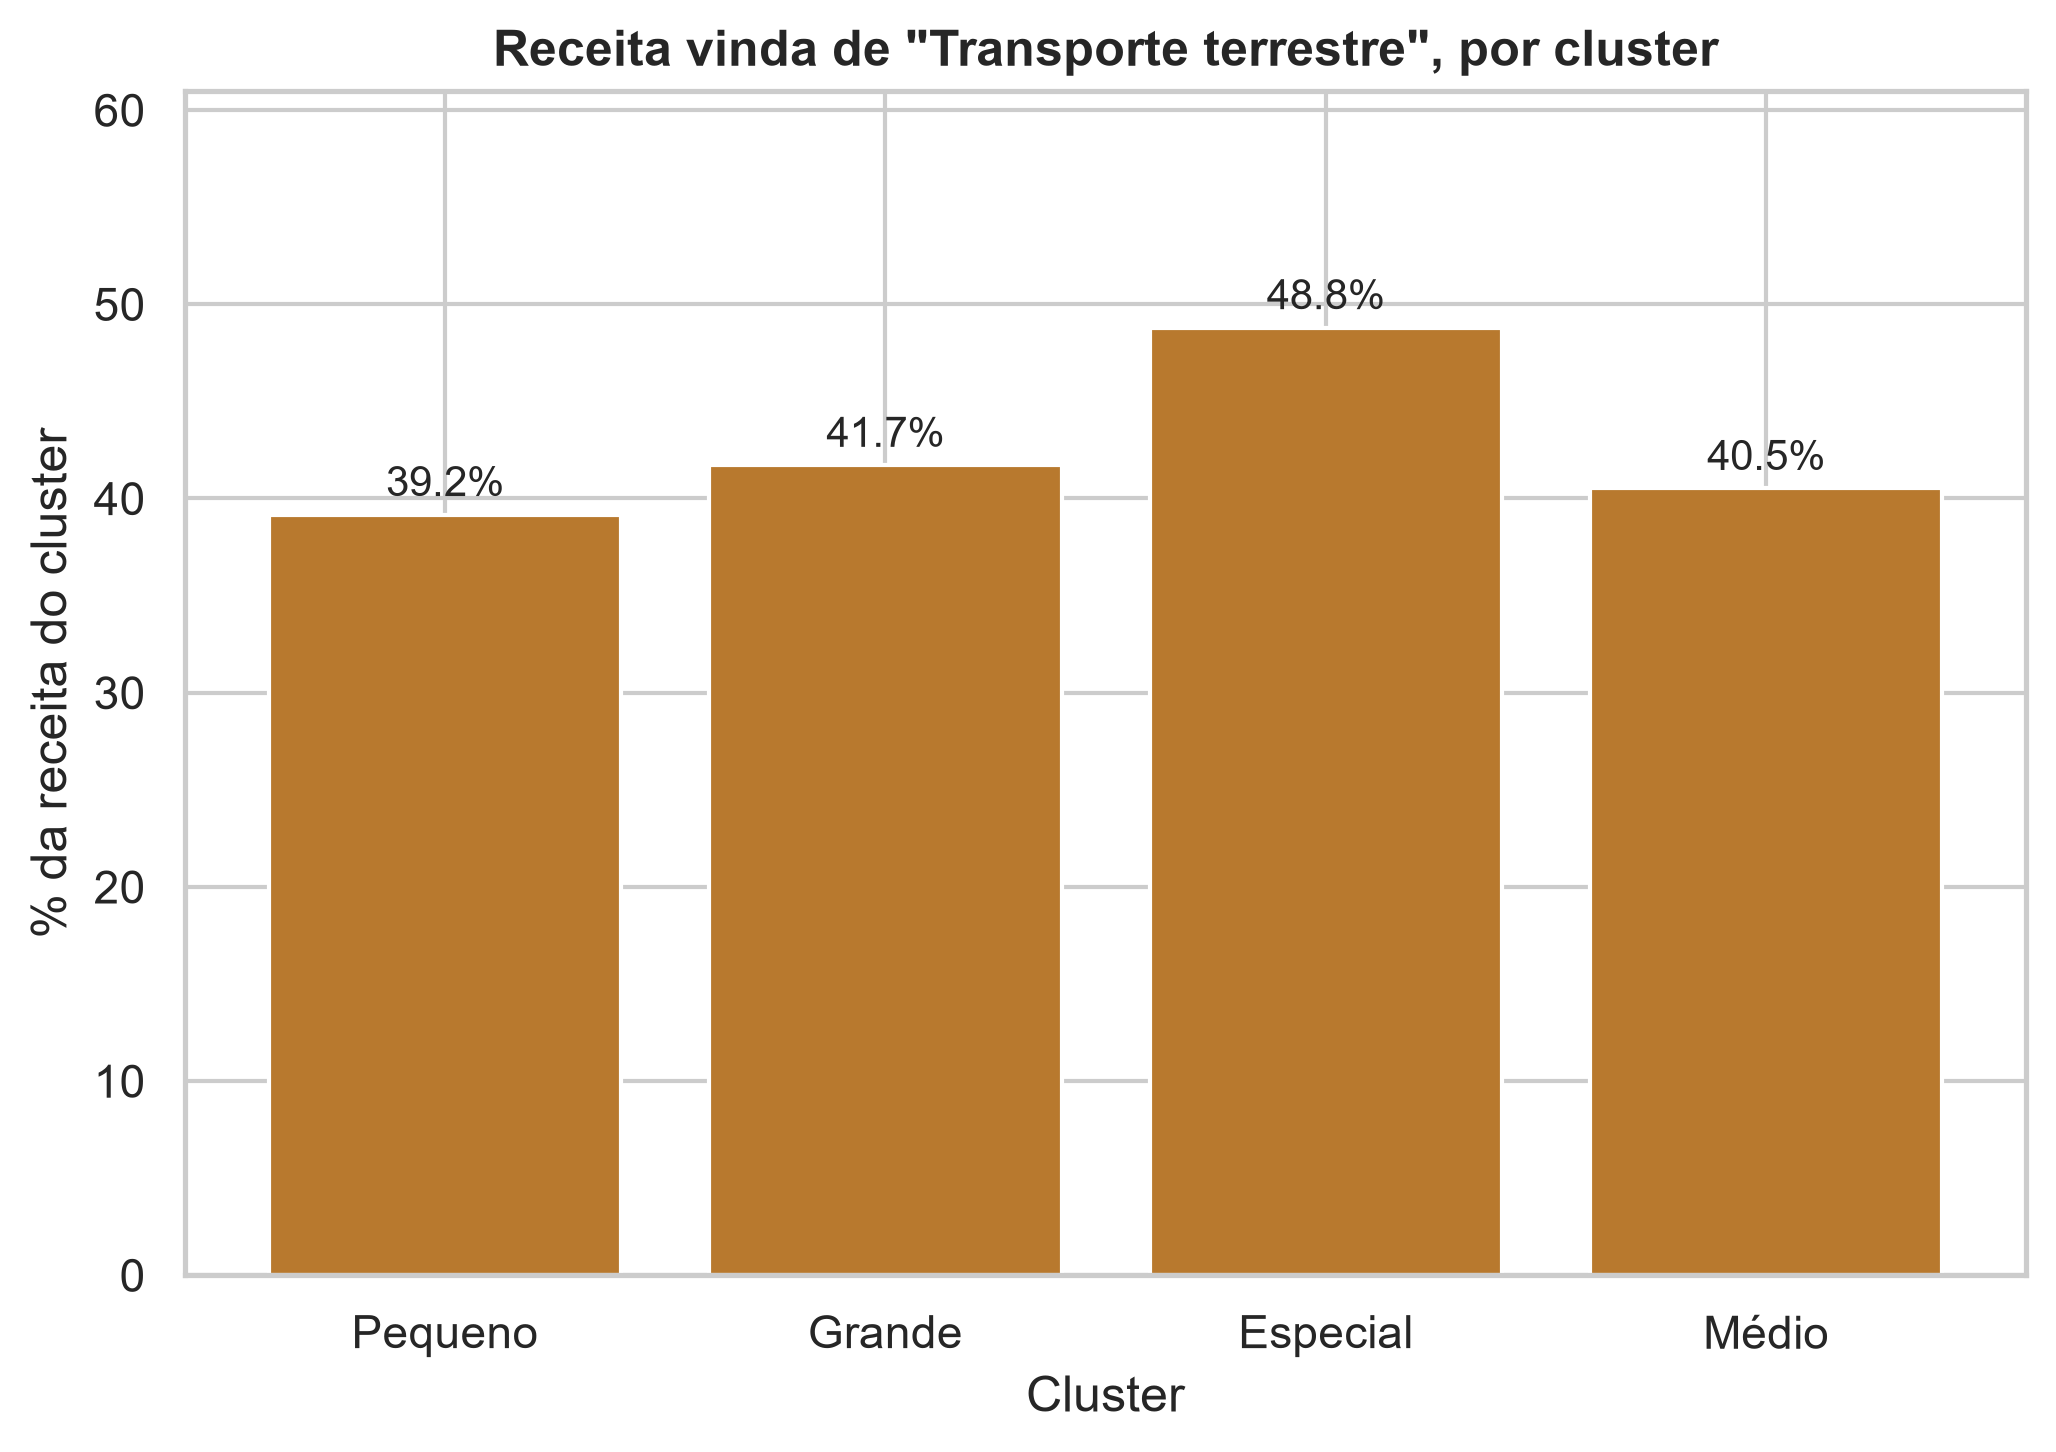

In [32]:
Image(filename=HIBRIDA / 'receita_transporte_por_cluster.png', width=550)


## UF do cliente por cluster — o Especial está concentrado nalguma região?

O grupo Especial paga mais por m³ em praticamente toda família (seção 6). Antes de assumir que é um problema de política comercial, vale checar se é geografia — frete mais caro pra determinadas UFs explicaria parte do preço mais alto.


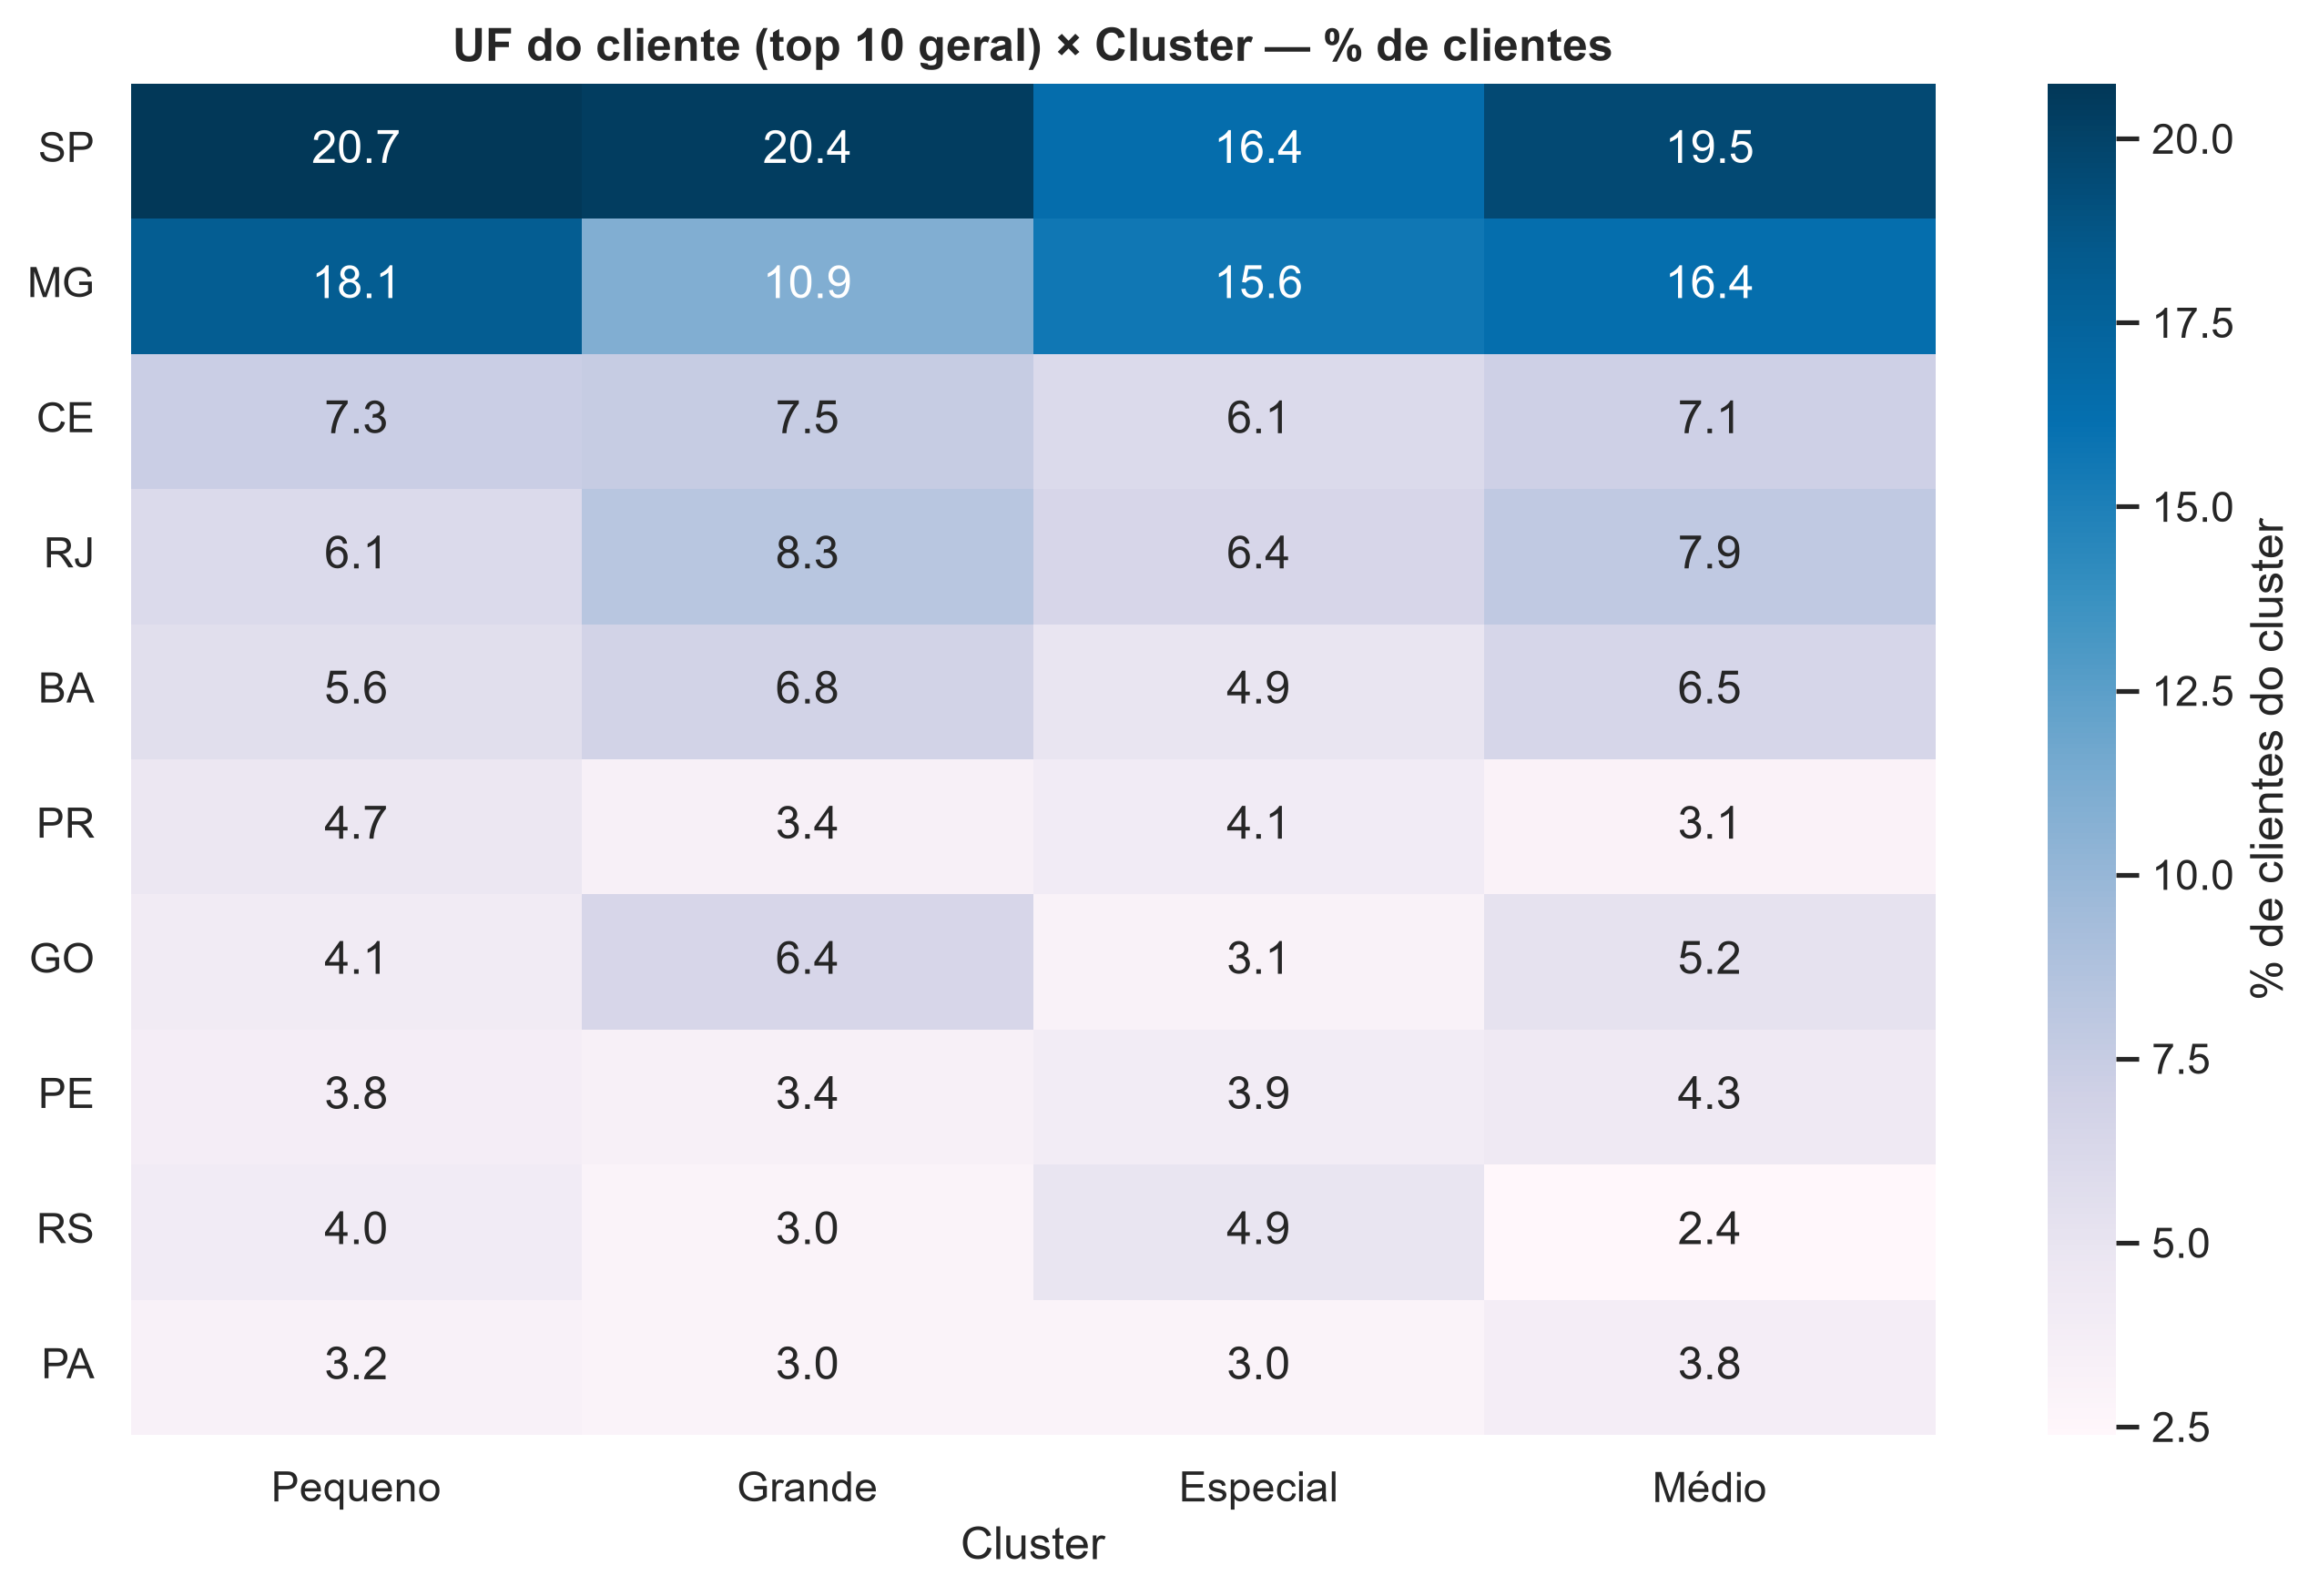

In [33]:
Image(filename=HIBRIDA / 'uf_por_cluster.png', width=800)


**Achado:** duas UFs do Centro-Oeste aparecem bem acima da sua participação na base toda —
**Mato Grosso: 11,2% do Especial vs. 2,6% da base (4,4x mais representado)** e Mato Grosso do
Sul: 4,4% vs. 1,6% (2,7x). Ambos são estados distantes das refinarias/centros de distribuição
do litoral — consistente com a hipótese de que parte do preço mais alto do Especial é frete,
não só política comercial. Vale confirmar com o time de logística antes de qualquer ação de
preço nesse grupo.


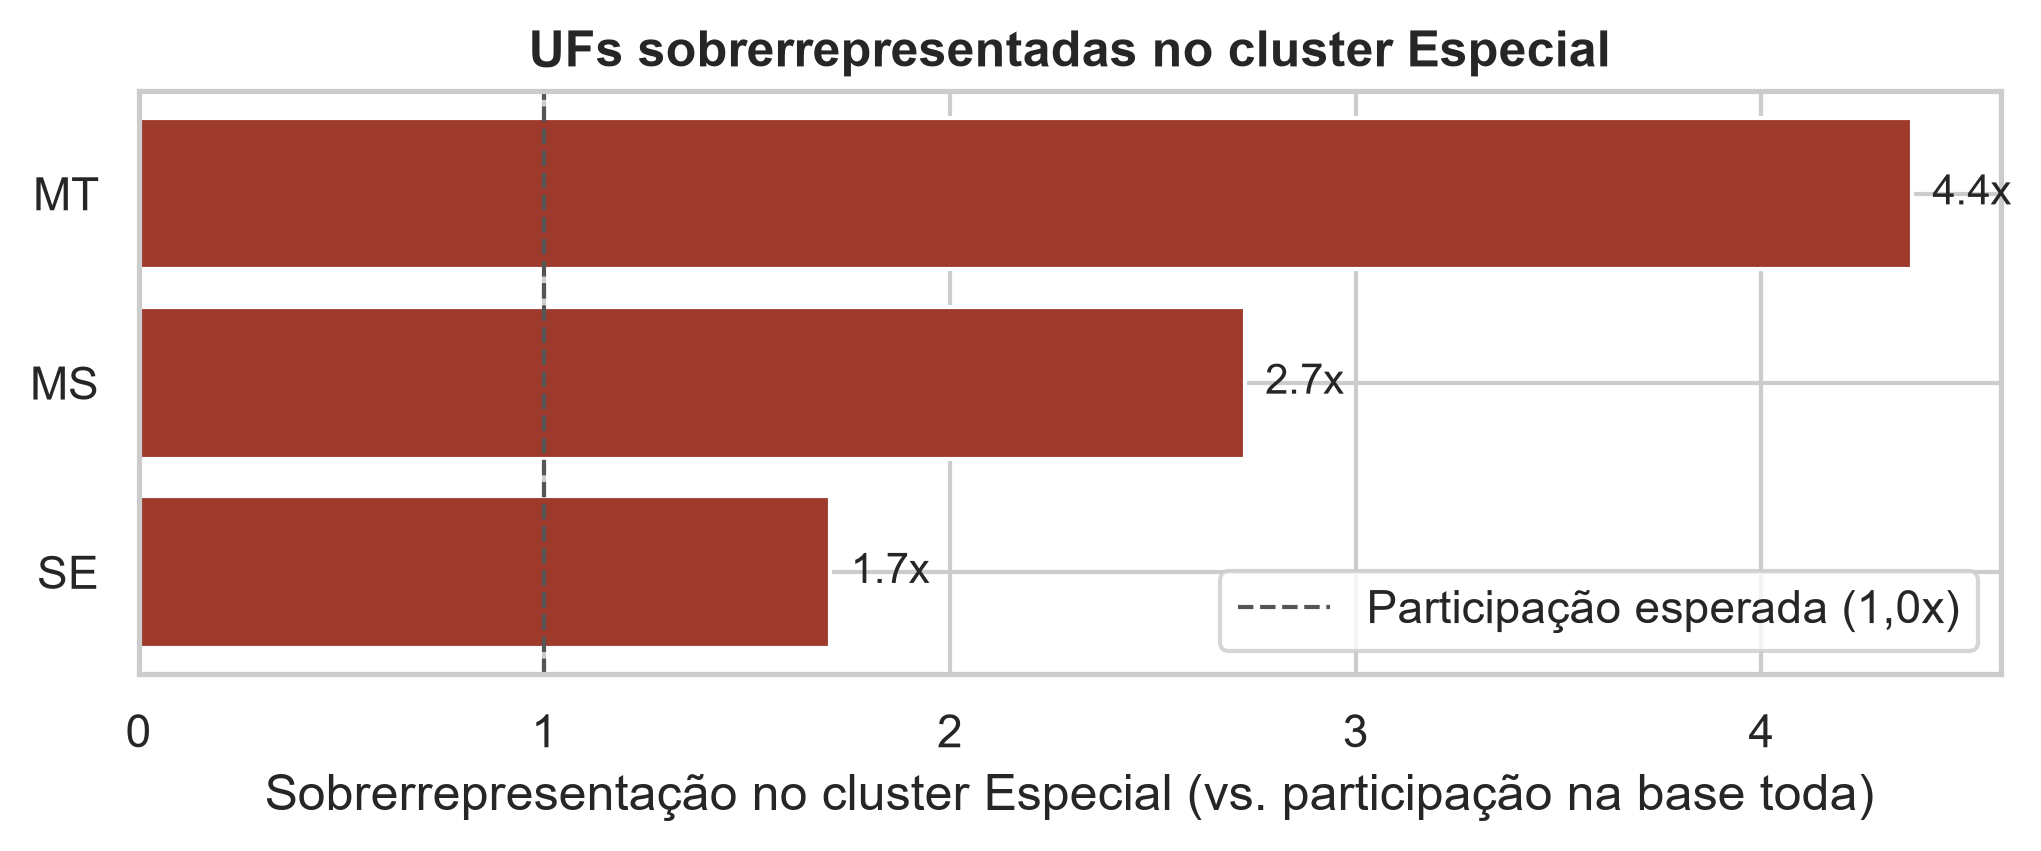

In [34]:
Image(filename=HIBRIDA / 'uf_sobrerrepresentacao_especial.png', width=600)


## Frete: testado como feature, mantido como enriquecimento

Motivado pelo achado de UF acima, testamos `frete_por_m3` (frete ÷ volume, limpa de outliers p01–p99) como feature adicional do K-Means (mesma população, mesmo k, ver `2.Kmeans.ipynb`, seção 13):


In [35]:
print(f"Atual (5 features)          | silhueta=0.3186 | DB=1.1048 | ARI vs atual=1.000")
print(f"+ frete_por_m3 (6 features)  | silhueta=0.2462 | DB=1.3742 | ARI vs atual=0.694")


Atual (5 features)          | silhueta=0.3186 | DB=1.1048 | ARI vs atual=1.000
+ frete_por_m3 (6 features)  | silhueta=0.2462 | DB=1.3742 | ARI vs atual=0.694


**Decisão: descartada como feature.** Piora silhueta e Davies-Bouldin ao mesmo tempo, mesmo com realocação real de clientes (ARI=0,694) — mesmo padrão de `intensidade_desconto` (seção 5): reembaralha sem separar melhor os grupos. Mantida como enriquecimento, que é onde ela já mostrou valor explicativo (achado de UF acima):


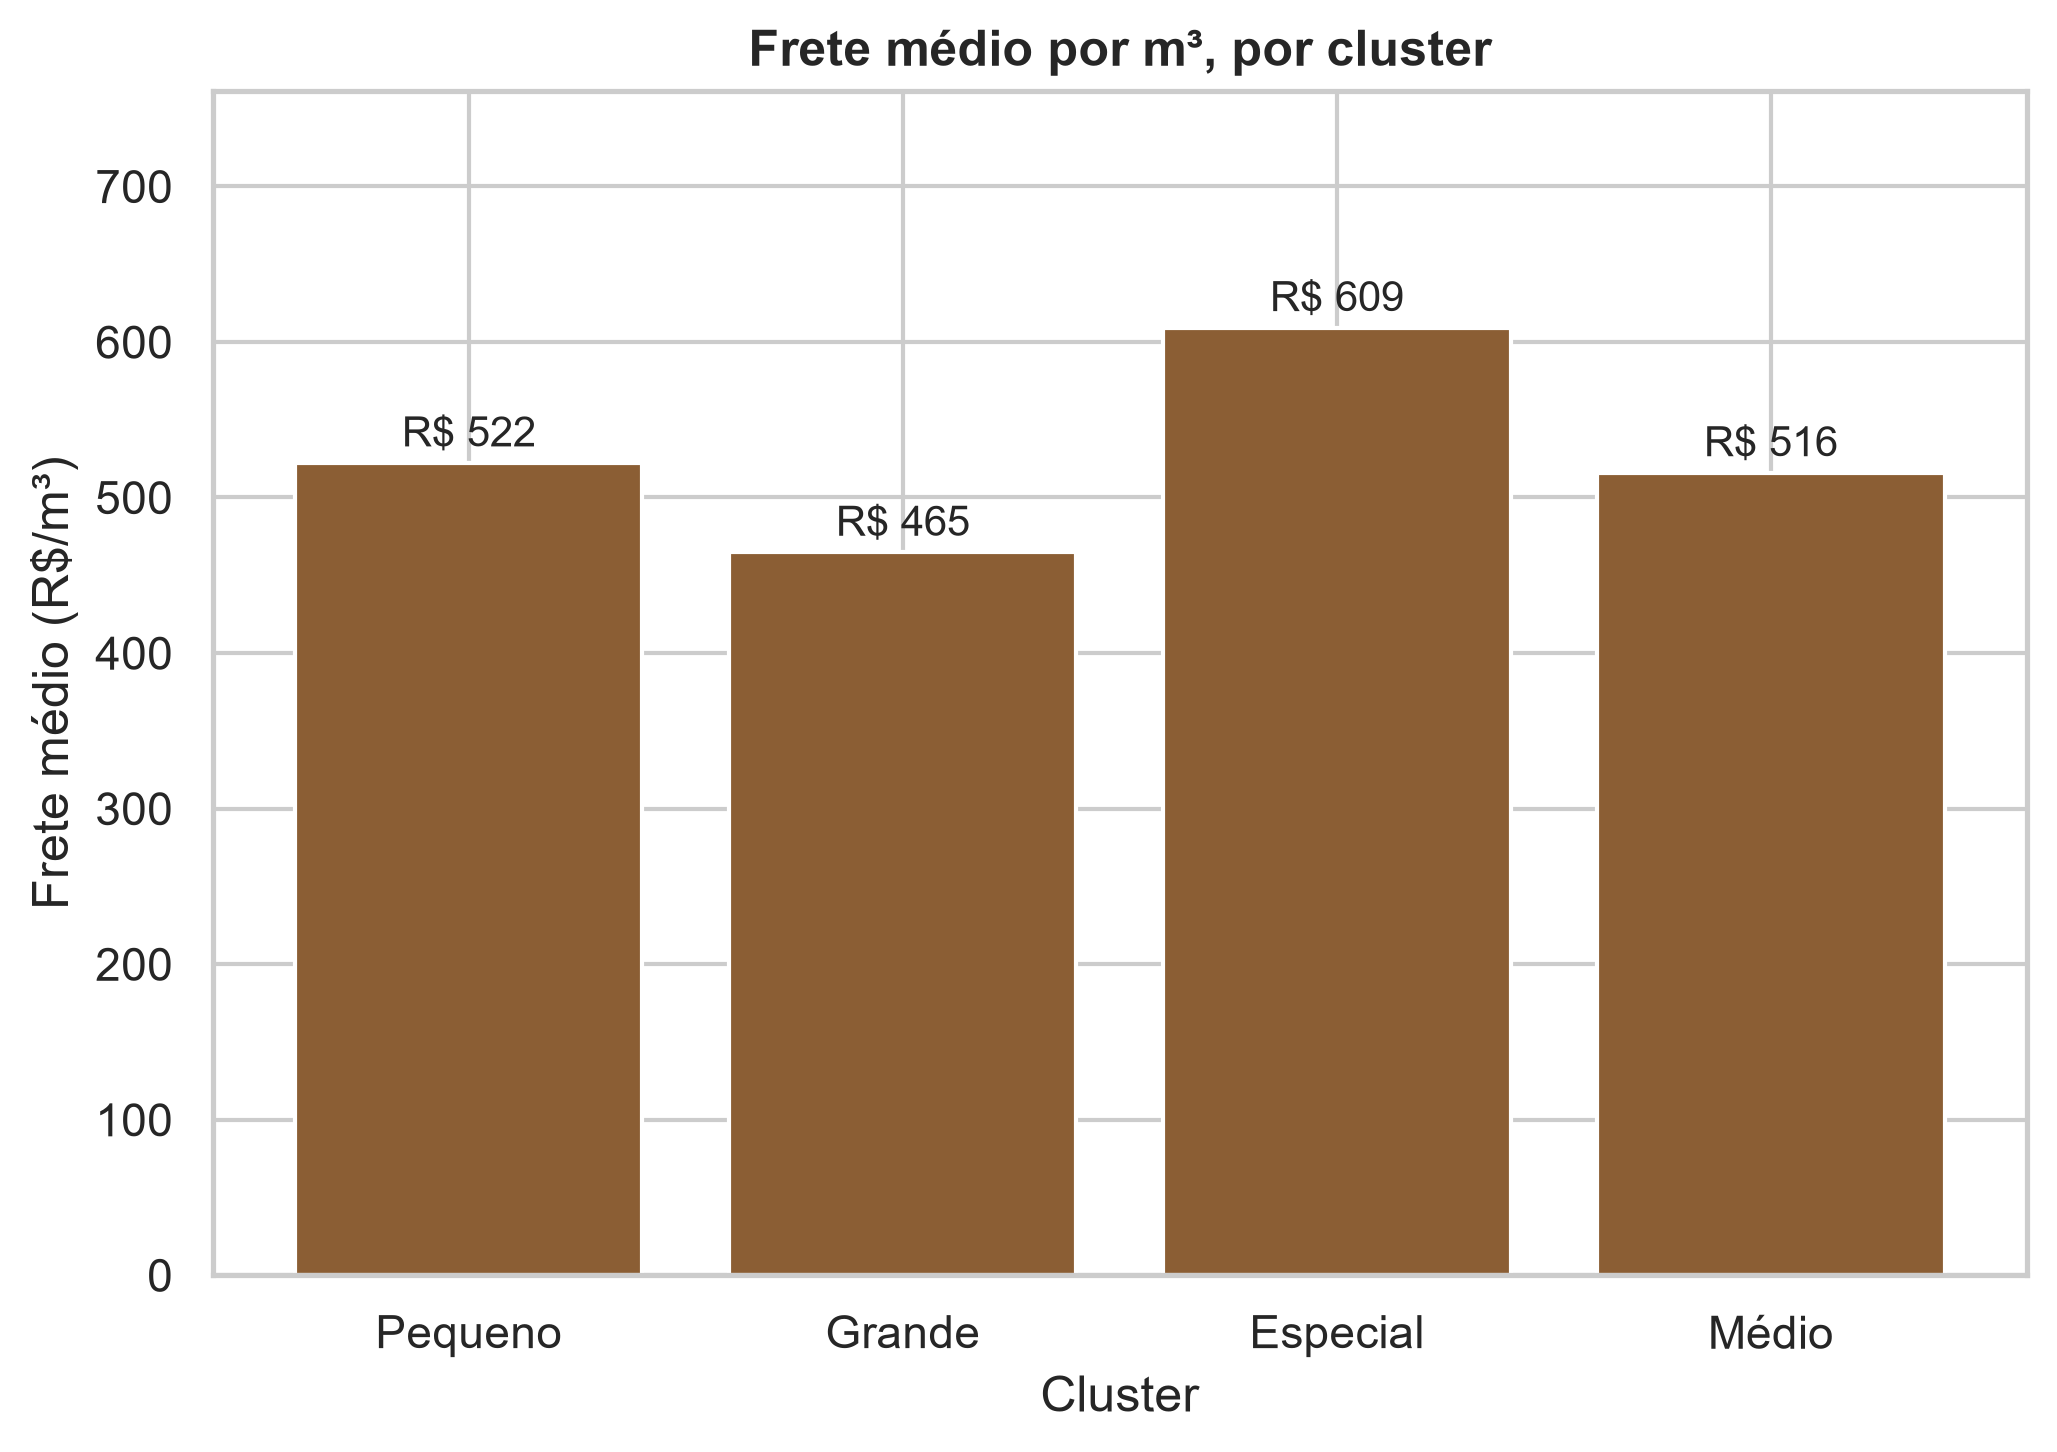

In [36]:
Image(filename=HIBRIDA / 'frete_por_cluster.png', width=550)


Olhando frete Mato Grosso/MS vs. resto **dentro de cada cluster**, o padrão fica ainda mais nítido: no Especial, clientes de MT/MS pagam **R$ 919/m³** de frete contra R$ 552/m³ do resto do cluster (+66%) — a maior diferença entre os 4 clusters (no Médio, a diferença é de só 3%). Não é só "o Especial tem mais gente de MT/MS" — dentro do próprio Especial, MT/MS paga desproporcionalmente mais frete.


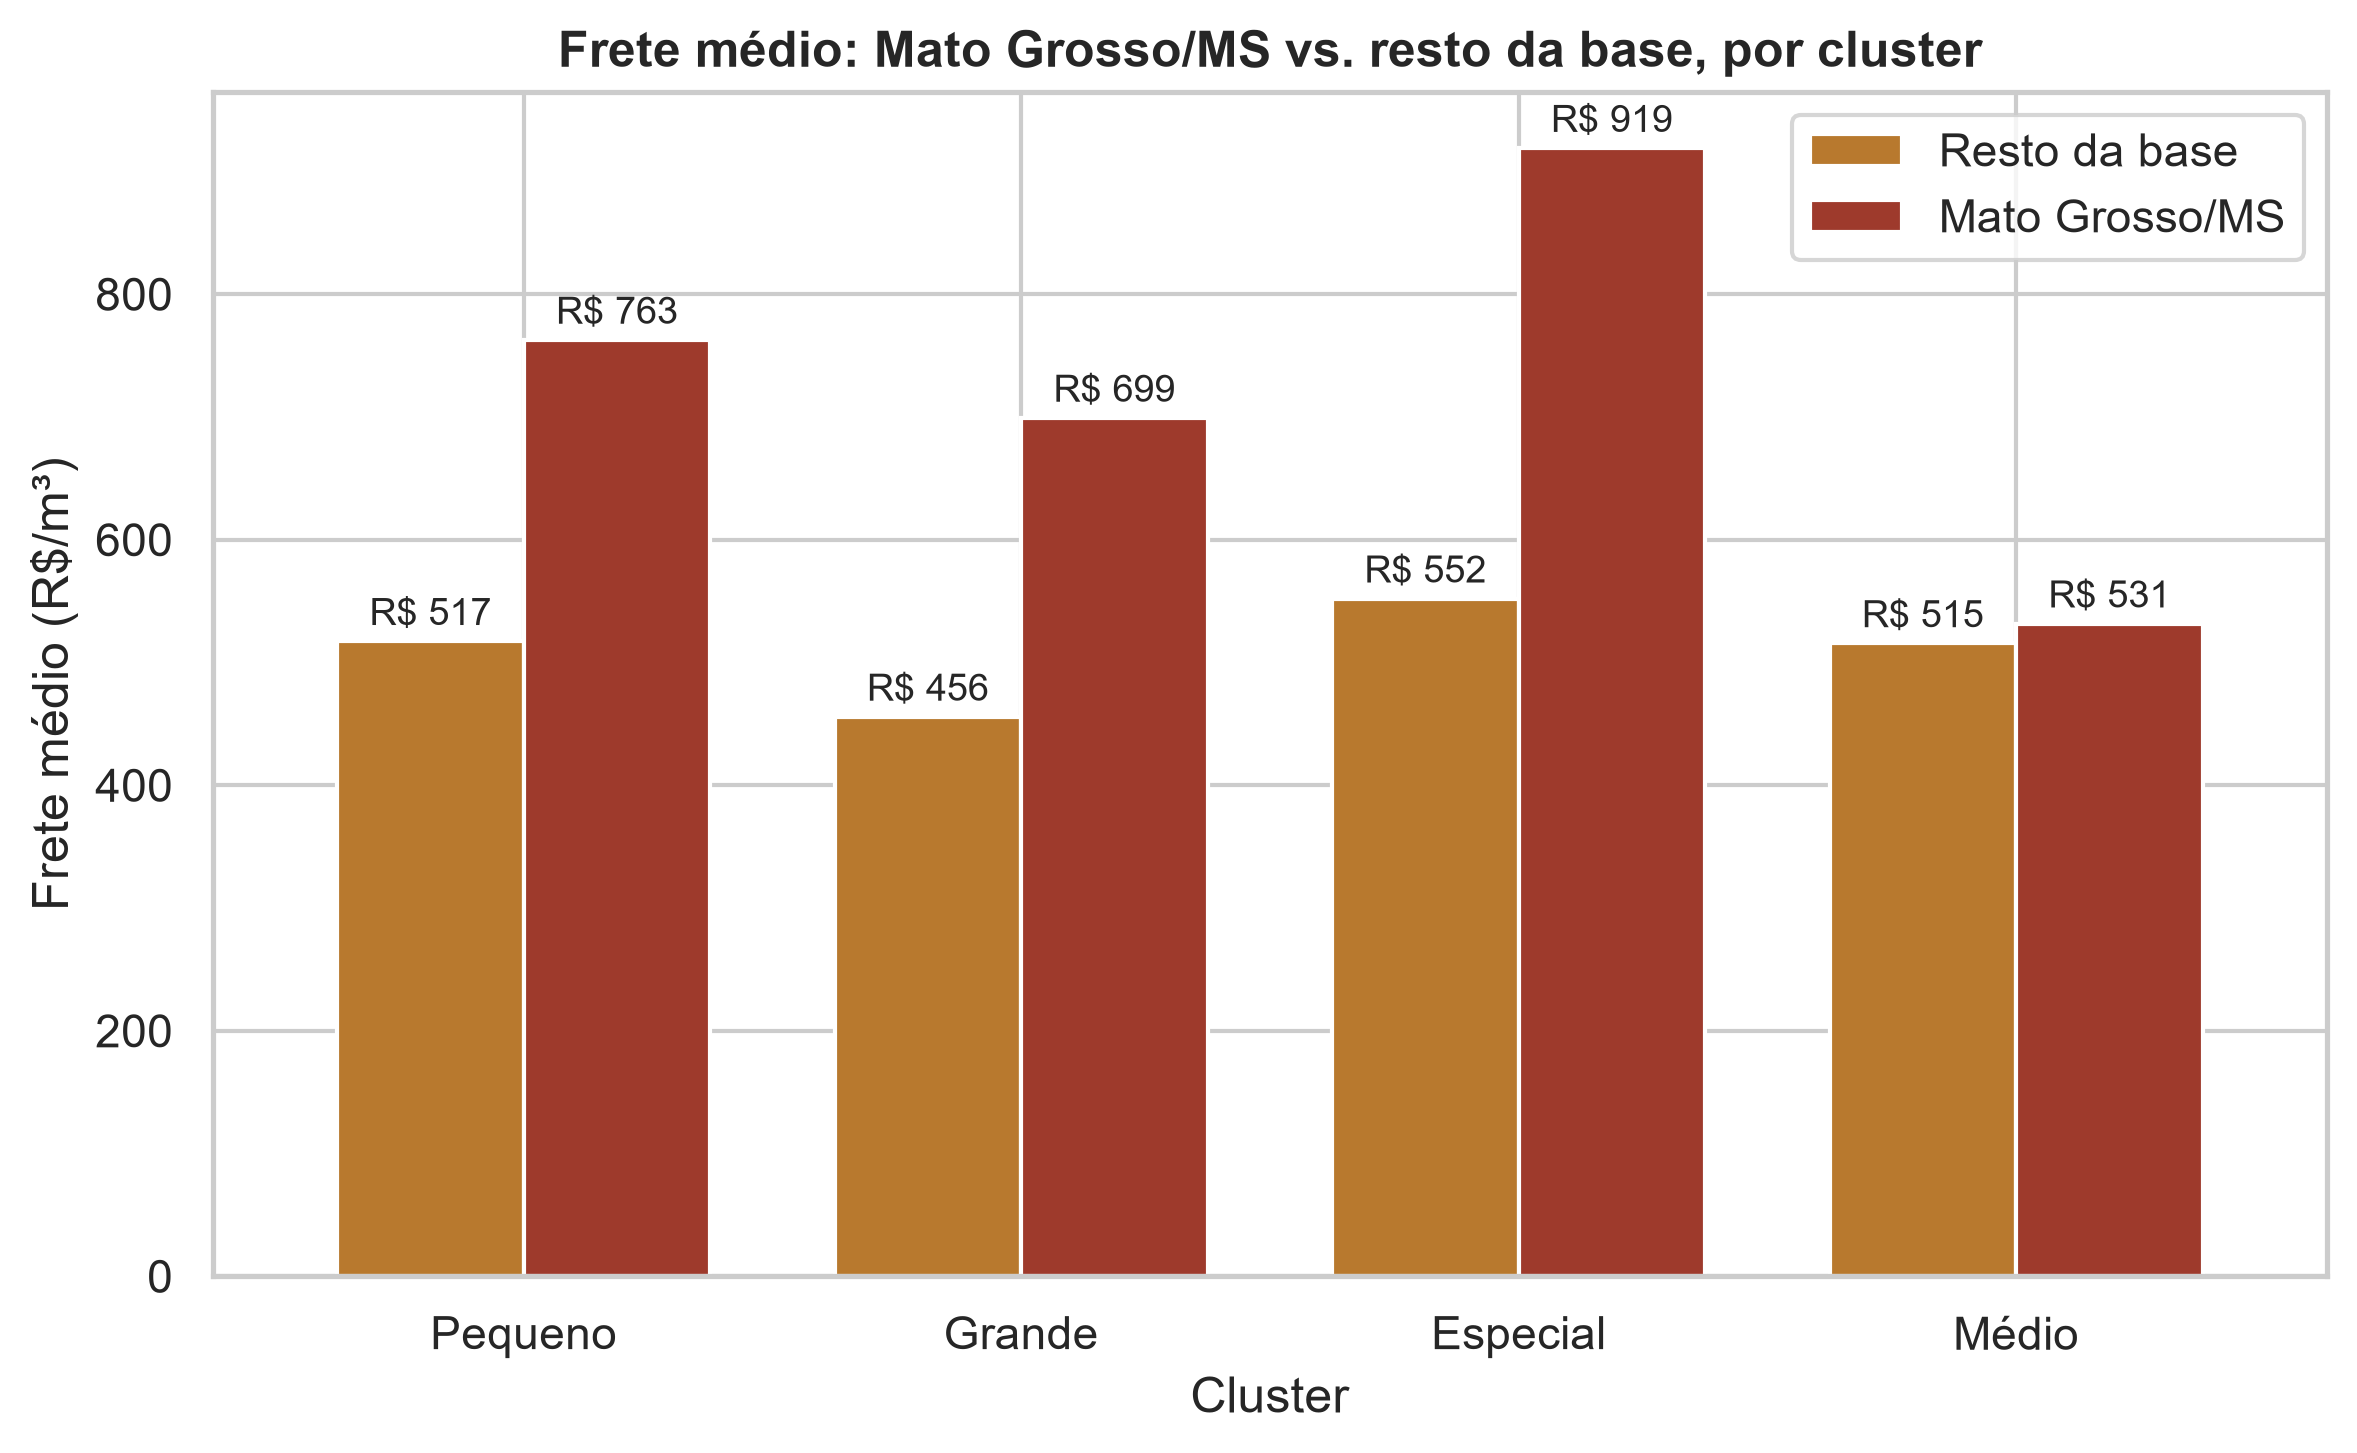

In [37]:
Image(filename=HIBRIDA / 'frete_mtms_vs_resto_por_cluster.png', width=650)


## Frequência de compra corrigida: revisitada e ainda descartada como feature

A seção 4 citava `frequencia_mensal` como removida por problema de qualidade de dado (pedidos faturados em várias remessas inflando a contagem de transações). Esse problema foi corrigido depois — `frequencia_mensal_corrigida` conta pedidos únicos (`DOC_VENDA`) via `pedidos.csv`, é o que usamos como enriquecimento na seção 6 (`nível de frequência` acima). Mas essa versão corrigida nunca tinha sido retestada como feature do K-Means até agora. Mesmo critério de sempre: mesma população, mesmo k, com/sem.


In [38]:
print(f"Atual (5 features)                        | silhueta=0.3186 | DB=1.1048 | ARI vs atual=1.000")
print(f"+ frequencia_mensal_corrigida (6 features)  | silhueta=0.3436 | DB=1.0787 | ARI vs atual=0.554")


Atual (5 features)                        | silhueta=0.3186 | DB=1.1048 | ARI vs atual=1.000
+ frequencia_mensal_corrigida (6 features)  | silhueta=0.3436 | DB=1.0787 | ARI vs atual=0.554


**Decisão: descartada como feature, apesar de melhorar as métricas.** Diferente de todas as outras candidatas testadas neste documento, essa melhora silhueta (0,3436 vs. 0,3186) e Davies-Bouldin (1,0787 vs. 1,1048) ao mesmo tempo, com realocação real de clientes (ARI=0,554). Olhando onde os clientes vão parar, porém: **93,8% do cluster Especial** — o achado central desta segmentação — e **95,7% do cluster Pequeno** são absorvidos pelo mesmo cluster maior, cujo preço médio (R$ 13.391/m³) fica perto do Pequeno, não do Especial. O sinal de preço que define o Especial se dilui. Métricas agregadas um pouco melhores, mas o segmento de negócio mais acionável do projeto deixa de existir como grupo isolado — optamos por manter o modelo de 5 features. `frequencia_mensal_corrigida` segue disponível como **enriquecimento** (`nível de frequência`, seção 6), não como feature de treino.


### Onde focar primeiro

A receita não se distribui igualmente entre os 36 segmentos viáveis — poucos concentram a maior parte.


16 de 40 segmentos cobrem 80% da receita total


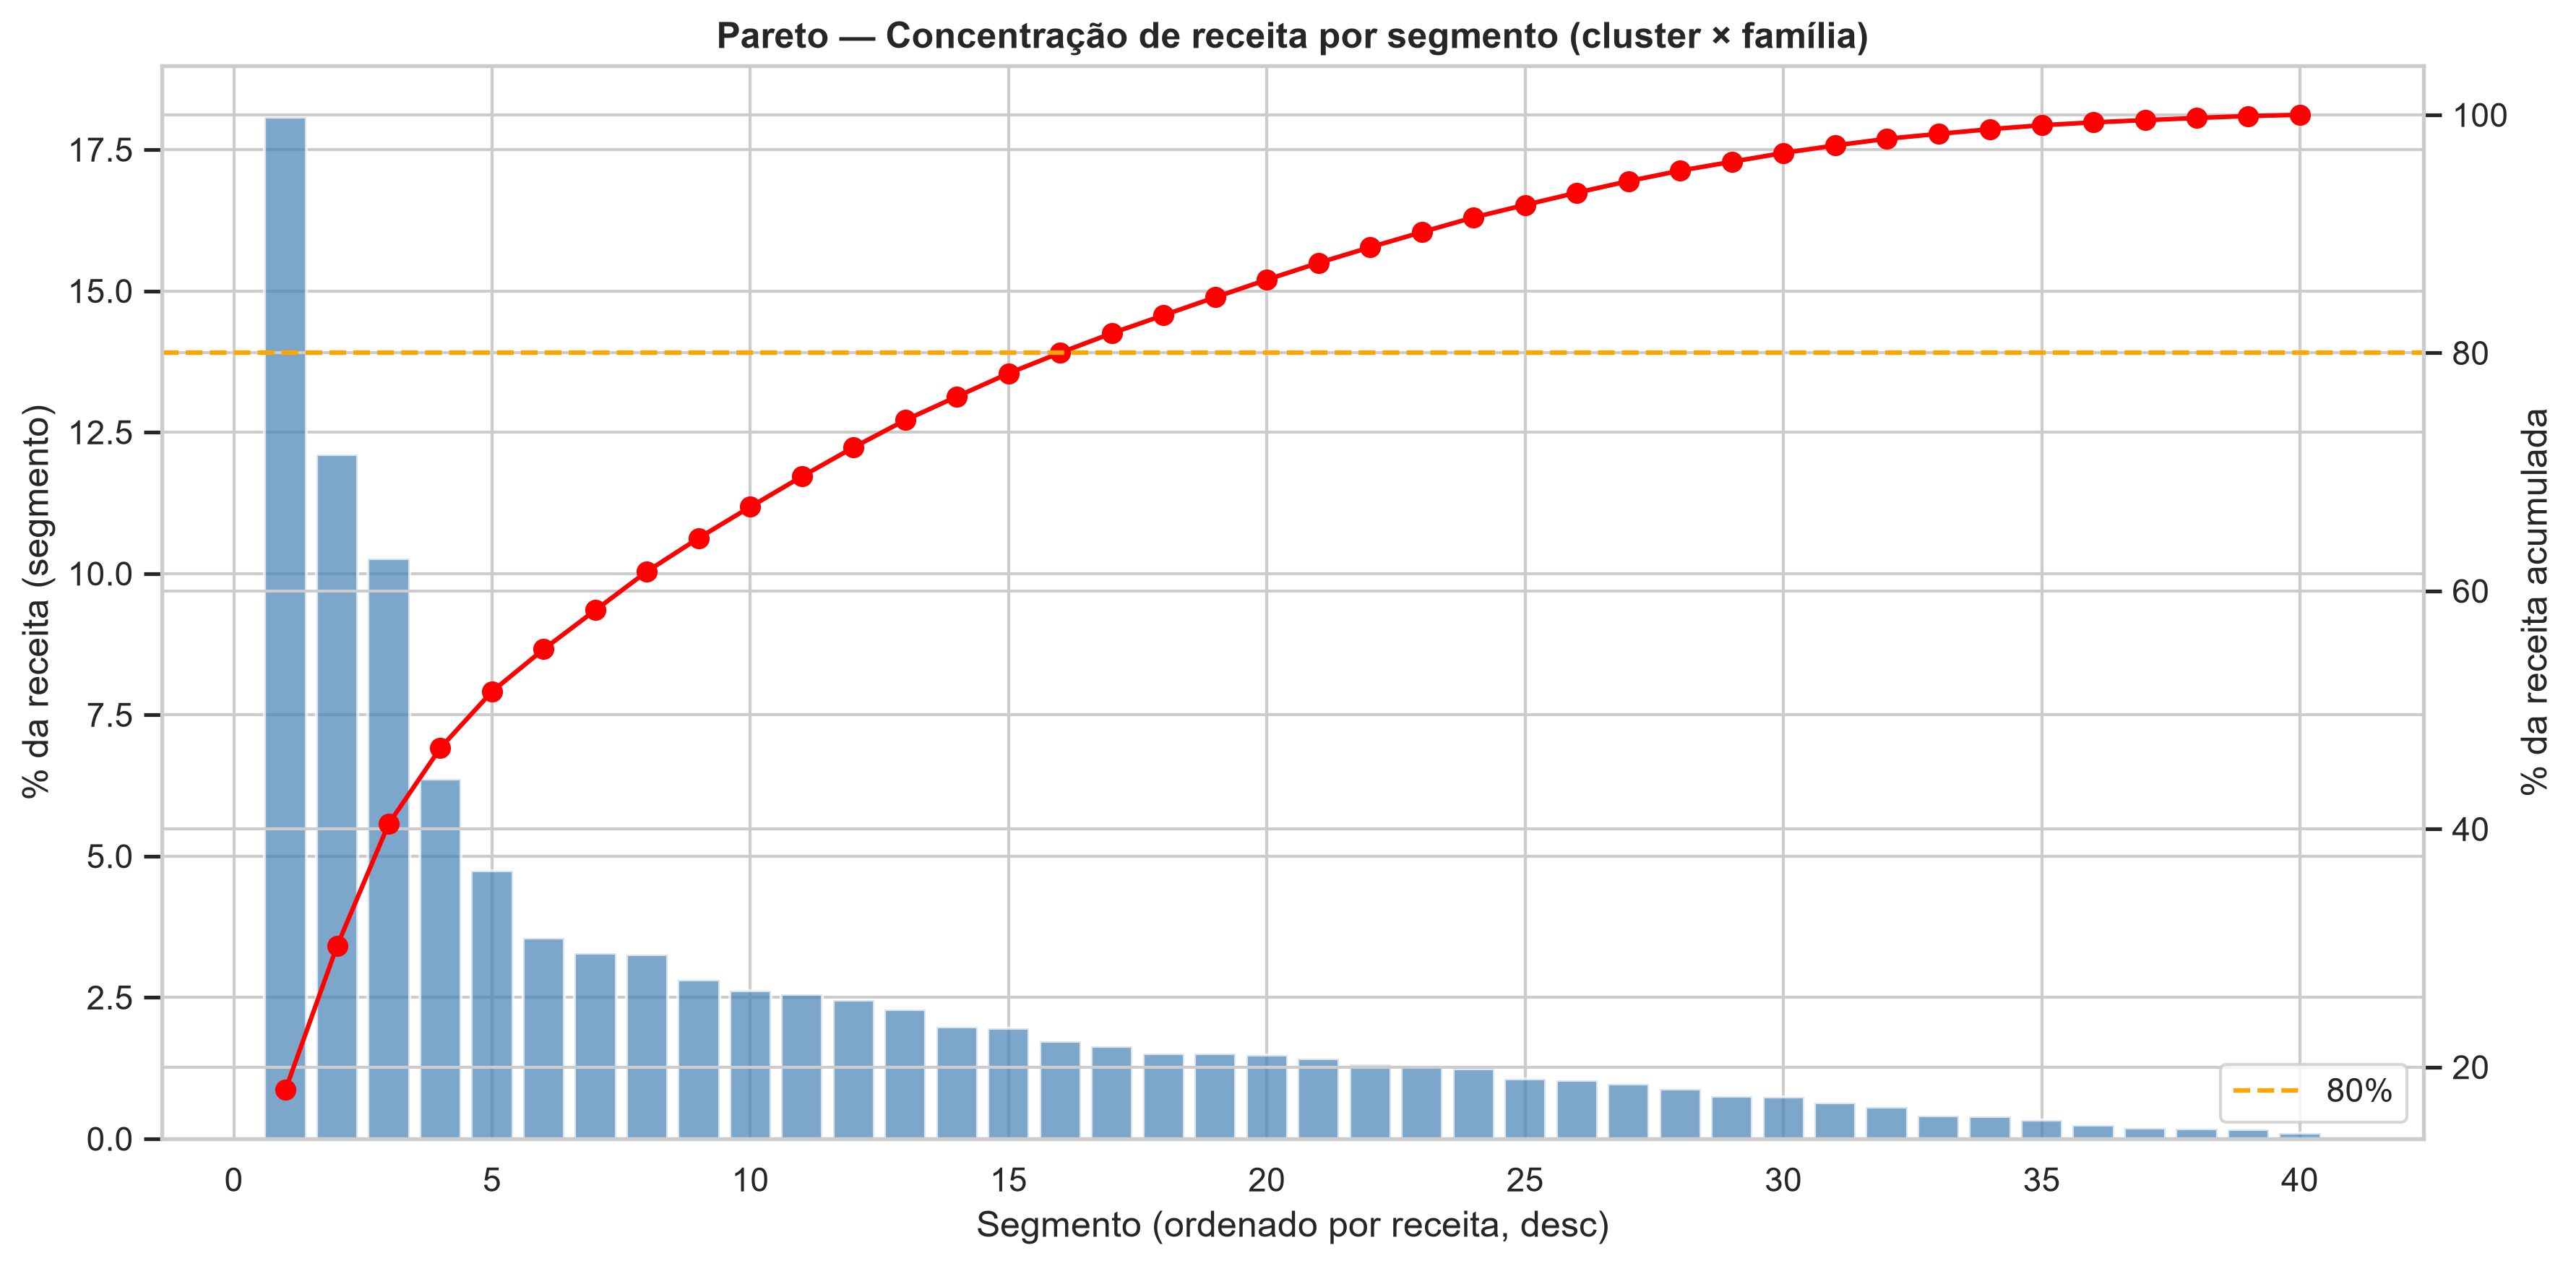

In [39]:
pareto = pd.read_csv(HIBRIDA / 'segmentos_pareto.csv')
n80 = int((pareto['receita_pct_acumulado'] < 80).sum() + 1)
print(f"{n80} de {len(pareto)} segmentos cobrem 80% da receita total")
Image(filename=HIBRIDA / 'pareto_segmentos.png', width=950)


## 7. Limitações e cuidados

- **Nomes de cluster são sugestões**, baseadas nos perfis numéricos reais, mas não validadas com o
  time comercial — tratar como hipótese de trabalho, não como taxonomia final.
- **Silhueta de 0,32 é "aceitável", não "excelente"** — os 4 clusters têm alguma sobreposição real
  (visível na projeção PCA da seção 5); é o trade-off esperado ao priorizar o achado do grupo Especial
  sobre separação estatística máxima (k=3 teria silhueta maior).
- **O grupo Especial precisa de investigação qualitativa** — os dados mostram *que* paga mais e tem
  menos margem, não mostram *por quê*.
- **Clusters podem mudar com o tempo** — recomenda-se reprocessar a segmentação periodicamente
  (sugestão: trimestral).
- **A família AV está fora desta análise** por decisão do cliente — reincorporá-la exigiria retreinar
  o modelo do zero.

## 8. Próximos passos

1. Validar os 4 clusters e os nomes sugeridos com o time comercial.
2. Investigar a causa raiz do grupo Especial antes de qualquer ajuste de preço.
3. Implementar a tabela cluster × família como referência operacional de pricing.
4. Reprocessar a segmentação trimestralmente e monitorar estabilidade dos clusters.
5. ~~Avaliar o cruzamento externo CNPJ → CNAE~~ — **feito** (seção 6): 96,8% de cobertura,
   substituiu `segmento_b2b` como enriquecimento (`outputs/4.CNAE/build_cnae_lookup.py`).
6. Cruzar o CNAE dos clientes AGRO com o calendário de safra de cada cultura, para testar uma
   feature de sazonalidade específica desse recorte (seção 6).

## Anexo — arquivos gerados nesta análise

`outputs/` está organizado por etapa da análise: `1. EDA/`, `2. Clusterização/` (este projeto) e,
futuramente, `3.Elasticidade/`.

| Arquivo | Conteúdo |
|---|---|
| `notebooks/1.EDA_Kmeans.ipynb` | Exploração, classificação de movimentos, reconciliação financeira, dataset agregado por cliente, exclusão de AV, variáveis da Fase 2 |
| `notebooks/2.Kmeans.ipynb` | Definição de features, testes de ablação, varredura de k, modelo final (k=4, 5 features) |
| `notebooks/4.Segmentacao-Hibrida.ipynb` | Cruzamento cluster × família × frequência |
| `notebooks/7.Relatorio-Tecnico.ipynb` | Este relatório |
| `outputs/1. EDA/` | Dataset agregado por cliente e artefatos de reconciliação |
| `outputs/2. Clusterização/segmentacao_clientes_kmeans.csv` | Segmentação final (cliente → cluster) |
| `outputs/2. Clusterização/2.segmentacao_hibrida/` | Matriz cluster×família, Pareto, figuras do cruzamento |
| `outputs/2. Clusterização/3.relatorios/` | Este relatório em HTML e o relatório comercial |
| `outputs/2. Clusterização/5.Figures/` | Figuras de diagnóstico do modelo final (correlação, k, silhueta, PCA, boxplot) |
| `outputs/4.CNAE/cnae_por_cnpj.csv` | Cruzamento CNPJ → CNAE (Receita Federal), usado no enriquecimento dos clusters |
